In [20]:
import pandas as pd

# Read into market Dataset 
market = pd.read_csv('market.csv')
market.head()

,Date,spf_adj_close,jpm_adj_close,jpm_volume,bac_adj_close,bac_volume,msft_adj_close,msft_volume,jnj_adj_close,jnj_volume,...,wfc_30d_ma,wfc_rsi,citi_10d_ma,citi_20d_ma,citi_30d_ma,citi_rsi,jpm_hist_vol_10,jpm_hist_vol_30,jpm_hist_vol_50,jpm_hist_vol_100
0,8/18/2023,563.68,148.97,8517460,29.11,31430361,320.40,20698864,172.39,85594288,...,41.771333,64.648438,41.444,41.5285,41.495000,72.554348,15.741,16.794,17.201,21.070
1,8/17/2023,564.39,148.63,9953912,29.28,37202231,321.86,16966285,172.94,88924923,...,41.825000,72.270742,41.561,41.5160,41.539333,73.066667,16.191,16.849,17.200,21.071
2,8/16/2023,567.22,150.19,6978235,29.29,47220396,324.04,18836139,173.44,64036947,...,41.868667,64.150943,41.688,41.4910,41.587333,69.300912,15.964,16.583,17.091,21.421
3,8/15/2023,568.42,150.83,10300303,29.94,43406068,321.01,24355491,173.85,45905612,...,41.931000,64.066194,41.837,41.5330,41.679000,74.025974,16.948,16.856,17.037,21.579
4,8/14/2023,578.82,154.77,5044282,30.93,32563693,322.93,20113725,172.17,48213840,...,42.034000,70.370370,42.115,41.6540,41.808333,77.827051,11.697,15.349,16.012,21.117


In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Calculate returns for all assets
assets = ['jpm', 'bac', 'citi', 'ry', 'ms', 'spx', 'spf']
for asset in assets:
    market[f'{asset}_return'] = (market[f'{asset}_adj_close'] - market[f'{asset}_adj_close'].shift(1)) / market[f'{asset}_adj_close'].shift(1)

# Calculate deviation from moving average
for asset in assets[:5]:  # Exclude SPX and SPF as they don't have moving averages in this code
    market[f'{asset}_20d_ma_dev'] = (market[f'{asset}_adj_close'] - market[f'{asset}_20d_ma']) / market[f'{asset}_20d_ma']

# Calculate moving average returns
for asset in assets[:5]:
    market[f'{asset}_20d_ma_return'] = (market[f'{asset}_20d_ma'] - market[f'{asset}_20d_ma'].shift(1)) / market[f'{asset}_20d_ma'].shift(1)

# Define relevant column groups
returns = [f'{asset}_return' for asset in assets]
ma_dev = [f'{asset}_20d_ma_dev' for asset in assets[:5]]
ma_returns = [f'{asset}_20d_ma_return' for asset in assets[:5]]
economic_indicators = ['CPI', 'FEDL01', 'UE', 'GDP']
technical_indicators = [f'{asset}_20d_ma' for asset in assets[:5]] + ['jpm_rsi', 'bac_rsi', 'ry_rsi', 'ms_rsi', 'citi_rsi']

# Combine all relevant columns
all_columns = [f'{asset}_adj_close' for asset in assets] + returns + economic_indicators + technical_indicators + ma_dev + ma_returns

# Ensure the 'Date' column is in datetime format and sort the DataFrame
market['Date'] = pd.to_datetime(market['Date'])
market.sort_values('Date', inplace=True)

# Select only relevant columns
market = market[['Date'] + all_columns]

# Drop rows with missing values before standardization
market_clean = market.dropna()

# Standardize all relevant columns
scaler = StandardScaler()
scaled_data = scaler.fit_transform(market_clean[all_columns])

# Create a standardized DataFrame
scaled_market = pd.DataFrame(scaled_data, columns=all_columns, index=market_clean.index)
scaled_market['Date'] = market_clean['Date']

# Log transform and standardize all columns
log_scaled_market = scaled_market.copy()  # Create a copy to preserve the original dataset
for col in all_columns:
    # Handle non-positive values before log transformation
    if (log_scaled_market[col] <= 0).any():
        log_scaled_market[col] = np.log1p(log_scaled_market[col] - log_scaled_market[col].min() + 1)
    else:
        log_scaled_market[col] = np.log1p(log_scaled_market[col])

# Standardize again after log transformation
log_scaled_market[all_columns] = scaler.fit_transform(log_scaled_market[all_columns])

# Optional: Remove outliers
for col in all_columns:
    lower_bound = log_scaled_market[col].quantile(0.01)
    upper_bound = log_scaled_market[col].quantile(0.99)
    log_scaled_market = log_scaled_market[(log_scaled_market[col] >= lower_bound) & (log_scaled_market[col] <= upper_bound)]

# View standardized and log-transformed data
print(log_scaled_market.describe())

       jpm_adj_close  bac_adj_close  citi_adj_close  ry_adj_close  \
count    3626.000000    3626.000000     3626.000000   3626.000000   
mean       -0.003658       0.069564        0.082251      0.039131   
min        -1.498680      -1.791504       -0.956414     -1.483404   
25%        -0.530249      -0.826652       -0.778662     -0.640818   
50%        -0.227279       0.230988       -0.598528      0.147135   
75%         0.321456       0.853788        1.410512      0.786236   
max         2.060788       1.757140        1.782345      1.804908   
std         0.801509       0.922264        1.019985      0.885242   

       ms_adj_close  spx_adj_close  spf_adj_close   jpm_return   bac_return  \
count   3626.000000    3626.000000    3626.000000  3626.000000  3626.000000   
mean      -0.066949      -0.023187       0.082440     0.015351     0.008564   
min       -1.672062      -1.414603      -1.876456    -2.957330    -1.983783   
25%       -0.492541      -0.530342      -0.298340    -0.303353

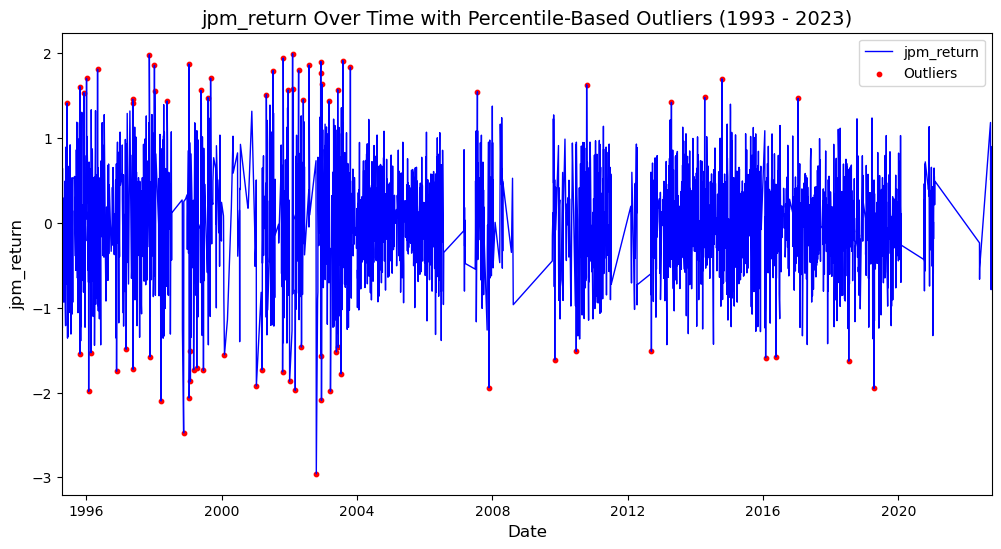

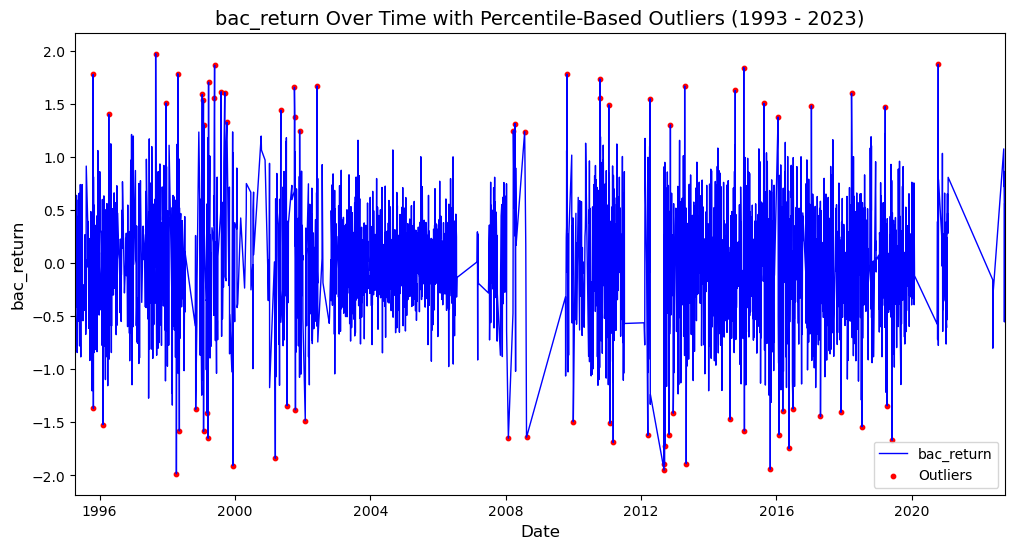

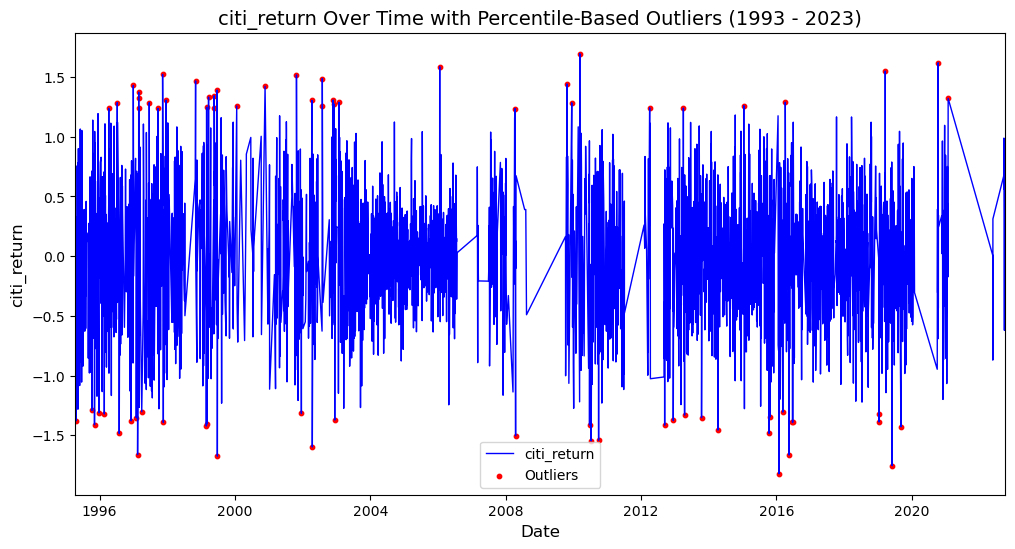

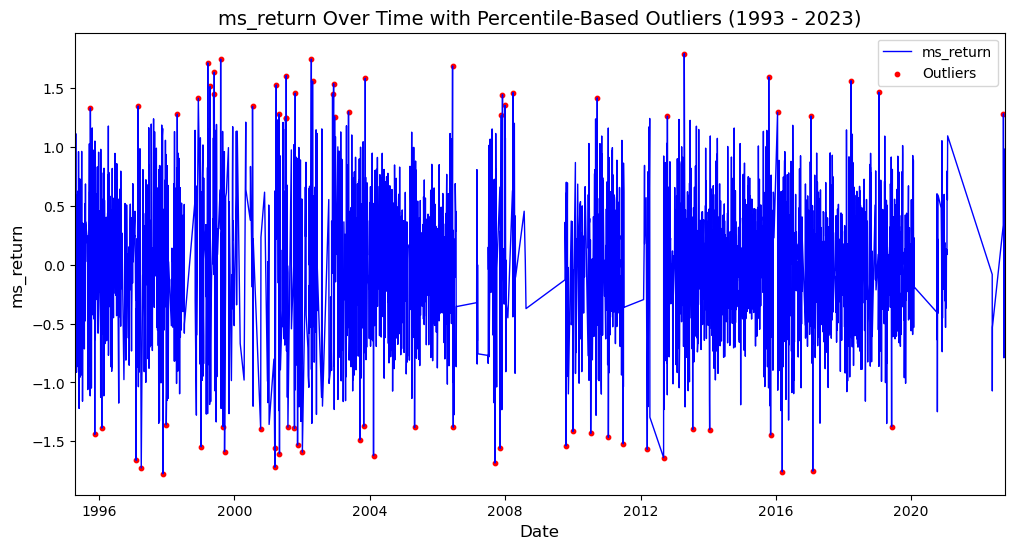

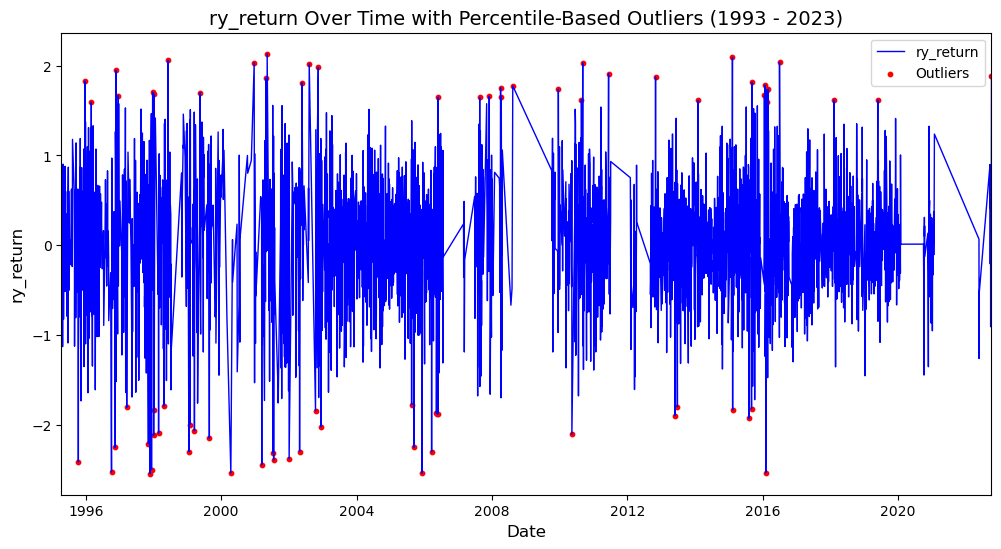

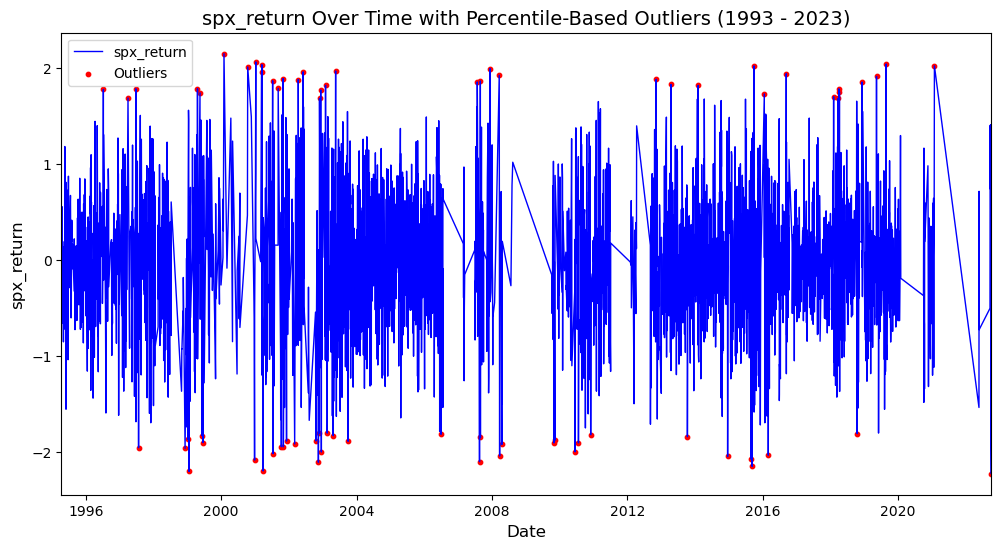

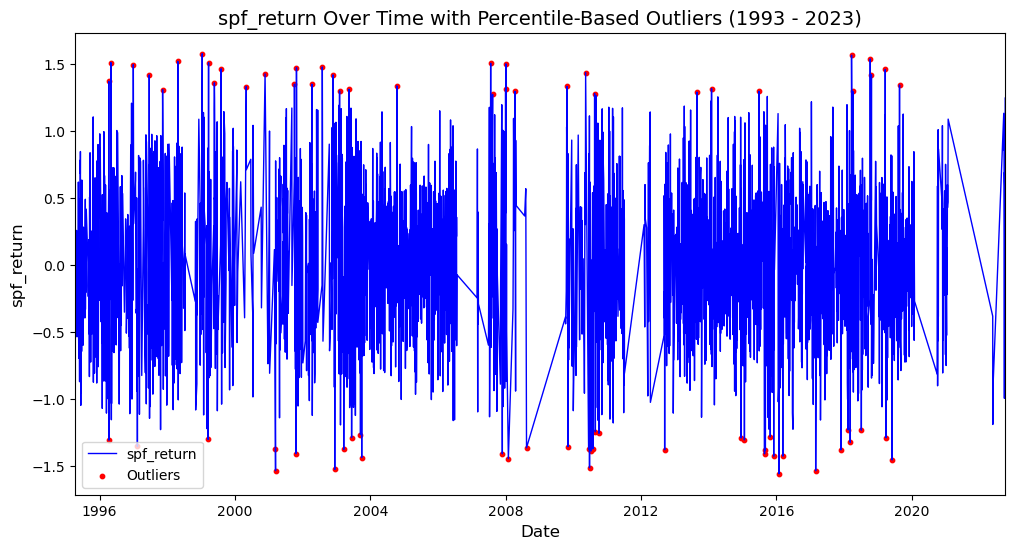

In [22]:
import matplotlib.pyplot as plt

columns_to_plot = ['jpm_return', 'bac_return', 'citi_return', 'ms_return', 'ry_return', 'spx_return', 'spf_return']

# Percentile-Based Outlier Detection
percentile_thresholds = (0.01, 0.99)  # Using 1st and 99th percentiles for detection
outlier_flags_percentile = {}

for col in columns_to_plot:
    lower_bound = log_scaled_market[col].quantile(percentile_thresholds[0])
    upper_bound = log_scaled_market[col].quantile(percentile_thresholds[1])
    # Ensure boolean mask is stored as a Series
    outlier_flags_percentile[col] = (log_scaled_market[col] < lower_bound) | (log_scaled_market[col] > upper_bound)

# Plotting with percentile-based outlier detection
for col in columns_to_plot:
    plt.figure(figsize=(12, 6))
    plt.plot(log_scaled_market['Date'], log_scaled_market[col], label=col, color='blue', lw=1)
    # Convert outlier flags to a Series to ensure correct indexing
    outlier_mask = outlier_flags_percentile[col].astype(bool)
    plt.scatter(log_scaled_market['Date'][outlier_mask], log_scaled_market[col][outlier_mask], color='red', label='Outliers', s=10)
    plt.title(f"{col} Over Time with Percentile-Based Outliers (1993 - 2023)", fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel(col, fontsize=12)
    plt.xlim([log_scaled_market['Date'].min(), log_scaled_market['Date'].max()])
    plt.legend()
    plt.grid(False)
    plt.show()

In [23]:
# Create lagged features for macroeconomic variables
lags = [1, 3, 6]  # Lag periods (1, 3, and 6 months)
for col in economic_indicators:  # Loop over macroeconomic variables
    for lag in lags:
        log_scaled_market[f"{col}_lag{lag}"] = log_scaled_market[col].shift(lag)

# Drop rows with NaN values caused by lagging
log_scaled_market = log_scaled_market.dropna()

# View the first few rows with the new lagged columns
print(log_scaled_market.head())

      jpm_adj_close  bac_adj_close  citi_adj_close  ry_adj_close  \
7126      -1.469107      -1.199323       -0.691032     -1.472157   
7125      -1.471073      -1.195780       -0.686368     -1.466547   
7124      -1.475002      -1.195780       -0.680159     -1.465158   
7123      -1.473035      -1.220616       -0.681710     -1.467938   
7122      -1.476971      -1.227739       -0.683262     -1.472157   

      ms_adj_close  spx_adj_close  spf_adj_close  jpm_return  bac_return  \
7126     -1.654192      -1.408634      -1.869123    0.168987   -0.054518   
7125     -1.658156      -1.401292      -1.864780    0.288891    0.033261   
7124     -1.660136      -1.402609      -1.858212   -0.073244    0.638455   
7123     -1.672062      -1.401675      -1.863912    0.289892    0.210387   
7122     -1.660136      -1.400192      -1.867757   -0.073613   -0.145814   

      citi_return  ...  CPI_lag6  FEDL01_lag1  FEDL01_lag3  FEDL01_lag6  \
7126    -0.290794  ...  0.327925     1.455497     1.509319 

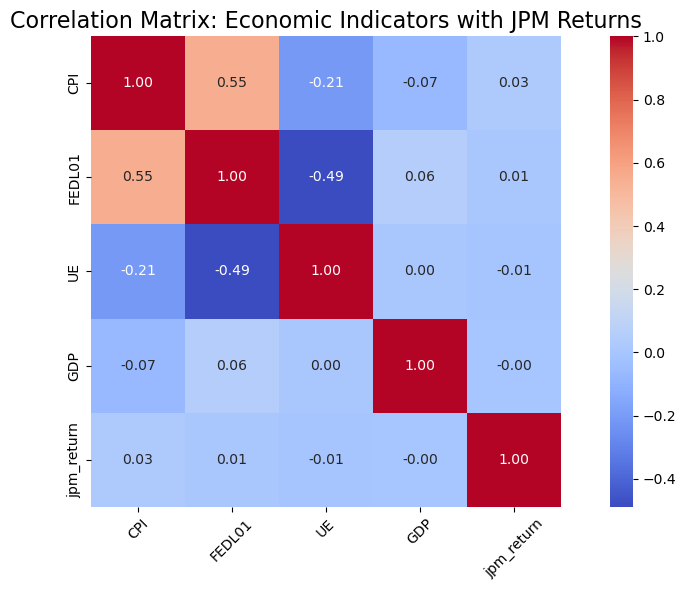

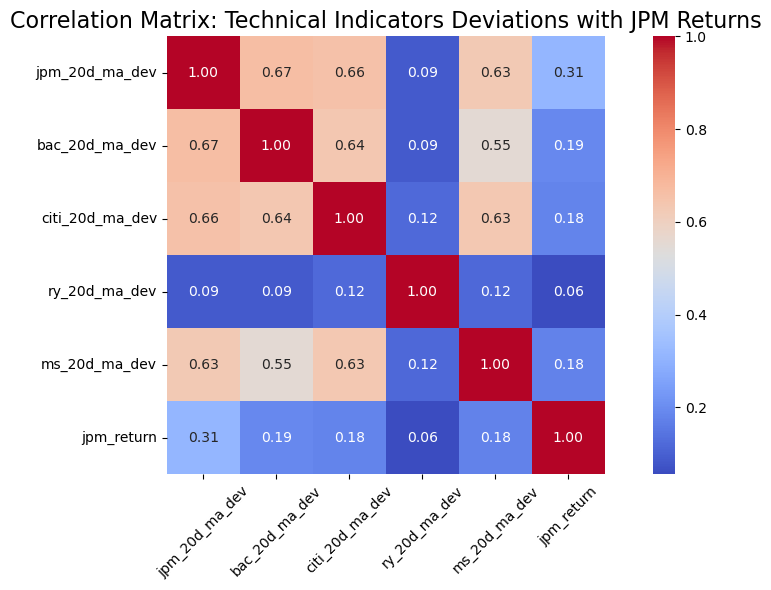

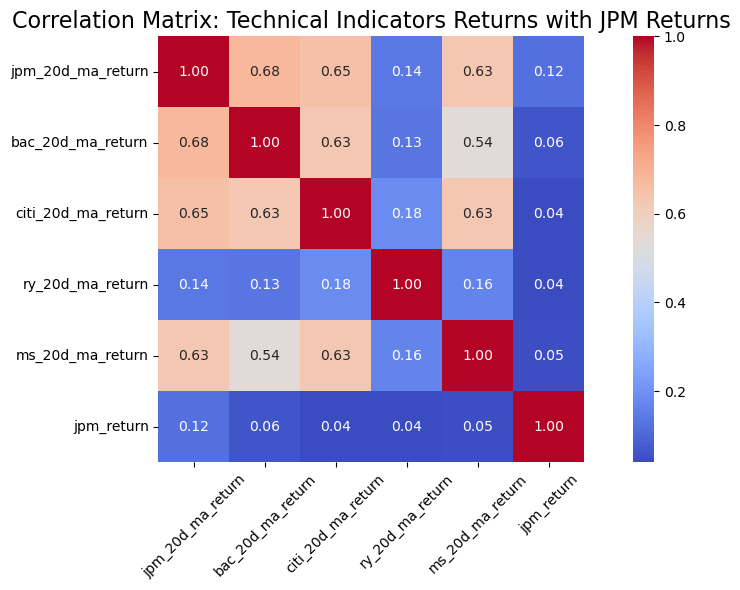

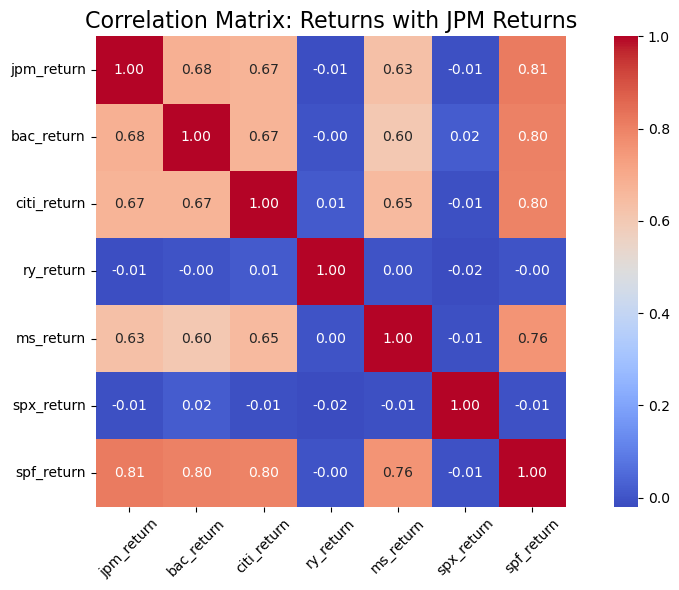

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'jpm_return' is included in the DataFrame
if 'jpm_return' not in log_scaled_market.columns:
    print("Error: 'jpm_return' not found in the dataset!")
else:
    # Economic Indicators Correlation
    economic_corr = log_scaled_market[economic_indicators + ['jpm_return']].corr()
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        economic_corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True
    )
    plt.title("Correlation Matrix: Economic Indicators with JPM Returns", fontsize=16)
    plt.xticks(rotation=45, fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()

    # Technical Indicators Deviations Correlation
    ma_dev_corr = log_scaled_market[ma_dev + ['jpm_return']].corr()
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        ma_dev_corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True
    )
    plt.title("Correlation Matrix: Technical Indicators Deviations with JPM Returns", fontsize=16)
    plt.xticks(rotation=45, fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()

    # Technical Indicators MA Returns Correlation
    ma_returns_corr = log_scaled_market[ma_returns + ['jpm_return']].corr()
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        ma_returns_corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True
    )
    plt.title("Correlation Matrix: Technical Indicators Returns with JPM Returns", fontsize=16)
    plt.xticks(rotation=45, fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()

    # Returns Correlation
    returns_corr = log_scaled_market[returns].corr()
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        returns_corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True
    )
    plt.title("Correlation Matrix: Returns with JPM Returns", fontsize=16)
    plt.xticks(rotation=45, fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()

Top 5 Variables Most Correlated with JPM_RETURN:
spf_return        0.813820
bac_return        0.683435
citi_return       0.669536
ms_return         0.629843
jpm_20d_ma_dev    0.311053
Name: jpm_return, dtype: float64


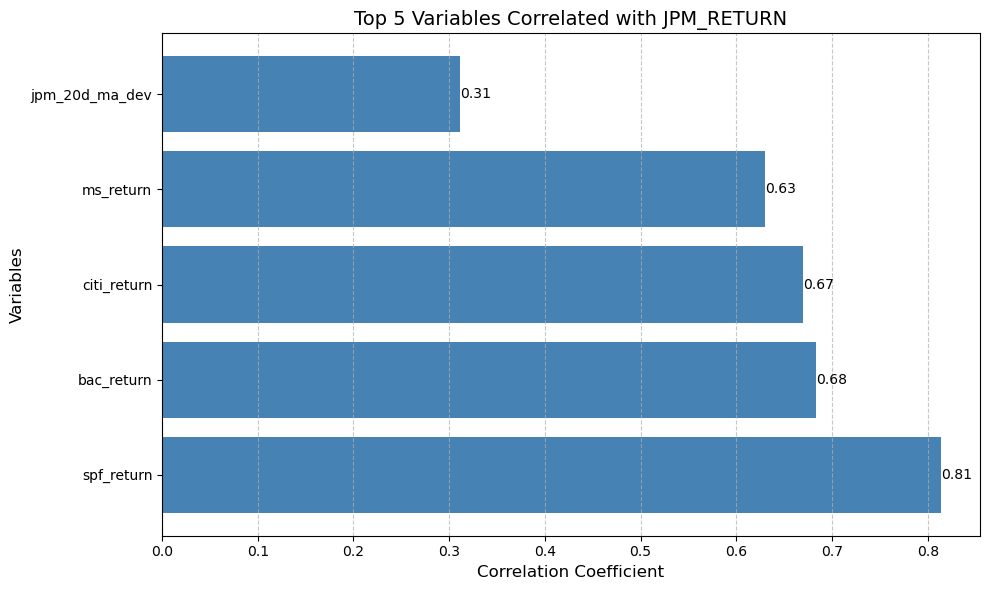

Top 5 Variables Most Correlated with BAC_RETURN:
spf_return        0.801491
jpm_return        0.683435
citi_return       0.671029
ms_return         0.601952
bac_20d_ma_dev    0.299281
Name: bac_return, dtype: float64


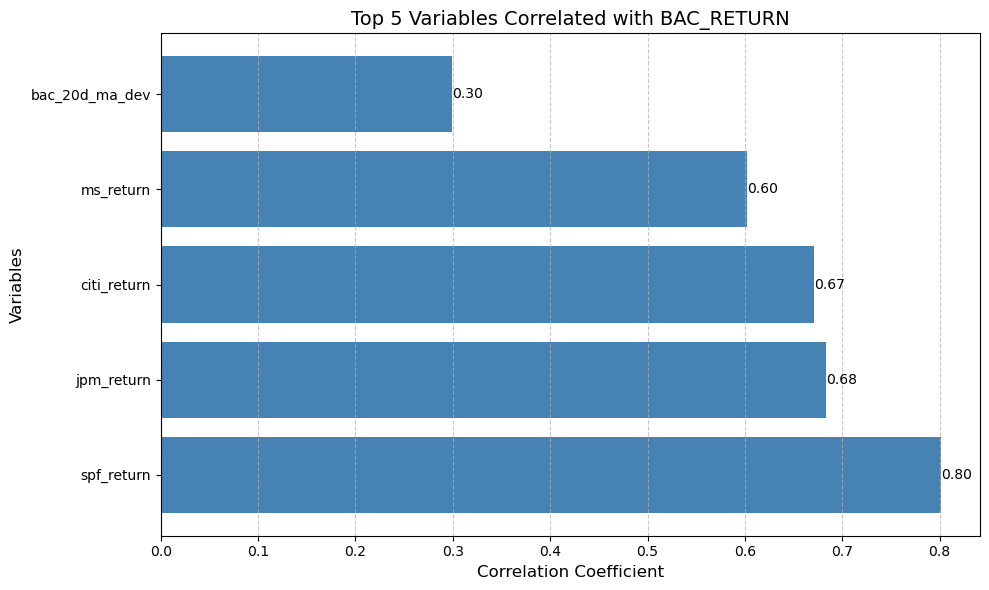

Top 5 Variables Most Correlated with CITI_RETURN:
spf_return         0.798851
bac_return         0.671029
jpm_return         0.669536
ms_return          0.650094
citi_20d_ma_dev    0.288231
Name: citi_return, dtype: float64


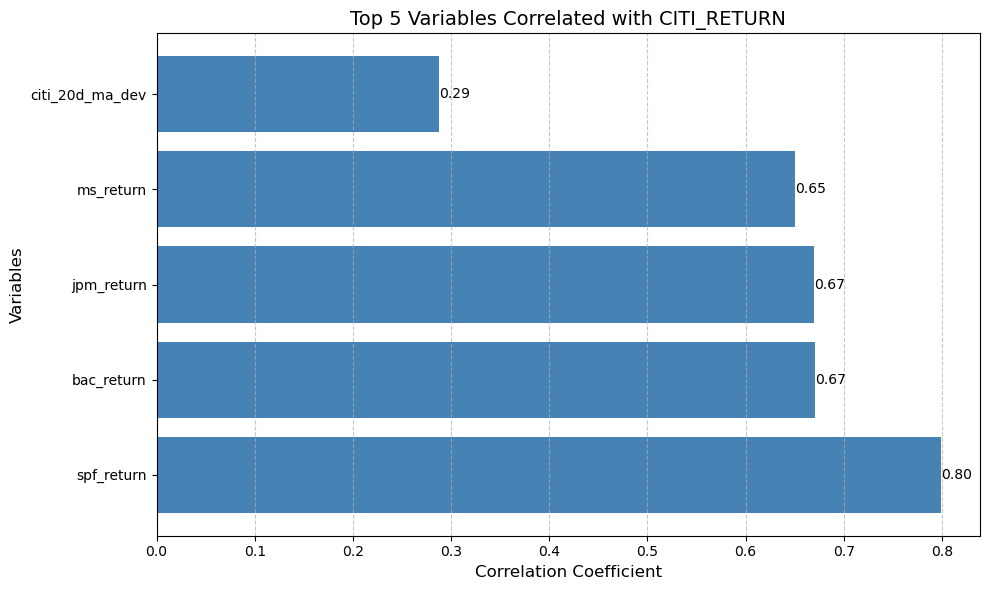

Top 5 Variables Most Correlated with RY_RETURN:
ry_20d_ma_dev       0.320503
ry_rsi              0.190284
ry_20d_ma_return    0.146154
ry_adj_close        0.014943
citi_return         0.013786
Name: ry_return, dtype: float64


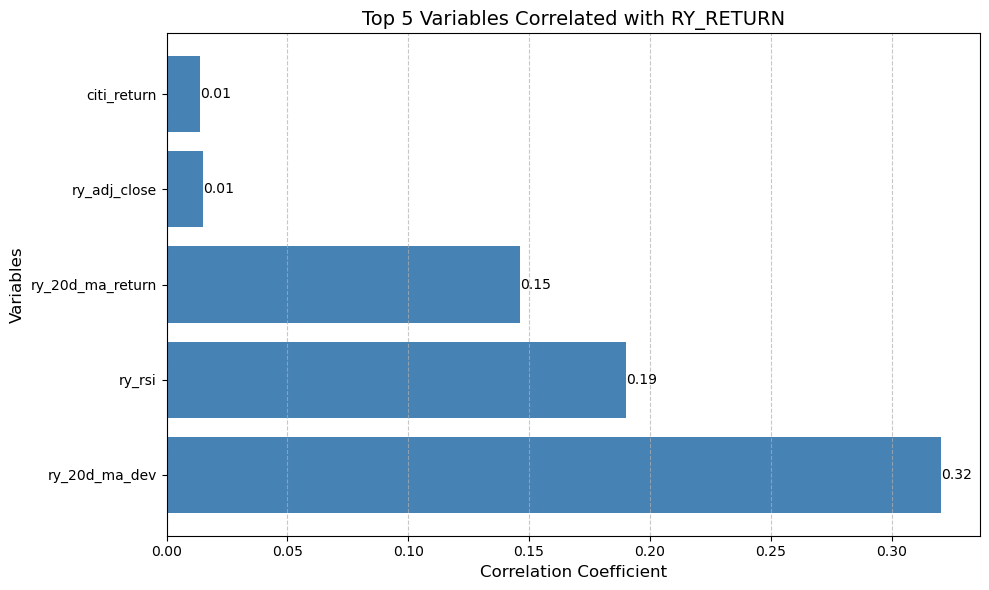

Top 5 Variables Most Correlated with MS_RETURN:
spf_return       0.757952
citi_return      0.650094
jpm_return       0.629843
bac_return       0.601952
ms_20d_ma_dev    0.310266
Name: ms_return, dtype: float64


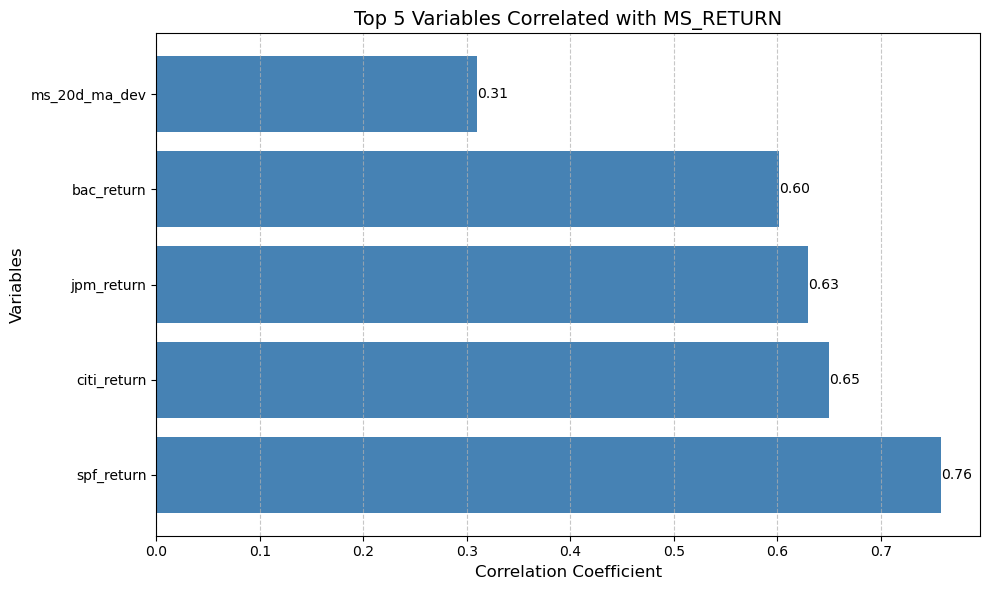

Top 5 Variables Most Correlated with SPX_RETURN:
ry_20d_ma_return    0.088780
ry_20d_ma_dev       0.083103
ry_rsi              0.079705
CPI_lag1            0.031159
CPI                 0.029635
Name: spx_return, dtype: float64


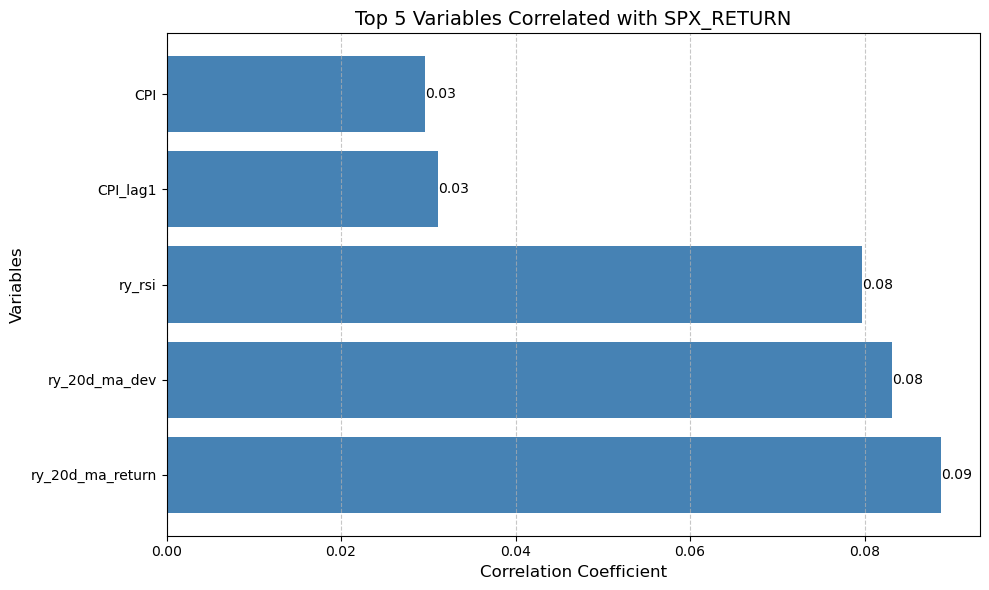

Top 5 Variables Most Correlated with SPF_RETURN:
jpm_return        0.813820
bac_return        0.801491
citi_return       0.798851
ms_return         0.757952
bac_20d_ma_dev    0.222316
Name: spf_return, dtype: float64


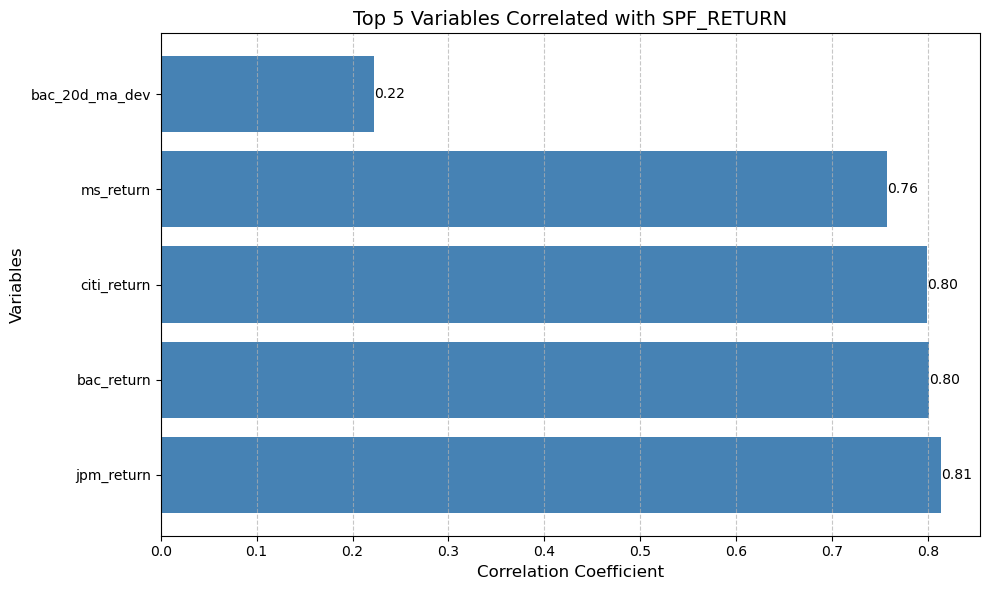

In [25]:
import matplotlib.pyplot as plt

# Compute and plot correlations for each return variable
return_variables = [f'{asset}_return' for asset in assets]

for return_var in return_variables:
    # Compute correlations of all variables with the current return variable
    correlation_with_var = log_scaled_market.corr()[return_var]
    
    # Sort correlations and drop the return variable itself
    sorted_correlation = correlation_with_var.drop(return_var).sort_values(ascending=False)
    
    # Get the top 5 variables with the highest correlation
    top_5_correlated = sorted_correlation.head(5)
    
    # Display the top 5 variables
    print(f"Top 5 Variables Most Correlated with {return_var.upper()}:")
    print(top_5_correlated)
    
    # Generate bar plot
    plt.figure(figsize=(10, 6))
    bars = plt.barh(top_5_correlated.index, top_5_correlated.values, color='steelblue')
    plt.title(f"Top 5 Variables Correlated with {return_var.upper()}", fontsize=14)
    plt.xlabel("Correlation Coefficient", fontsize=12)
    plt.ylabel("Variables", fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Add correlation values at the end of each bar
    for bar in bars:
        plt.text(
            bar.get_width(),  # X-coordinate
            bar.get_y() + bar.get_height() / 2,  # Y-coordinate
            f"{bar.get_width():.2f}",  # Text (formatted to 2 decimal places)
            va='center',  # Vertical alignment
            ha='left',  # Horizontal alignment
            fontsize=10
        )
    
    plt.tight_layout()
    plt.show()

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# List of return variables to calculate VIF for
return_variables = ['jpm_return', 'bac_return', 'citi_return', 'ms_return', 'ry_return', 'spx_return', 'spf_return']

# Base predictors (adjust as needed for your analysis)
base_predictors = [
    'CPI', # Economic Indicator(s)
    'jpm_rsi', 'ry_rsi',  # Technical indicator
    'jpm_20d_ma_dev', 'bac_20d_ma_dev', 'citi_20d_ma_dev', 'ry_20d_ma_dev', 'ms_20d_ma_dev', 'ry_20d_ma_return', 'citi_20d_ma_return', # Moving averages
    'spf_return', 'bac_return', 'ms_return', 'citi_return', 'ry_return', 'jpm_return'  # Return variables
]

# Loop through each return variable
for target_return in return_variables:
    # Define predictors excluding the current target variable
    predictors = [col for col in base_predictors if col != target_return]
    
    # Drop rows with missing values in scaled_market
    predictor_data = log_scaled_market[predictors].dropna()
    
    # Calculate VIF
    vif_data = pd.DataFrame()
    vif_data['Feature'] = predictors
    vif_data['VIF'] = [
        variance_inflation_factor(predictor_data.values, i)
        for i in range(len(predictors))
    ]
    
    # Display the VIF values for the current return variable
    print(f"\nVariance Inflation Factors (VIF) for predictors of {target_return.upper()}:")
    print(vif_data.sort_values(by='VIF', ascending=False))


Variance Inflation Factors (VIF) for predictors of JPM_RETURN:
               Feature       VIF
10          spf_return  5.520669
6        ry_20d_ma_dev  5.249722
3       jpm_20d_ma_dev  4.508158
5      citi_20d_ma_dev  4.392871
1              jpm_rsi  3.483149
2               ry_rsi  3.399617
13         citi_return  3.229746
11          bac_return  3.141425
8     ry_20d_ma_return  2.944912
12           ms_return  2.655352
9   citi_20d_ma_return  2.514966
4       bac_20d_ma_dev  2.384519
7        ms_20d_ma_dev  2.200303
14           ry_return  1.176031
0                  CPI  1.010719



Variance Inflation Factors (VIF) for predictors of BAC_RETURN:
               Feature       VIF
10          spf_return  5.621190
6        ry_20d_ma_dev  5.239546
3       jpm_20d_ma_dev  5.009650
5      citi_20d_ma_dev  4.360789
1              jpm_rsi  3.518482
14          jpm_return  3.399501
2               ry_rsi  3.397215
12         citi_return  3.195540
8     ry_20d_ma_return  2.944706
11           ms_return  2.662892
9   citi_20d_ma_return  2.513896
7        ms_20d_ma_dev  2.219155
4       bac_20d_ma_dev  2.168456
13           ry_return  1.175576
0                  CPI  1.010751

Variance Inflation Factors (VIF) for predictors of CITI_RETURN:
               Feature       VIF
10          spf_return  5.894056
6        ry_20d_ma_dev  5.245958
3       jpm_20d_ma_dev  5.005957
5      citi_20d_ma_dev  3.908938
1              jpm_rsi  3.519495
14          jpm_return  3.430420
2               ry_rsi  3.397249
11          bac_return  3.136424
8     ry_20d_ma_return  2.944042
12           

## Model Building

#### base model: jpm_return

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, intercept, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 23 seconds.


            mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]    0.008  0.010    -0.011      0.028        0.0      0.0    7628.0   
beta[1]   -0.003  0.007    -0.017      0.012        0.0      0.0    8046.0   
beta[2]   -0.079  0.012    -0.102     -0.055        0.0      0.0    7083.0   
beta[3]    0.382  0.019     0.345      0.421        0.0      0.0    6483.0   
beta[4]   -0.217  0.015    -0.247     -0.187        0.0      0.0    9511.0   
beta[5]    0.437  0.017     0.404      0.469        0.0      0.0    7845.0   
beta[6]    0.224  0.015     0.196      0.253        0.0      0.0    8400.0   
beta[7]    0.285  0.017     0.251      0.318        0.0      0.0    7395.0   
intercept  0.014  0.006     0.001      0.025        0.0      0.0   10005.0   
sigma      0.343  0.004     0.335      0.350        0.0      0.0   10752.0   

           ess_tail  r_hat  
beta[0]      6570.0    1.0  
beta[1]      6234.0    1.0  
beta[2]      5756.0    1.0  
beta[3]      6034.0    1.

array([[<Axes: title={'center': 'beta\n0'}>,
        <Axes: title={'center': 'beta\n1'}>,
        <Axes: title={'center': 'beta\n2'}>],
       [<Axes: title={'center': 'beta\n3'}>,
        <Axes: title={'center': 'beta\n4'}>,
        <Axes: title={'center': 'beta\n5'}>],
       [<Axes: title={'center': 'beta\n6'}>,
        <Axes: title={'center': 'beta\n7'}>,
        <Axes: title={'center': 'intercept'}>]], dtype=object)

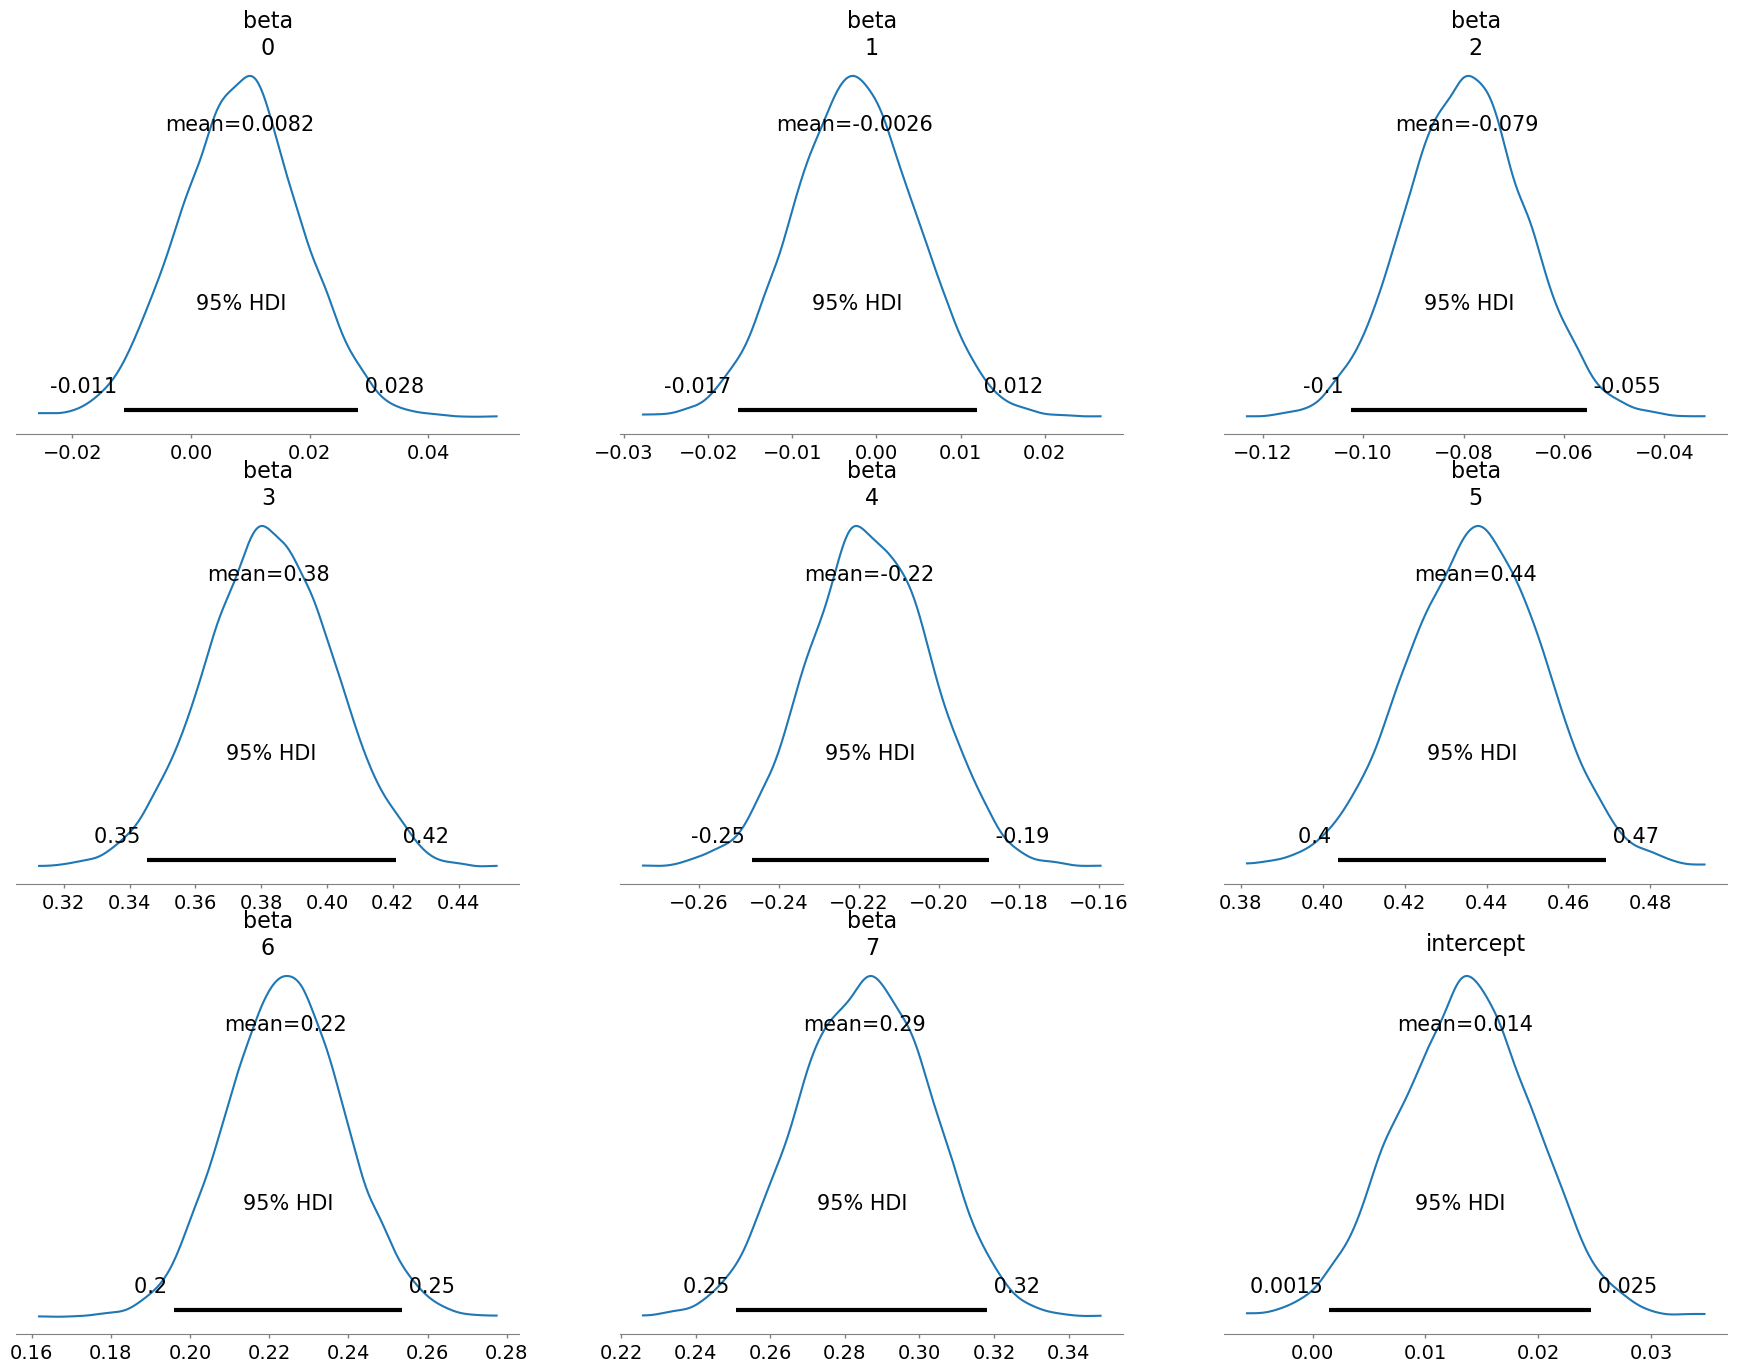

In [27]:
import pymc as pm
import arviz as az
import numpy as np

# Updated predictors list
predictors = [
    'CPI', 'FEDL01', # Economic indicators
    'jpm_rsi',  # Technical indicator
    'jpm_20d_ma_dev', 'bac_20d_ma_dev',  # Moving average deviations
    'bac_return', 'ms_return', 'citi_return'  # Top correlated returns
]

# Select predictors and target variable from scaled_market
X = log_scaled_market[predictors].dropna()  # Drop rows with NaN
y = log_scaled_market['jpm_return'].loc[X.index]  # Ensure alignment of y with X

# PyMC Bayesian Regression Model
with pm.Model() as bayesian_model:
    # Priors for regression coefficients (weakly informative normal priors)
    beta = pm.Normal("beta", mu=0, sigma=1, shape=len(predictors))  # Coefficients
    intercept = pm.Normal("intercept", mu=0, sigma=1)  # Intercept term
    sigma = pm.HalfNormal("sigma", sigma=1)  # Prior for noise standard deviation

    # Linear regression equation
    mu = intercept + pm.math.dot(X, beta)

    # Likelihood of the observations
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    # Inference using MCMC
    trace = pm.sample(2000, tune=1000, cores=4, chains=4, return_inferencedata=True)

# Posterior Analysis
# Summarize the posterior distributions
summary = az.summary(trace, hdi_prob=0.95)
print(summary)

# Plot posterior distributions of coefficients
az.plot_posterior(trace, var_names=["beta", "intercept"], hdi_prob=0.95)

#### Model with Economic Indicators Only: JPM

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas, intercept, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 23 seconds.


            mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
betas[0]  -0.004  0.019    -0.041      0.032        0.0      0.0    9490.0   
betas[1]   0.034  0.022    -0.011      0.076        0.0      0.0    7564.0   
betas[2]  -0.028  0.025    -0.077      0.021        0.0      0.0    6154.0   
betas[3]  -0.012  0.022    -0.056      0.027        0.0      0.0    7511.0   
intercept  0.000  0.019    -0.037      0.037        0.0      0.0   10958.0   
sigma      1.000  0.014     0.975      1.027        0.0      0.0    9030.0   

           ess_tail  r_hat  
betas[0]     6328.0    1.0  
betas[1]     6472.0    1.0  
betas[2]     5798.0    1.0  
betas[3]     6363.0    1.0  
intercept    6490.0    1.0  
sigma        6100.0    1.0  


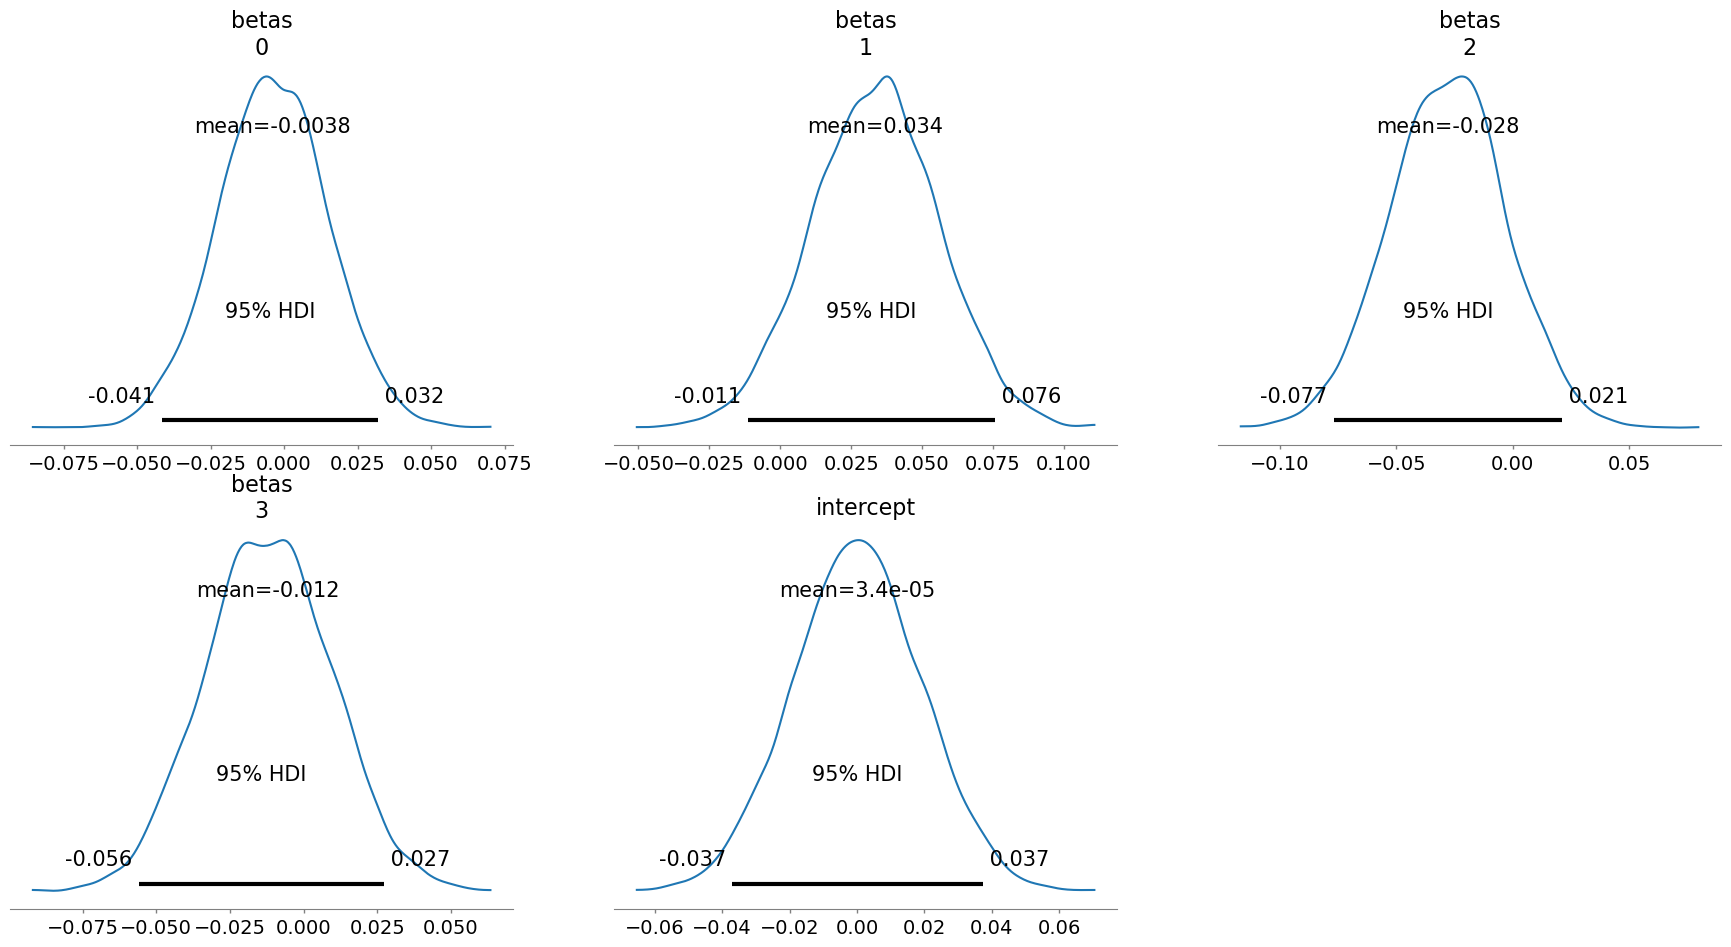

Sampling: [y_obs]


Output()

Posterior Samples Shape: (4, 2000, 2896)
Train positions shape: 2311
Test positions shape: 585
Filtered Observed train shape: (2311,)
Filtered Predicted train shape: (2311,)
Filtered Observed test shape: (585,)
Filtered Predicted test shape: (585,)
Train RMSE: 1.0483
Test RMSE: 1.0065
Train MAE: 0.7890
Test MAE: 0.7756


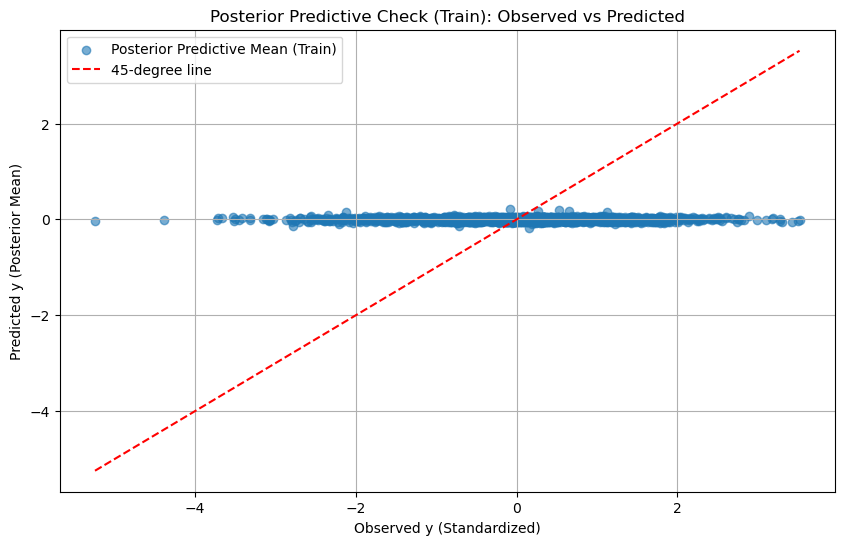

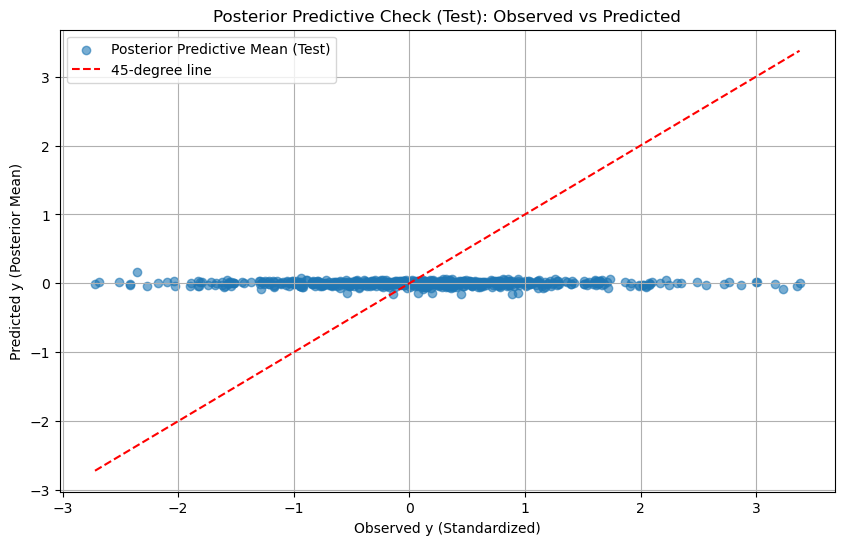

In [28]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Significant predictors identified from the analysis
refined_predictors = ['GDP', 'CPI', 'FEDL01', 'UE']

# Prepare predictors and target
X_refined = log_scaled_market[refined_predictors].dropna()
y_refined = log_scaled_market['jpm_return'].loc[X_refined.index]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_refined, y_refined, test_size=0.2, random_state=42
)

# Standardize predictors and target
X_train_standardized = (X_train - X_train.mean()) / X_train.std()
X_test_standardized = (X_test - X_train.mean()) / X_train.std()  # Use train stats for test set
y_train_standardized = (y_train - y_train.mean()) / y_train.std()
y_test_standardized = (y_test - y_train.mean()) / y_train.std()  # Use train stats for test set

# Bayesian regression model with domain-informed priors
with pm.Model() as bayesian_model:
    # Priors for coefficients with domain knowledge
    betas = pm.Normal("betas", mu=0, sigma=1, shape=len(refined_predictors))  # Priors for all predictors
    intercept = pm.Normal("intercept", mu=0, sigma=1)  # Prior for intercept
    sigma = pm.HalfNormal("sigma", sigma=1)  # Prior for noise standard deviation

    # Linear regression
    mu = intercept + pm.math.dot(X_train_standardized, betas)

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_train_standardized)

    # MCMC sampling
    trace = pm.sample(2000, tune=1000, cores=4, chains=4, return_inferencedata=True)

# Summarize posterior distributions
summary = az.summary(trace, hdi_prob=0.95)
print(summary)

# Plot posterior distributions
az.plot_posterior(trace, var_names=["betas", "intercept"], hdi_prob=0.95)
plt.show()

# Posterior predictive checks
with bayesian_model:
    posterior_predictive = pm.sample_posterior_predictive(trace)

# Posterior predictive samples
posterior_samples = posterior_predictive.posterior_predictive["y_obs"].values
print("Posterior Samples Shape:", posterior_samples.shape)

# Match train and test indices to positions within bounds
train_positions = [i for i, idx in enumerate(X_refined.index) if idx in y_train.index and i < posterior_samples.shape[2]]
test_positions = [i for i, idx in enumerate(X_refined.index) if idx in y_test.index and i < posterior_samples.shape[2]]

print("Train positions shape:", len(train_positions))
print("Test positions shape:", len(test_positions))

# Ensure predictions are correctly indexed
predicted_train = posterior_samples[:, :, train_positions].mean(axis=(0, 1))
predicted_test = posterior_samples[:, :, test_positions].mean(axis=(0, 1))

# Ensure indices are properly aligned to the original dataset
train_indices = X_refined.index[train_positions]
test_indices = X_refined.index[test_positions]

# Filter observed values to match valid positions
observed_train = y_train_standardized.loc[train_indices].values
observed_test = y_test_standardized.loc[test_indices].values

# Debugging outputs for alignment
print("Filtered Observed train shape:", observed_train.shape)
print("Filtered Predicted train shape:", predicted_train.shape)
print("Filtered Observed test shape:", observed_test.shape)
print("Filtered Predicted test shape:", predicted_test.shape)

# ---- Evaluation Metrics ---- #

# Train RMSE
rmse_train = np.sqrt(np.mean((observed_train - predicted_train) ** 2))
print(f"Train RMSE: {rmse_train:.4f}")

# Test RMSE
rmse_test = np.sqrt(np.mean((observed_test - predicted_test) ** 2))
print(f"Test RMSE: {rmse_test:.4f}")

# Train Mean Absolute Error (MAE)
mae_train = np.mean(np.abs(observed_train - predicted_train))
print(f"Train MAE: {mae_train:.4f}")

# Test Mean Absolute Error (MAE)
mae_test = np.mean(np.abs(observed_test - predicted_test))
print(f"Test MAE: {mae_test:.4f}")

# ---- Plots ---- #

# Average Observed vs. Predicted (Train)
plt.figure(figsize=(10, 6))
plt.scatter(observed_train, predicted_train, alpha=0.6, label="Posterior Predictive Mean (Train)")
plt.plot([min(observed_train), max(observed_train)], [min(observed_train), max(observed_train)], 'r--', label="45-degree line")
plt.title("Posterior Predictive Check (Train): Observed vs Predicted")
plt.xlabel("Observed y (Standardized)")
plt.ylabel("Predicted y (Posterior Mean)")
plt.legend()
plt.grid(True)
plt.show()

# Average Observed vs. Predicted (Test)
plt.figure(figsize=(10, 6))
plt.scatter(observed_test, predicted_test, alpha=0.6, label="Posterior Predictive Mean (Test)")
plt.plot([min(observed_test), max(observed_test)], [min(observed_test), max(observed_test)], 'r--', label="45-degree line")
plt.title("Posterior Predictive Check (Test): Observed vs Predicted")
plt.xlabel("Observed y (Standardized)")
plt.ylabel("Predicted y (Posterior Mean)")
plt.legend()
plt.grid(True)
plt.show()

## Model with Technical Indicators Only: JPM

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas, intercept, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 23 seconds.


            mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
betas[0]   0.561  0.031     0.500      0.623        0.0      0.0    5417.0   
betas[1]  -0.310  0.031    -0.370     -0.248        0.0      0.0    5781.0   
intercept -0.000  0.017    -0.033      0.034        0.0      0.0    7212.0   
sigma      0.938  0.012     0.915      0.962        0.0      0.0    7751.0   

           ess_tail  r_hat  
betas[0]     4856.0    1.0  
betas[1]     5215.0    1.0  
intercept    6005.0    1.0  
sigma        5766.0    1.0  


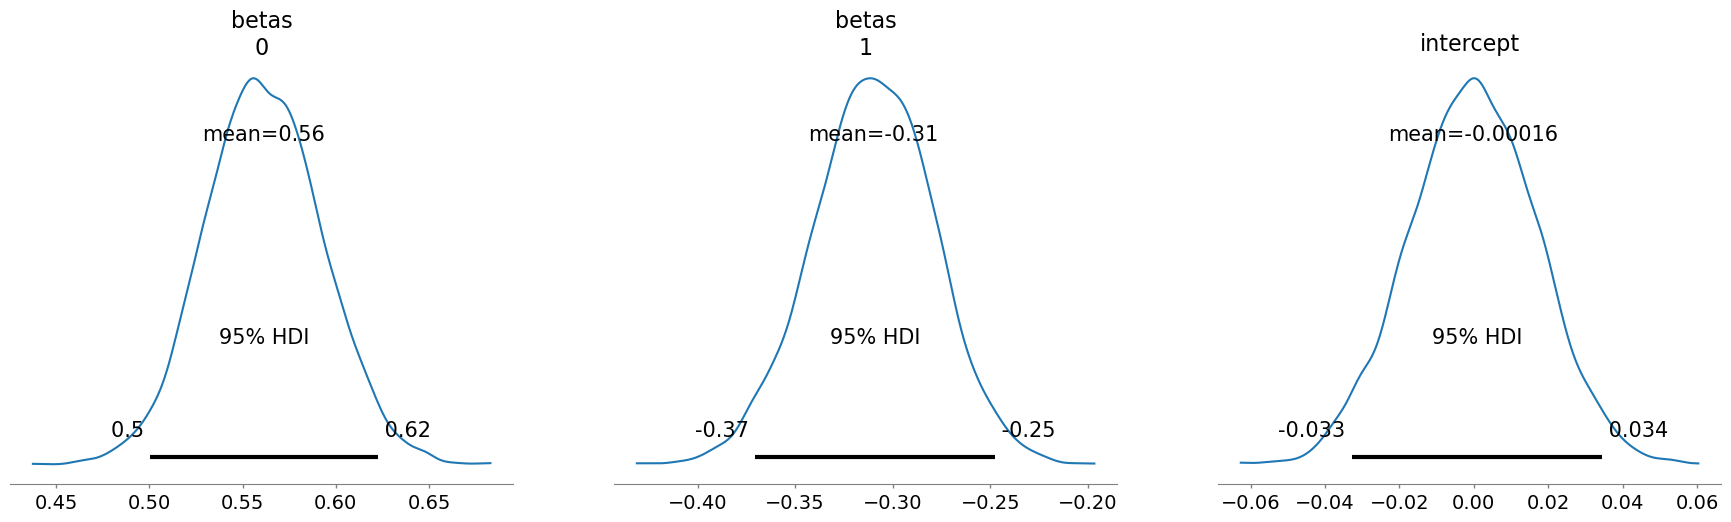

Sampling: [y_obs]


Output()

Posterior Samples Shape: (4, 2000, 2896)
Train positions shape: 2311
Test positions shape: 585
Filtered Observed train shape: (2311,)
Filtered Predicted train shape: (2311,)
Filtered Observed test shape: (585,)
Filtered Predicted test shape: (585,)
Train RMSE: 1.1060
Test RMSE: 1.0649
Train MAE: 0.8466
Test MAE: 0.8182


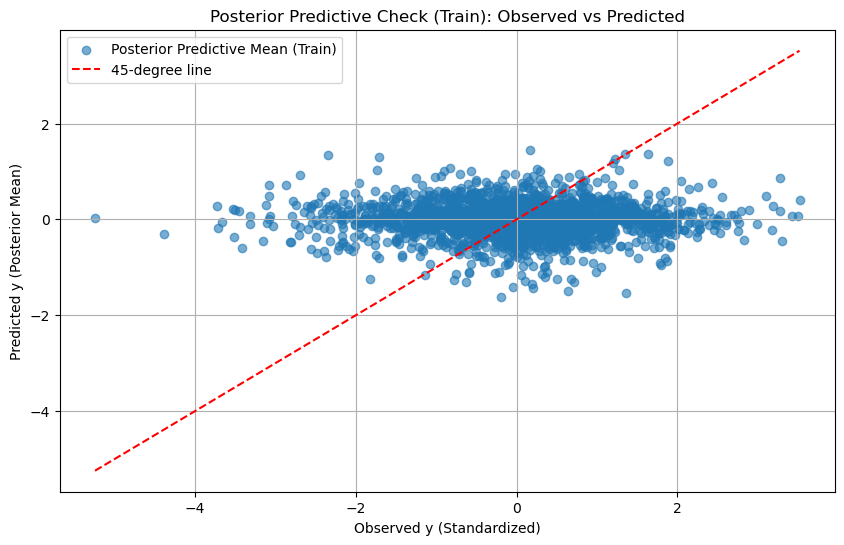

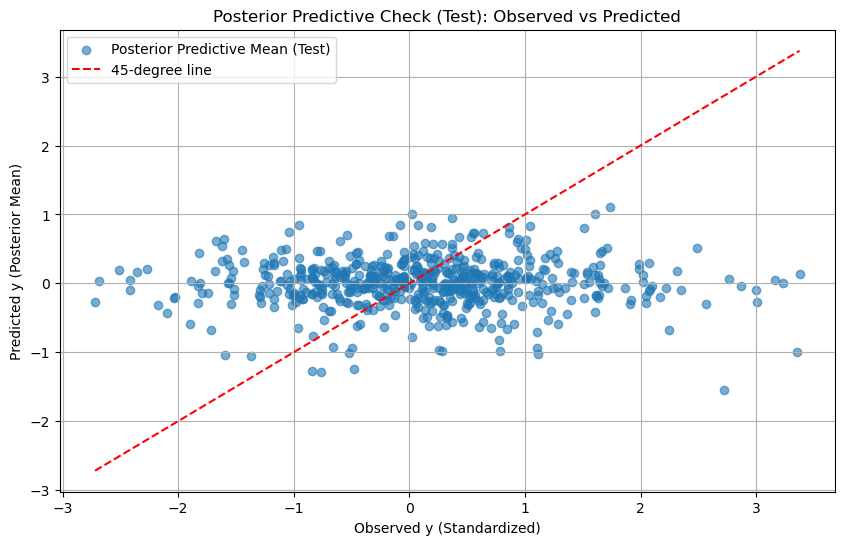

In [29]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Significant predictors identified from the analysis
refined_predictors = ['jpm_20d_ma_dev', 'jpm_rsi']

# Prepare predictors and target
X_refined = log_scaled_market[refined_predictors].dropna()
y_refined = log_scaled_market['jpm_return'].loc[X_refined.index]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_refined, y_refined, test_size=0.2, random_state=42
)

# Standardize predictors and target
X_train_standardized = (X_train - X_train.mean()) / X_train.std()
X_test_standardized = (X_test - X_train.mean()) / X_train.std()  # Use train stats for test set
y_train_standardized = (y_train - y_train.mean()) / y_train.std()
y_test_standardized = (y_test - y_train.mean()) / y_train.std()  # Use train stats for test set

# Bayesian regression model with domain-informed priors
with pm.Model() as bayesian_model:
    # Priors for coefficients with domain knowledge
    betas = pm.Normal("betas", mu=0, sigma=1, shape=len(refined_predictors))  # Priors for all predictors
    intercept = pm.Normal("intercept", mu=0, sigma=1)  # Prior for intercept
    sigma = pm.HalfNormal("sigma", sigma=1)  # Prior for noise standard deviation

    # Linear regression
    mu = intercept + pm.math.dot(X_train_standardized, betas)

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_train_standardized)

    # MCMC sampling
    trace = pm.sample(2000, tune=1000, cores=4, chains=4, return_inferencedata=True)

# Summarize posterior distributions
summary = az.summary(trace, hdi_prob=0.95)
print(summary)

# Plot posterior distributions
az.plot_posterior(trace, var_names=["betas", "intercept"], hdi_prob=0.95)
plt.show()

# Posterior predictive checks
with bayesian_model:
    posterior_predictive = pm.sample_posterior_predictive(trace)

# Posterior predictive samples
posterior_samples = posterior_predictive.posterior_predictive["y_obs"].values
print("Posterior Samples Shape:", posterior_samples.shape)

# Match train and test indices to positions within bounds
train_positions = [i for i, idx in enumerate(X_refined.index) if idx in y_train.index and i < posterior_samples.shape[2]]
test_positions = [i for i, idx in enumerate(X_refined.index) if idx in y_test.index and i < posterior_samples.shape[2]]

print("Train positions shape:", len(train_positions))
print("Test positions shape:", len(test_positions))

# Ensure predictions are correctly indexed
predicted_train = posterior_samples[:, :, train_positions].mean(axis=(0, 1))
predicted_test = posterior_samples[:, :, test_positions].mean(axis=(0, 1))

# Ensure indices are properly aligned to the original dataset
train_indices = X_refined.index[train_positions]
test_indices = X_refined.index[test_positions]

# Filter observed values to match valid positions
observed_train = y_train_standardized.loc[train_indices].values
observed_test = y_test_standardized.loc[test_indices].values

# Debugging outputs for alignment
print("Filtered Observed train shape:", observed_train.shape)
print("Filtered Predicted train shape:", predicted_train.shape)
print("Filtered Observed test shape:", observed_test.shape)
print("Filtered Predicted test shape:", predicted_test.shape)

# ---- Evaluation Metrics ---- #

# Train RMSE
rmse_train = np.sqrt(np.mean((observed_train - predicted_train) ** 2))
print(f"Train RMSE: {rmse_train:.4f}")

# Test RMSE
rmse_test = np.sqrt(np.mean((observed_test - predicted_test) ** 2))
print(f"Test RMSE: {rmse_test:.4f}")

# Train Mean Absolute Error (MAE)
mae_train = np.mean(np.abs(observed_train - predicted_train))
print(f"Train MAE: {mae_train:.4f}")

# Test Mean Absolute Error (MAE)
mae_test = np.mean(np.abs(observed_test - predicted_test))
print(f"Test MAE: {mae_test:.4f}")

# ---- Plots ---- #

# Average Observed vs. Predicted (Train)
plt.figure(figsize=(10, 6))
plt.scatter(observed_train, predicted_train, alpha=0.6, label="Posterior Predictive Mean (Train)")
plt.plot([min(observed_train), max(observed_train)], [min(observed_train), max(observed_train)], 'r--', label="45-degree line")
plt.title("Posterior Predictive Check (Train): Observed vs Predicted")
plt.xlabel("Observed y (Standardized)")
plt.ylabel("Predicted y (Posterior Mean)")
plt.legend()
plt.grid(True)
plt.show()

# Average Observed vs. Predicted (Test)
plt.figure(figsize=(10, 6))
plt.scatter(observed_test, predicted_test, alpha=0.6, label="Posterior Predictive Mean (Test)")
plt.plot([min(observed_test), max(observed_test)], [min(observed_test), max(observed_test)], 'r--', label="45-degree line")
plt.title("Posterior Predictive Check (Test): Observed vs Predicted")
plt.xlabel("Observed y (Standardized)")
plt.ylabel("Predicted y (Posterior Mean)")
plt.legend()
plt.grid(True)
plt.show()

## Model with Returns Only: JPM

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas, intercept, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 24 seconds.


            mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
betas[0]   0.088  0.018     0.054      0.124        0.0      0.0    6125.0   
betas[1]   0.043  0.018     0.009      0.078        0.0      0.0    7193.0   
betas[2]   0.691  0.025     0.641      0.738        0.0      0.0    4186.0   
betas[3]   0.028  0.017    -0.004      0.060        0.0      0.0    7273.0   
intercept  0.000  0.011    -0.021      0.021        0.0      0.0    8062.0   
sigma      0.573  0.008     0.559      0.588        0.0      0.0    7939.0   

           ess_tail  r_hat  
betas[0]     5935.0    1.0  
betas[1]     5503.0    1.0  
betas[2]     5459.0    1.0  
betas[3]     6352.0    1.0  
intercept    5652.0    1.0  
sigma        6021.0    1.0  


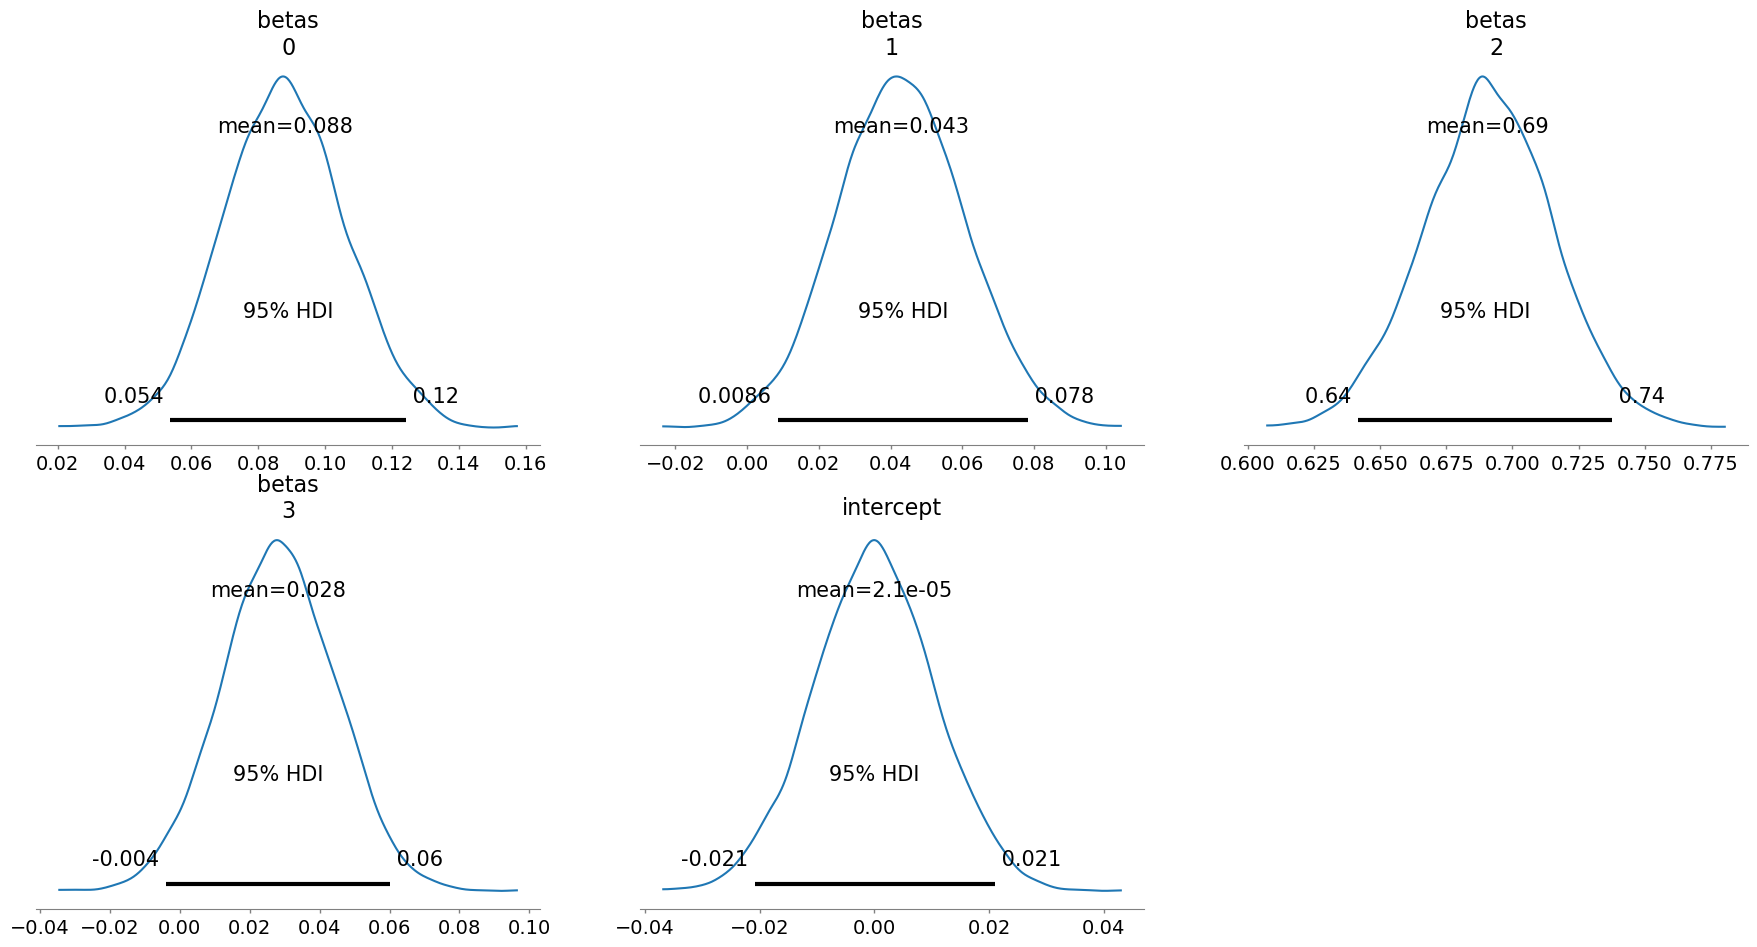

Sampling: [y_obs]


Output()

Posterior Samples Shape: (4, 2000, 2896)
Train positions shape: 2311
Test positions shape: 585
Filtered Observed train shape: (2311,)
Filtered Predicted train shape: (2311,)
Filtered Observed test shape: (585,)
Filtered Predicted test shape: (585,)
Train RMSE: 1.3171
Test RMSE: 1.3027
Train MAE: 1.0326
Test MAE: 1.0293


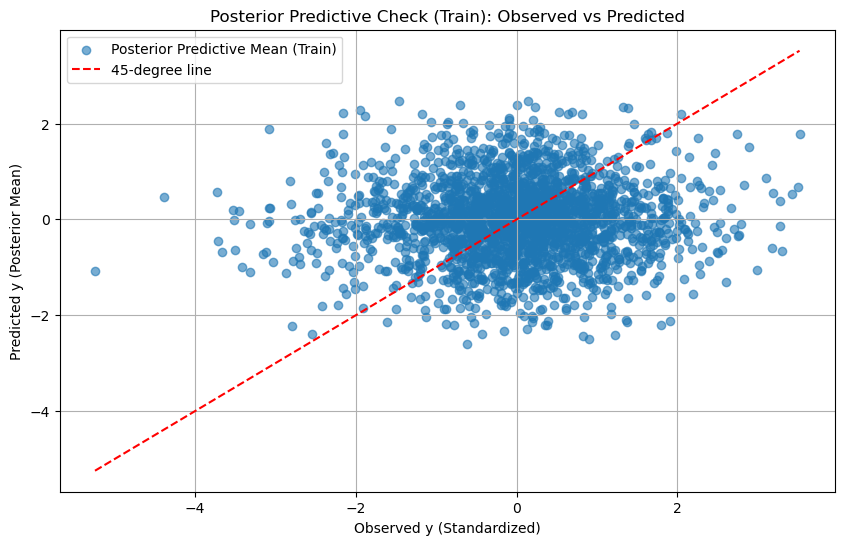

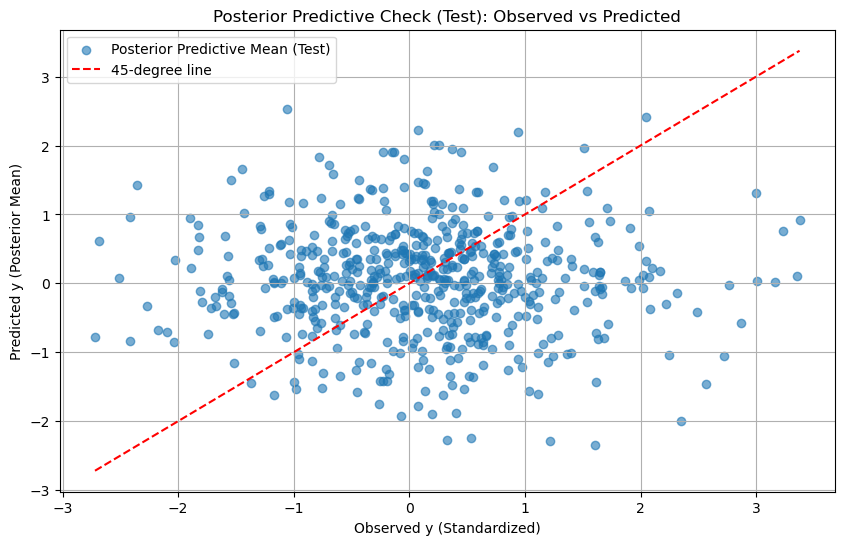

In [30]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Significant predictors identified from the analysis
refined_predictors = ['bac_return', 'citi_return', 'spf_return', 'ms_return']

# Prepare predictors and target
X_refined = log_scaled_market[refined_predictors].dropna()
y_refined = log_scaled_market['jpm_return'].loc[X_refined.index]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_refined, y_refined, test_size=0.2, random_state=42
)

# Standardize predictors and target
X_train_standardized = (X_train - X_train.mean()) / X_train.std()
X_test_standardized = (X_test - X_train.mean()) / X_train.std()  # Use train stats for test set
y_train_standardized = (y_train - y_train.mean()) / y_train.std()
y_test_standardized = (y_test - y_train.mean()) / y_train.std()  # Use train stats for test set

# Bayesian regression model with domain-informed priors
with pm.Model() as bayesian_model:
    # Priors for coefficients with domain knowledge
    betas = pm.Normal("betas", mu=0, sigma=1, shape=len(refined_predictors))  # Priors for all predictors
    intercept = pm.Normal("intercept", mu=0, sigma=1)  # Prior for intercept
    sigma = pm.HalfNormal("sigma", sigma=1)  # Prior for noise standard deviation

    # Linear regression
    mu = intercept + pm.math.dot(X_train_standardized, betas)

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_train_standardized)

    # MCMC sampling
    trace = pm.sample(2000, tune=1000, cores=4, chains=4, return_inferencedata=True)

# Summarize posterior distributions
summary = az.summary(trace, hdi_prob=0.95)
print(summary)

# Plot posterior distributions
az.plot_posterior(trace, var_names=["betas", "intercept"], hdi_prob=0.95)
plt.show()

# Posterior predictive checks
with bayesian_model:
    posterior_predictive = pm.sample_posterior_predictive(trace)

# Posterior predictive samples
posterior_samples = posterior_predictive.posterior_predictive["y_obs"].values
print("Posterior Samples Shape:", posterior_samples.shape)

# Match train and test indices to positions within bounds
train_positions = [i for i, idx in enumerate(X_refined.index) if idx in y_train.index and i < posterior_samples.shape[2]]
test_positions = [i for i, idx in enumerate(X_refined.index) if idx in y_test.index and i < posterior_samples.shape[2]]

print("Train positions shape:", len(train_positions))
print("Test positions shape:", len(test_positions))

# Ensure predictions are correctly indexed
predicted_train = posterior_samples[:, :, train_positions].mean(axis=(0, 1))
predicted_test = posterior_samples[:, :, test_positions].mean(axis=(0, 1))

# Ensure indices are properly aligned to the original dataset
train_indices = X_refined.index[train_positions]
test_indices = X_refined.index[test_positions]

# Filter observed values to match valid positions
observed_train = y_train_standardized.loc[train_indices].values
observed_test = y_test_standardized.loc[test_indices].values

# Debugging outputs for alignment
print("Filtered Observed train shape:", observed_train.shape)
print("Filtered Predicted train shape:", predicted_train.shape)
print("Filtered Observed test shape:", observed_test.shape)
print("Filtered Predicted test shape:", predicted_test.shape)

# ---- Evaluation Metrics ---- #

# Train RMSE
rmse_train = np.sqrt(np.mean((observed_train - predicted_train) ** 2))
print(f"Train RMSE: {rmse_train:.4f}")

# Test RMSE
rmse_test = np.sqrt(np.mean((observed_test - predicted_test) ** 2))
print(f"Test RMSE: {rmse_test:.4f}")

# Train Mean Absolute Error (MAE)
mae_train = np.mean(np.abs(observed_train - predicted_train))
print(f"Train MAE: {mae_train:.4f}")

# Test Mean Absolute Error (MAE)
mae_test = np.mean(np.abs(observed_test - predicted_test))
print(f"Test MAE: {mae_test:.4f}")

# ---- Plots ---- #

# Average Observed vs. Predicted (Train)
plt.figure(figsize=(10, 6))
plt.scatter(observed_train, predicted_train, alpha=0.6, label="Posterior Predictive Mean (Train)")
plt.plot([min(observed_train), max(observed_train)], [min(observed_train), max(observed_train)], 'r--', label="45-degree line")
plt.title("Posterior Predictive Check (Train): Observed vs Predicted")
plt.xlabel("Observed y (Standardized)")
plt.ylabel("Predicted y (Posterior Mean)")
plt.legend()
plt.grid(True)
plt.show()

# Average Observed vs. Predicted (Test)
plt.figure(figsize=(10, 6))
plt.scatter(observed_test, predicted_test, alpha=0.6, label="Posterior Predictive Mean (Test)")
plt.plot([min(observed_test), max(observed_test)], [min(observed_test), max(observed_test)], 'r--', label="45-degree line")
plt.title("Posterior Predictive Check (Test): Observed vs Predicted")
plt.xlabel("Observed y (Standardized)")
plt.ylabel("Predicted y (Posterior Mean)")
plt.legend()
plt.grid(True)
plt.show()

#### Model with a mix of features: JPM

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas, intercept, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 24 seconds.


            mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
betas[0]   0.705  0.018     0.671      0.740        0.0      0.0    6172.0   
betas[1]   0.093  0.018     0.058      0.126        0.0      0.0    6034.0   
betas[2]  -0.015  0.012    -0.038      0.010        0.0      0.0    8543.0   
betas[3]   0.015  0.012    -0.009      0.040        0.0      0.0    8211.0   
betas[4]   0.244  0.019     0.206      0.281        0.0      0.0    6276.0   
betas[5]  -0.132  0.019    -0.169     -0.095        0.0      0.0    6330.0   
intercept  0.000  0.010    -0.019      0.021        0.0      0.0   10652.0   
sigma      0.555  0.007     0.540      0.568        0.0      0.0   11321.0   

           ess_tail  r_hat  
betas[0]     5731.0    1.0  
betas[1]     6133.0    1.0  
betas[2]     6312.0    1.0  
betas[3]     6226.0    1.0  
betas[4]     5834.0    1.0  
betas[5]     5933.0    1.0  
intercept    5797.0    1.0  
sigma        5851.0    1.0  


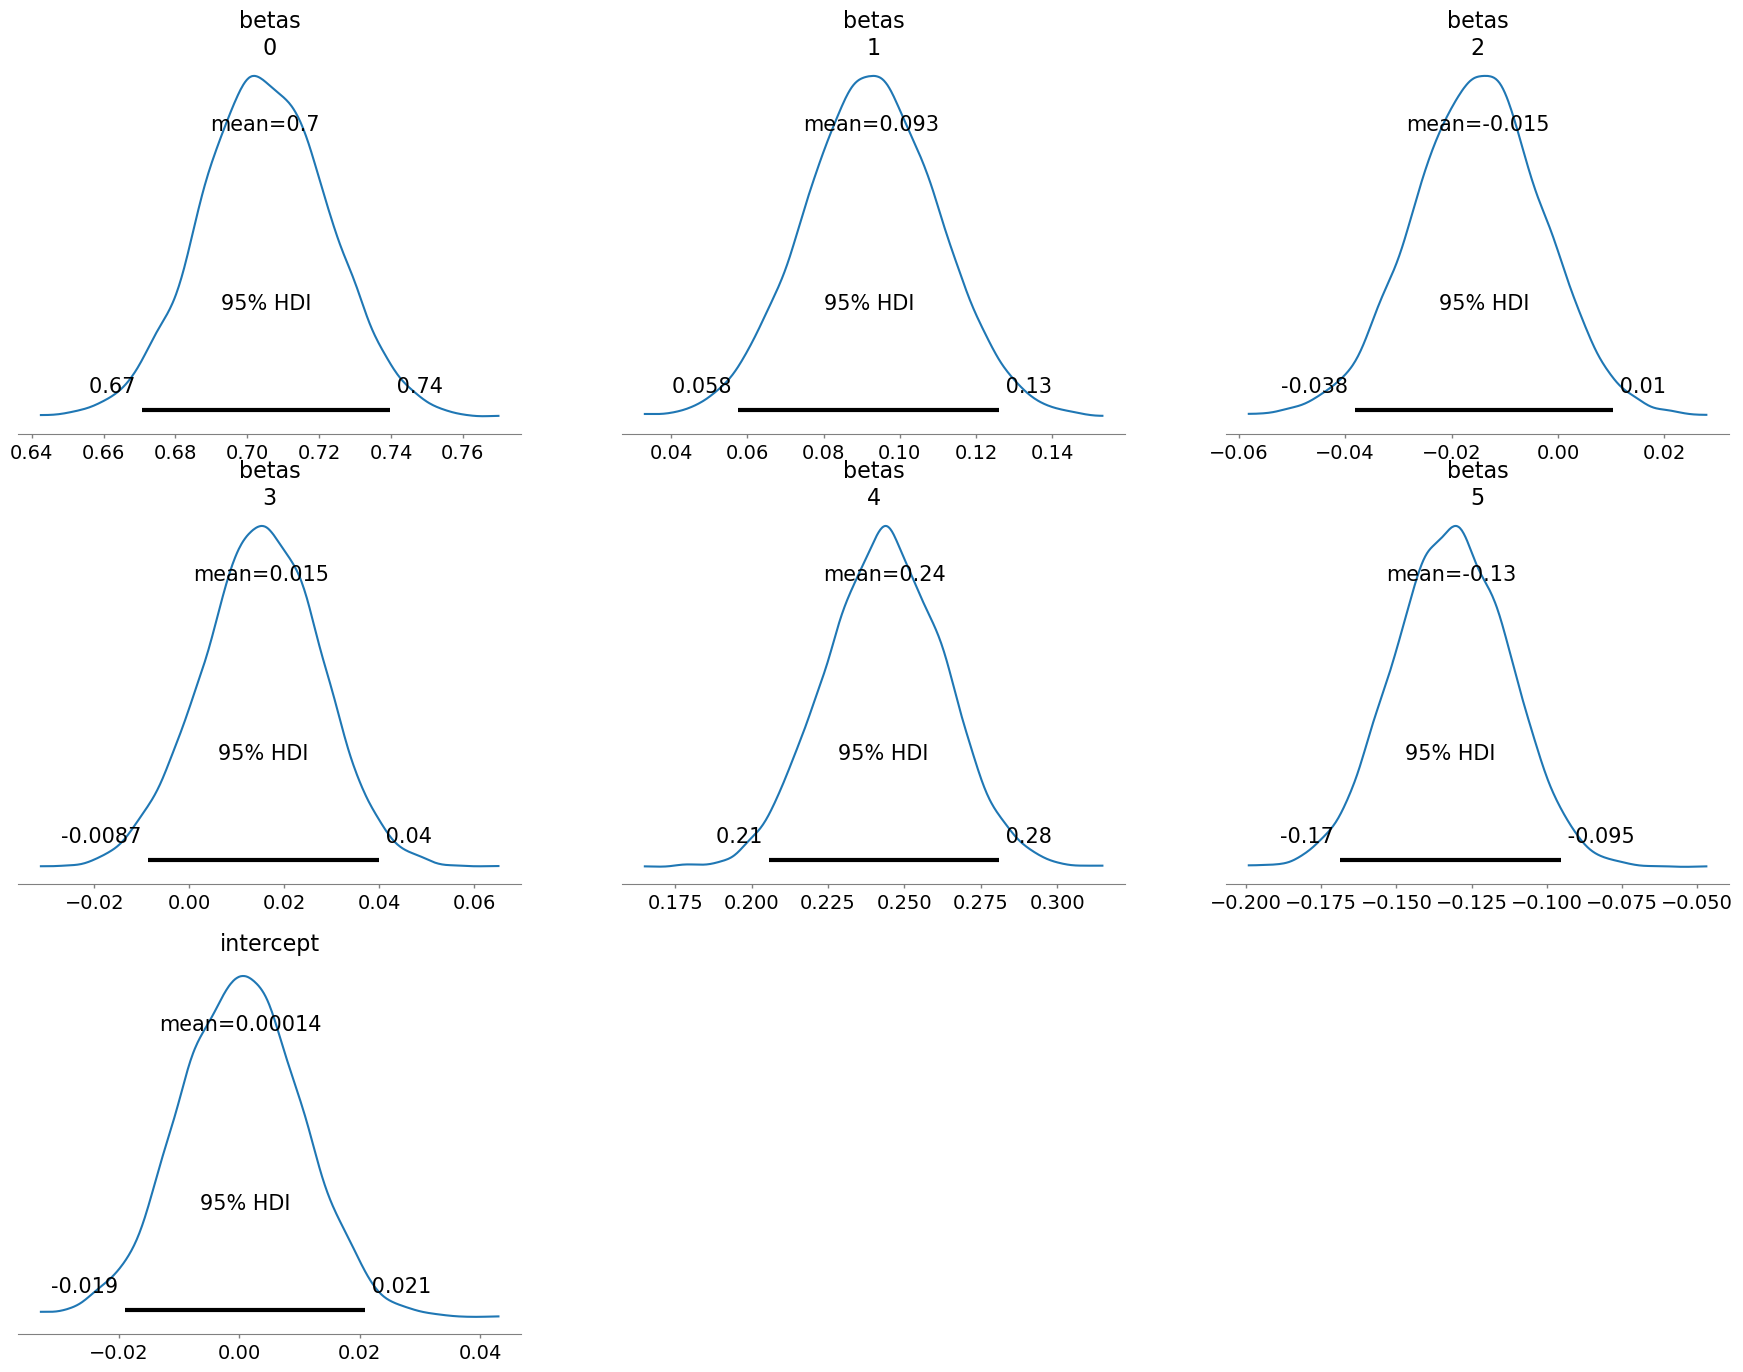

Sampling: [y_obs]


Output()

Posterior Samples Shape: (4, 2000, 2896)
Train positions shape: 2311
Test positions shape: 585
Filtered Observed train shape: (2311,)
Filtered Predicted train shape: (2311,)
Filtered Observed test shape: (585,)
Filtered Predicted test shape: (585,)
Train RMSE: 1.3273
Test RMSE: 1.3122
Train MAE: 1.0398
Test MAE: 1.0387


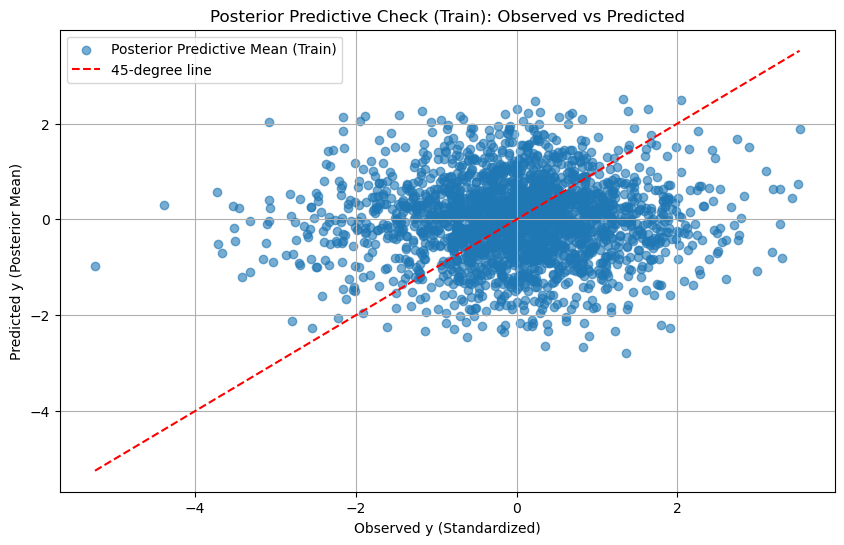

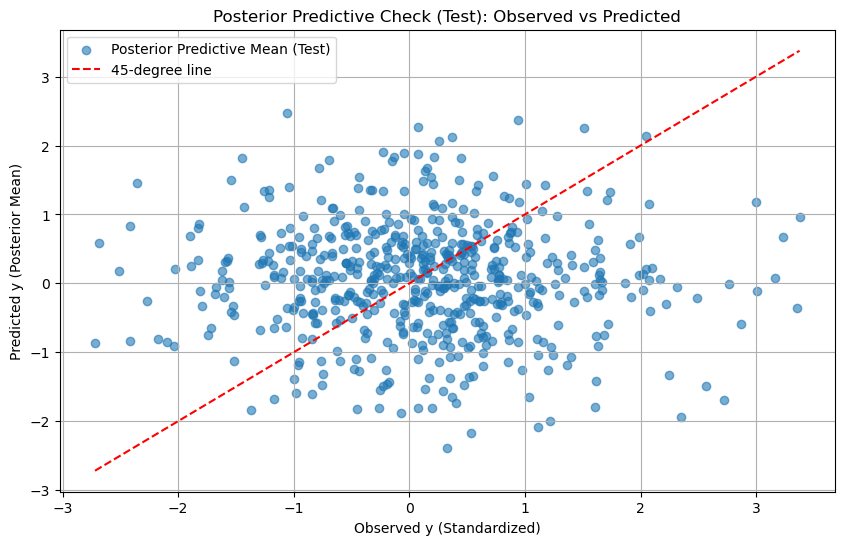

In [31]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Significant predictors identified from the analysis
refined_predictors = ['spf_return', 'bac_return', 'FEDL01', 'CPI', 'jpm_20d_ma_dev', 'jpm_rsi']

# Prepare predictors and target
X_refined = log_scaled_market[refined_predictors].dropna()
y_refined = log_scaled_market['jpm_return'].loc[X_refined.index]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_refined, y_refined, test_size=0.2, random_state=42
)

# Standardize predictors and target
X_train_standardized = (X_train - X_train.mean()) / X_train.std()
X_test_standardized = (X_test - X_train.mean()) / X_train.std()  # Use train stats for test set
y_train_standardized = (y_train - y_train.mean()) / y_train.std()
y_test_standardized = (y_test - y_train.mean()) / y_train.std()  # Use train stats for test set

# Bayesian regression model with domain-informed priors
with pm.Model() as bayesian_model:
    # Priors for coefficients with domain knowledge
    betas = pm.Normal("betas", mu=0, sigma=1, shape=len(refined_predictors))  # Priors for all predictors
    intercept = pm.Normal("intercept", mu=0, sigma=1)  # Prior for intercept
    sigma = pm.HalfNormal("sigma", sigma=1)  # Prior for noise standard deviation

    # Linear regression
    mu = intercept + pm.math.dot(X_train_standardized, betas)

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_train_standardized)

    # MCMC sampling
    trace = pm.sample(2000, tune=1000, cores=4, chains=4, return_inferencedata=True)

# Summarize posterior distributions
summary = az.summary(trace, hdi_prob=0.95)
print(summary)

# Plot posterior distributions
az.plot_posterior(trace, var_names=["betas", "intercept"], hdi_prob=0.95)
plt.show()

# Posterior predictive checks
with bayesian_model:
    posterior_predictive = pm.sample_posterior_predictive(trace)

# Posterior predictive samples
posterior_samples = posterior_predictive.posterior_predictive["y_obs"].values
print("Posterior Samples Shape:", posterior_samples.shape)

# Match train and test indices to positions within bounds
train_positions = [i for i, idx in enumerate(X_refined.index) if idx in y_train.index and i < posterior_samples.shape[2]]
test_positions = [i for i, idx in enumerate(X_refined.index) if idx in y_test.index and i < posterior_samples.shape[2]]

print("Train positions shape:", len(train_positions))
print("Test positions shape:", len(test_positions))

# Ensure predictions are correctly indexed
predicted_train = posterior_samples[:, :, train_positions].mean(axis=(0, 1))
predicted_test = posterior_samples[:, :, test_positions].mean(axis=(0, 1))

# Ensure indices are properly aligned to the original dataset
train_indices = X_refined.index[train_positions]
test_indices = X_refined.index[test_positions]

# Filter observed values to match valid positions
observed_train = y_train_standardized.loc[train_indices].values
observed_test = y_test_standardized.loc[test_indices].values

# Debugging outputs for alignment
print("Filtered Observed train shape:", observed_train.shape)
print("Filtered Predicted train shape:", predicted_train.shape)
print("Filtered Observed test shape:", observed_test.shape)
print("Filtered Predicted test shape:", predicted_test.shape)

# ---- Evaluation Metrics ---- #

# Train RMSE
rmse_train = np.sqrt(np.mean((observed_train - predicted_train) ** 2))
print(f"Train RMSE: {rmse_train:.4f}")

# Test RMSE
rmse_test = np.sqrt(np.mean((observed_test - predicted_test) ** 2))
print(f"Test RMSE: {rmse_test:.4f}")

# Train Mean Absolute Error (MAE)
mae_train = np.mean(np.abs(observed_train - predicted_train))
print(f"Train MAE: {mae_train:.4f}")

# Test Mean Absolute Error (MAE)
mae_test = np.mean(np.abs(observed_test - predicted_test))
print(f"Test MAE: {mae_test:.4f}")

# ---- Plots ---- #

# Average Observed vs. Predicted (Train)
plt.figure(figsize=(10, 6))
plt.scatter(observed_train, predicted_train, alpha=0.6, label="Posterior Predictive Mean (Train)")
plt.plot([min(observed_train), max(observed_train)], [min(observed_train), max(observed_train)], 'r--', label="45-degree line")
plt.title("Posterior Predictive Check (Train): Observed vs Predicted")
plt.xlabel("Observed y (Standardized)")
plt.ylabel("Predicted y (Posterior Mean)")
plt.legend()
plt.grid(True)
plt.show()

# Average Observed vs. Predicted (Test)
plt.figure(figsize=(10, 6))
plt.scatter(observed_test, predicted_test, alpha=0.6, label="Posterior Predictive Mean (Test)")
plt.plot([min(observed_test), max(observed_test)], [min(observed_test), max(observed_test)], 'r--', label="45-degree line")
plt.title("Posterior Predictive Check (Test): Observed vs Predicted")
plt.xlabel("Observed y (Standardized)")
plt.ylabel("Predicted y (Posterior Mean)")
plt.legend()
plt.grid(True)
plt.show()

## BAC Analysis

#### Model with Economic Indicators Only: BAC

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas, intercept, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 24 seconds.


            mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
betas[0]  -0.005  0.019    -0.041      0.032        0.0      0.0    8304.0   
betas[1]   0.022  0.023    -0.022      0.066        0.0      0.0    7411.0   
betas[2]   0.001  0.025    -0.048      0.051        0.0      0.0    6326.0   
betas[3]   0.007  0.021    -0.033      0.051        0.0      0.0    7657.0   
intercept -0.000  0.018    -0.036      0.036        0.0      0.0    9499.0   
sigma      1.000  0.013     0.975      1.026        0.0      0.0    9855.0   

           ess_tail  r_hat  
betas[0]     6479.0    1.0  
betas[1]     6094.0    1.0  
betas[2]     6124.0    1.0  
betas[3]     6233.0    1.0  
intercept    6364.0    1.0  
sigma        6284.0    1.0  


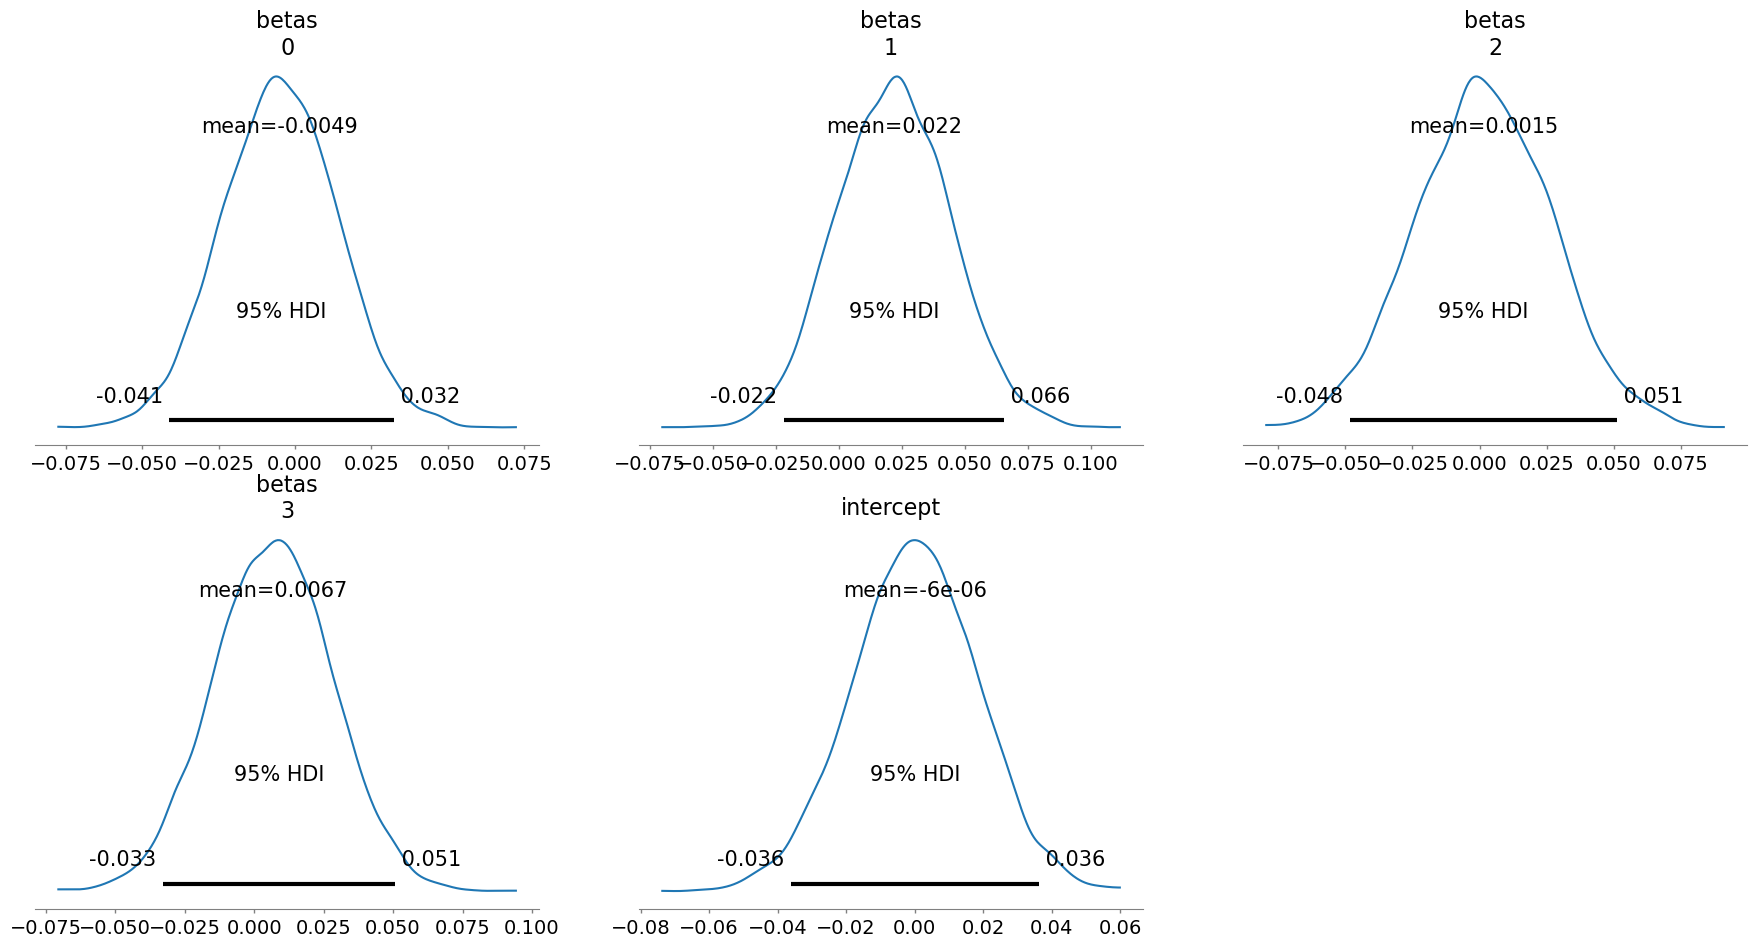

Sampling: [y_obs]


Output()

Posterior Samples Shape: (4, 2000, 2896)
Train positions shape: 2311
Test positions shape: 585
Filtered Observed train shape: (2311,)
Filtered Predicted train shape: (2311,)
Filtered Observed test shape: (585,)
Filtered Predicted test shape: (585,)
Train RMSE: 1.0249
Test RMSE: 0.9607
Train MAE: 0.7690
Test MAE: 0.7389


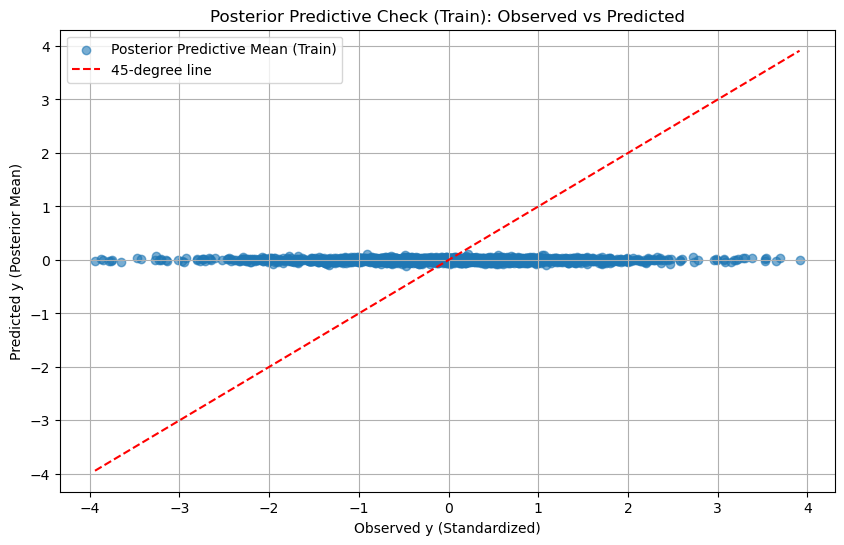

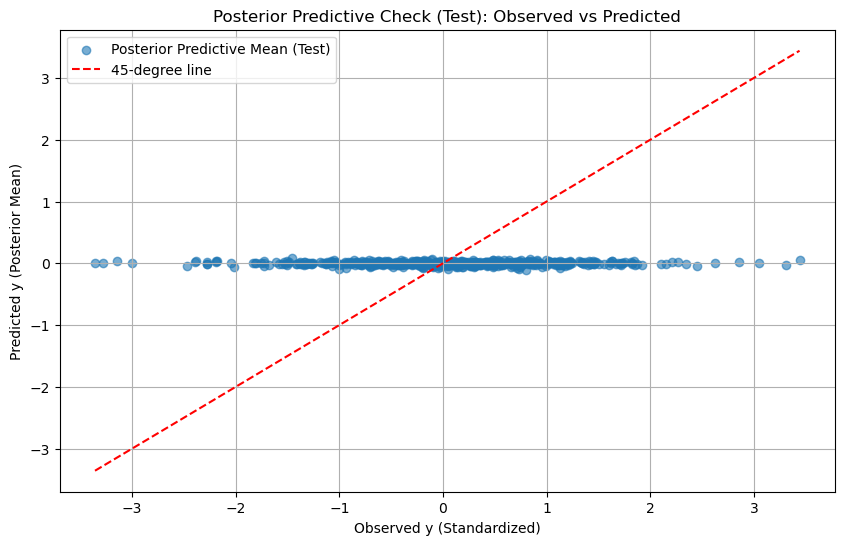

In [32]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Significant predictors identified from the analysis
refined_predictors = ['GDP', 'CPI', 'FEDL01', 'UE']

# Prepare predictors and target
X_refined = log_scaled_market[refined_predictors].dropna()
y_refined = log_scaled_market['bac_return'].loc[X_refined.index]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_refined, y_refined, test_size=0.2, random_state=42
)

# Standardize predictors and target
X_train_standardized = (X_train - X_train.mean()) / X_train.std()
X_test_standardized = (X_test - X_train.mean()) / X_train.std()  # Use train stats for test set
y_train_standardized = (y_train - y_train.mean()) / y_train.std()
y_test_standardized = (y_test - y_train.mean()) / y_train.std()  # Use train stats for test set

# Bayesian regression model with domain-informed priors
with pm.Model() as bayesian_model:
    # Priors for coefficients with domain knowledge
    betas = pm.Normal("betas", mu=0, sigma=1, shape=len(refined_predictors))  # Priors for all predictors
    intercept = pm.Normal("intercept", mu=0, sigma=1)  # Prior for intercept
    sigma = pm.HalfNormal("sigma", sigma=1)  # Prior for noise standard deviation

    # Linear regression
    mu = intercept + pm.math.dot(X_train_standardized, betas)

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_train_standardized)

    # MCMC sampling
    trace = pm.sample(2000, tune=1000, cores=4, chains=4, return_inferencedata=True)

# Summarize posterior distributions
summary = az.summary(trace, hdi_prob=0.95)
print(summary)

# Plot posterior distributions
az.plot_posterior(trace, var_names=["betas", "intercept"], hdi_prob=0.95)
plt.show()

# Posterior predictive checks
with bayesian_model:
    posterior_predictive = pm.sample_posterior_predictive(trace)

# Posterior predictive samples
posterior_samples = posterior_predictive.posterior_predictive["y_obs"].values
print("Posterior Samples Shape:", posterior_samples.shape)

# Match train and test indices to positions within bounds
train_positions = [i for i, idx in enumerate(X_refined.index) if idx in y_train.index and i < posterior_samples.shape[2]]
test_positions = [i for i, idx in enumerate(X_refined.index) if idx in y_test.index and i < posterior_samples.shape[2]]

print("Train positions shape:", len(train_positions))
print("Test positions shape:", len(test_positions))

# Ensure predictions are correctly indexed
predicted_train = posterior_samples[:, :, train_positions].mean(axis=(0, 1))
predicted_test = posterior_samples[:, :, test_positions].mean(axis=(0, 1))

# Ensure indices are properly aligned to the original dataset
train_indices = X_refined.index[train_positions]
test_indices = X_refined.index[test_positions]

# Filter observed values to match valid positions
observed_train = y_train_standardized.loc[train_indices].values
observed_test = y_test_standardized.loc[test_indices].values

# Debugging outputs for alignment
print("Filtered Observed train shape:", observed_train.shape)
print("Filtered Predicted train shape:", predicted_train.shape)
print("Filtered Observed test shape:", observed_test.shape)
print("Filtered Predicted test shape:", predicted_test.shape)

# ---- Evaluation Metrics ---- #

# Train RMSE
rmse_train = np.sqrt(np.mean((observed_train - predicted_train) ** 2))
print(f"Train RMSE: {rmse_train:.4f}")

# Test RMSE
rmse_test = np.sqrt(np.mean((observed_test - predicted_test) ** 2))
print(f"Test RMSE: {rmse_test:.4f}")

# Train Mean Absolute Error (MAE)
mae_train = np.mean(np.abs(observed_train - predicted_train))
print(f"Train MAE: {mae_train:.4f}")

# Test Mean Absolute Error (MAE)
mae_test = np.mean(np.abs(observed_test - predicted_test))
print(f"Test MAE: {mae_test:.4f}")

# ---- Plots ---- #

# Average Observed vs. Predicted (Train)
plt.figure(figsize=(10, 6))
plt.scatter(observed_train, predicted_train, alpha=0.6, label="Posterior Predictive Mean (Train)")
plt.plot([min(observed_train), max(observed_train)], [min(observed_train), max(observed_train)], 'r--', label="45-degree line")
plt.title("Posterior Predictive Check (Train): Observed vs Predicted")
plt.xlabel("Observed y (Standardized)")
plt.ylabel("Predicted y (Posterior Mean)")
plt.legend()
plt.grid(True)
plt.show()

# Average Observed vs. Predicted (Test)
plt.figure(figsize=(10, 6))
plt.scatter(observed_test, predicted_test, alpha=0.6, label="Posterior Predictive Mean (Test)")
plt.plot([min(observed_test), max(observed_test)], [min(observed_test), max(observed_test)], 'r--', label="45-degree line")
plt.title("Posterior Predictive Check (Test): Observed vs Predicted")
plt.xlabel("Observed y (Standardized)")
plt.ylabel("Predicted y (Posterior Mean)")
plt.legend()
plt.grid(True)
plt.show()

#### Model with Technical Indicators Only: BAC

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas, intercept, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 25 seconds.


            mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
betas[0]   0.576  0.033     0.512      0.642        0.0      0.0    5320.0   
betas[1]  -0.335  0.033    -0.400     -0.272        0.0      0.0    5309.0   
intercept -0.000  0.017    -0.034      0.034        0.0      0.0    7679.0   
sigma      0.940  0.013     0.916      0.965        0.0      0.0    7641.0   

           ess_tail  r_hat  
betas[0]     5066.0    1.0  
betas[1]     5064.0    1.0  
intercept    5676.0    1.0  
sigma        5396.0    1.0  


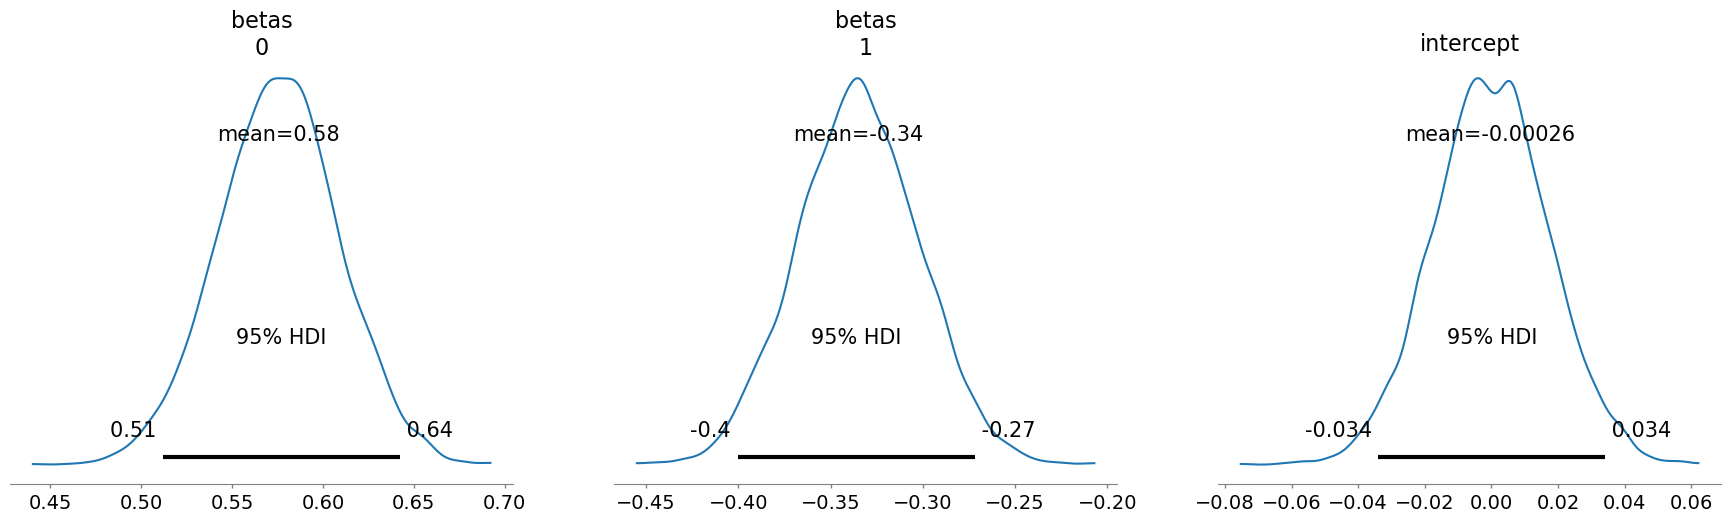

Sampling: [y_obs]


Output()

Posterior Samples Shape: (4, 2000, 2896)
Train positions shape: 2311
Test positions shape: 585
Filtered Observed train shape: (2311,)
Filtered Predicted train shape: (2311,)
Filtered Observed test shape: (585,)
Filtered Predicted test shape: (585,)
Train RMSE: 1.0819
Test RMSE: 1.0106
Train MAE: 0.8247
Test MAE: 0.7849


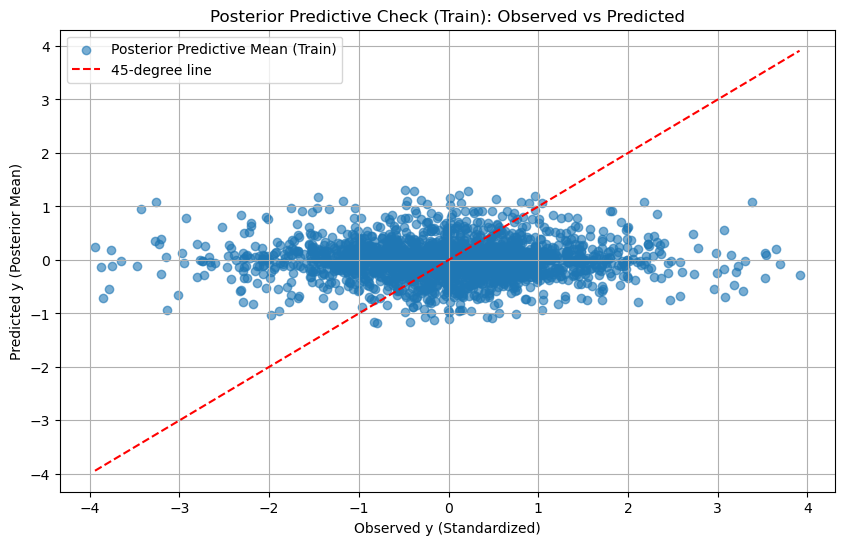

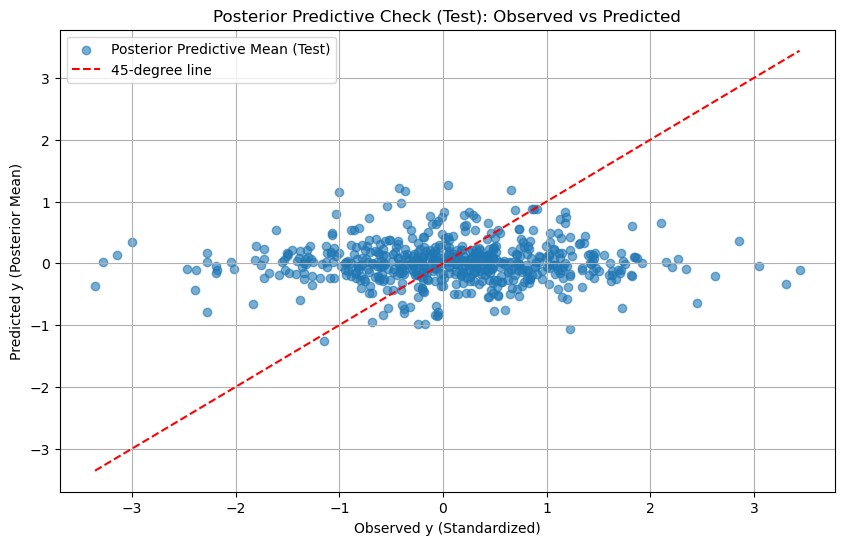

In [33]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Significant predictors identified from the analysis
refined_predictors = ['bac_20d_ma_dev', 'bac_rsi']

# Prepare predictors and target
X_refined = log_scaled_market[refined_predictors].dropna()
y_refined = log_scaled_market['bac_return'].loc[X_refined.index]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_refined, y_refined, test_size=0.2, random_state=42
)

# Standardize predictors and target
X_train_standardized = (X_train - X_train.mean()) / X_train.std()
X_test_standardized = (X_test - X_train.mean()) / X_train.std()  # Use train stats for test set
y_train_standardized = (y_train - y_train.mean()) / y_train.std()
y_test_standardized = (y_test - y_train.mean()) / y_train.std()  # Use train stats for test set

# Bayesian regression model with domain-informed priors
with pm.Model() as bayesian_model:
    # Priors for coefficients with domain knowledge
    betas = pm.Normal("betas", mu=0, sigma=1, shape=len(refined_predictors))  # Priors for all predictors
    intercept = pm.Normal("intercept", mu=0, sigma=1)  # Prior for intercept
    sigma = pm.HalfNormal("sigma", sigma=1)  # Prior for noise standard deviation

    # Linear regression
    mu = intercept + pm.math.dot(X_train_standardized, betas)

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_train_standardized)

    # MCMC sampling
    trace = pm.sample(2000, tune=1000, cores=4, chains=4, return_inferencedata=True)

# Summarize posterior distributions
summary = az.summary(trace, hdi_prob=0.95)
print(summary)

# Plot posterior distributions
az.plot_posterior(trace, var_names=["betas", "intercept"], hdi_prob=0.95)
plt.show()

# Posterior predictive checks
with bayesian_model:
    posterior_predictive = pm.sample_posterior_predictive(trace)

# Posterior predictive samples
posterior_samples = posterior_predictive.posterior_predictive["y_obs"].values
print("Posterior Samples Shape:", posterior_samples.shape)

# Match train and test indices to positions within bounds
train_positions = [i for i, idx in enumerate(X_refined.index) if idx in y_train.index and i < posterior_samples.shape[2]]
test_positions = [i for i, idx in enumerate(X_refined.index) if idx in y_test.index and i < posterior_samples.shape[2]]

print("Train positions shape:", len(train_positions))
print("Test positions shape:", len(test_positions))

# Ensure predictions are correctly indexed
predicted_train = posterior_samples[:, :, train_positions].mean(axis=(0, 1))
predicted_test = posterior_samples[:, :, test_positions].mean(axis=(0, 1))

# Ensure indices are properly aligned to the original dataset
train_indices = X_refined.index[train_positions]
test_indices = X_refined.index[test_positions]

# Filter observed values to match valid positions
observed_train = y_train_standardized.loc[train_indices].values
observed_test = y_test_standardized.loc[test_indices].values

# Debugging outputs for alignment
print("Filtered Observed train shape:", observed_train.shape)
print("Filtered Predicted train shape:", predicted_train.shape)
print("Filtered Observed test shape:", observed_test.shape)
print("Filtered Predicted test shape:", predicted_test.shape)

# ---- Evaluation Metrics ---- #

# Train RMSE
rmse_train = np.sqrt(np.mean((observed_train - predicted_train) ** 2))
print(f"Train RMSE: {rmse_train:.4f}")

# Test RMSE
rmse_test = np.sqrt(np.mean((observed_test - predicted_test) ** 2))
print(f"Test RMSE: {rmse_test:.4f}")

# Train Mean Absolute Error (MAE)
mae_train = np.mean(np.abs(observed_train - predicted_train))
print(f"Train MAE: {mae_train:.4f}")

# Test Mean Absolute Error (MAE)
mae_test = np.mean(np.abs(observed_test - predicted_test))
print(f"Test MAE: {mae_test:.4f}")

# ---- Plots ---- #

# Average Observed vs. Predicted (Train)
plt.figure(figsize=(10, 6))
plt.scatter(observed_train, predicted_train, alpha=0.6, label="Posterior Predictive Mean (Train)")
plt.plot([min(observed_train), max(observed_train)], [min(observed_train), max(observed_train)], 'r--', label="45-degree line")
plt.title("Posterior Predictive Check (Train): Observed vs Predicted")
plt.xlabel("Observed y (Standardized)")
plt.ylabel("Predicted y (Posterior Mean)")
plt.legend()
plt.grid(True)
plt.show()

# Average Observed vs. Predicted (Test)
plt.figure(figsize=(10, 6))
plt.scatter(observed_test, predicted_test, alpha=0.6, label="Posterior Predictive Mean (Test)")
plt.plot([min(observed_test), max(observed_test)], [min(observed_test), max(observed_test)], 'r--', label="45-degree line")
plt.title("Posterior Predictive Check (Test): Observed vs Predicted")
plt.xlabel("Observed y (Standardized)")
plt.ylabel("Predicted y (Posterior Mean)")
plt.legend()
plt.grid(True)
plt.show()

#### Model with Returns Only: BAC

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas, intercept, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 26 seconds.


            mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
betas[0]   0.093  0.019     0.056      0.129        0.0      0.0    6295.0   
betas[1]   0.086  0.018     0.049      0.121        0.0      0.0    7219.0   
betas[2]   0.676  0.025     0.628      0.727        0.0      0.0    4494.0   
betas[3]  -0.022  0.017    -0.055      0.011        0.0      0.0    7272.0   
intercept  0.000  0.011    -0.021      0.022        0.0      0.0    9308.0   
sigma      0.590  0.008     0.576      0.606        0.0      0.0    9333.0   

           ess_tail  r_hat  
betas[0]     5362.0    1.0  
betas[1]     5883.0    1.0  
betas[2]     4718.0    1.0  
betas[3]     5806.0    1.0  
intercept    6008.0    1.0  
sigma        5576.0    1.0  


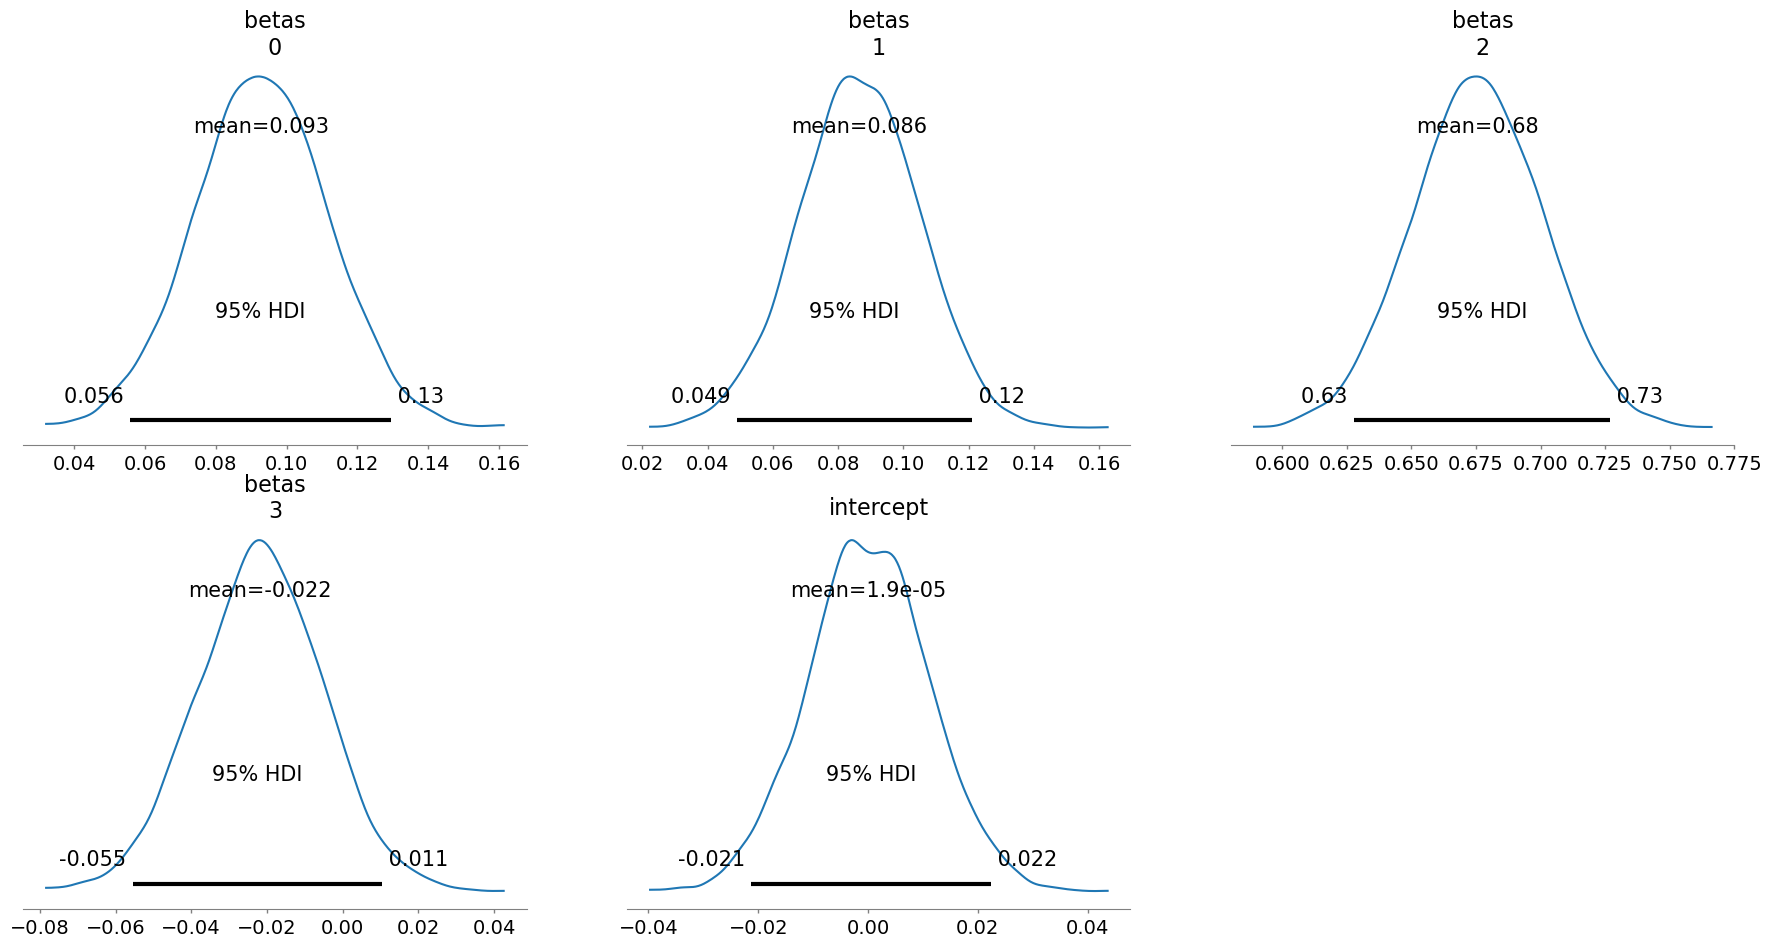

Sampling: [y_obs]


Output()

Posterior Samples Shape: (4, 2000, 2896)
Train positions shape: 2311
Test positions shape: 585
Filtered Observed train shape: (2311,)
Filtered Predicted train shape: (2311,)
Filtered Observed test shape: (585,)
Filtered Predicted test shape: (585,)
Train RMSE: 1.3027
Test RMSE: 1.2412
Train MAE: 1.0226
Test MAE: 0.9538


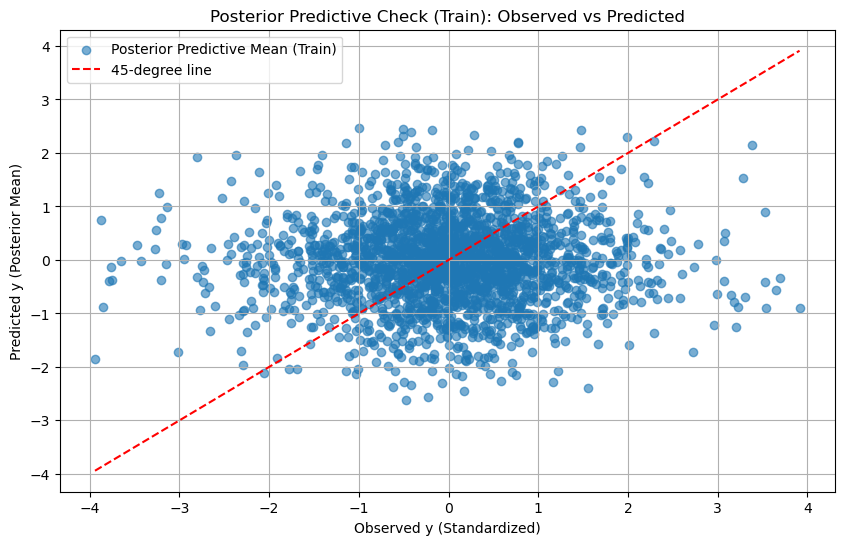

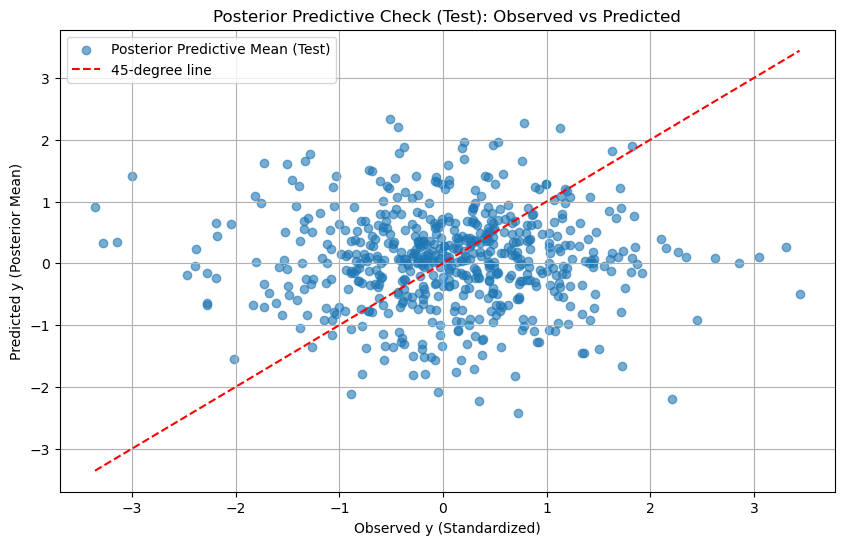

In [34]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Significant predictors identified from the analysis
refined_predictors = ['jpm_return', 'citi_return', 'spf_return', 'ms_return']

# Prepare predictors and target
X_refined = log_scaled_market[refined_predictors].dropna()
y_refined = log_scaled_market['bac_return'].loc[X_refined.index]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_refined, y_refined, test_size=0.2, random_state=42
)

# Standardize predictors and target
X_train_standardized = (X_train - X_train.mean()) / X_train.std()
X_test_standardized = (X_test - X_train.mean()) / X_train.std()  # Use train stats for test set
y_train_standardized = (y_train - y_train.mean()) / y_train.std()
y_test_standardized = (y_test - y_train.mean()) / y_train.std()  # Use train stats for test set

# Bayesian regression model with domain-informed priors
with pm.Model() as bayesian_model:
    # Priors for coefficients with domain knowledge
    betas = pm.Normal("betas", mu=0, sigma=1, shape=len(refined_predictors))  # Priors for all predictors
    intercept = pm.Normal("intercept", mu=0, sigma=1)  # Prior for intercept
    sigma = pm.HalfNormal("sigma", sigma=1)  # Prior for noise standard deviation

    # Linear regression
    mu = intercept + pm.math.dot(X_train_standardized, betas)

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_train_standardized)

    # MCMC sampling
    trace = pm.sample(2000, tune=1000, cores=4, chains=4, return_inferencedata=True)

# Summarize posterior distributions
summary = az.summary(trace, hdi_prob=0.95)
print(summary)

# Plot posterior distributions
az.plot_posterior(trace, var_names=["betas", "intercept"], hdi_prob=0.95)
plt.show()

# Posterior predictive checks
with bayesian_model:
    posterior_predictive = pm.sample_posterior_predictive(trace)

# Posterior predictive samples
posterior_samples = posterior_predictive.posterior_predictive["y_obs"].values
print("Posterior Samples Shape:", posterior_samples.shape)

# Match train and test indices to positions within bounds
train_positions = [i for i, idx in enumerate(X_refined.index) if idx in y_train.index and i < posterior_samples.shape[2]]
test_positions = [i for i, idx in enumerate(X_refined.index) if idx in y_test.index and i < posterior_samples.shape[2]]

print("Train positions shape:", len(train_positions))
print("Test positions shape:", len(test_positions))

# Ensure predictions are correctly indexed
predicted_train = posterior_samples[:, :, train_positions].mean(axis=(0, 1))
predicted_test = posterior_samples[:, :, test_positions].mean(axis=(0, 1))

# Ensure indices are properly aligned to the original dataset
train_indices = X_refined.index[train_positions]
test_indices = X_refined.index[test_positions]

# Filter observed values to match valid positions
observed_train = y_train_standardized.loc[train_indices].values
observed_test = y_test_standardized.loc[test_indices].values

# Debugging outputs for alignment
print("Filtered Observed train shape:", observed_train.shape)
print("Filtered Predicted train shape:", predicted_train.shape)
print("Filtered Observed test shape:", observed_test.shape)
print("Filtered Predicted test shape:", predicted_test.shape)

# ---- Evaluation Metrics ---- #

# Train RMSE
rmse_train = np.sqrt(np.mean((observed_train - predicted_train) ** 2))
print(f"Train RMSE: {rmse_train:.4f}")

# Test RMSE
rmse_test = np.sqrt(np.mean((observed_test - predicted_test) ** 2))
print(f"Test RMSE: {rmse_test:.4f}")

# Train Mean Absolute Error (MAE)
mae_train = np.mean(np.abs(observed_train - predicted_train))
print(f"Train MAE: {mae_train:.4f}")

# Test Mean Absolute Error (MAE)
mae_test = np.mean(np.abs(observed_test - predicted_test))
print(f"Test MAE: {mae_test:.4f}")

# ---- Plots ---- #

# Average Observed vs. Predicted (Train)
plt.figure(figsize=(10, 6))
plt.scatter(observed_train, predicted_train, alpha=0.6, label="Posterior Predictive Mean (Train)")
plt.plot([min(observed_train), max(observed_train)], [min(observed_train), max(observed_train)], 'r--', label="45-degree line")
plt.title("Posterior Predictive Check (Train): Observed vs Predicted")
plt.xlabel("Observed y (Standardized)")
plt.ylabel("Predicted y (Posterior Mean)")
plt.legend()
plt.grid(True)
plt.show()

# Average Observed vs. Predicted (Test)
plt.figure(figsize=(10, 6))
plt.scatter(observed_test, predicted_test, alpha=0.6, label="Posterior Predictive Mean (Test)")
plt.plot([min(observed_test), max(observed_test)], [min(observed_test), max(observed_test)], 'r--', label="45-degree line")
plt.title("Posterior Predictive Check (Test): Observed vs Predicted")
plt.xlabel("Observed y (Standardized)")
plt.ylabel("Predicted y (Posterior Mean)")
plt.legend()
plt.grid(True)
plt.show()

#### Model with Mixed Variables Only: BAC

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas, intercept, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 24 seconds.


            mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
betas[0]   0.691  0.018     0.656      0.728        0.0      0.0    5548.0   
betas[1]   0.093  0.018     0.056      0.127        0.0      0.0    5535.0   
betas[2]   0.003  0.013    -0.023      0.027        0.0      0.0    7764.0   
betas[3]   0.002  0.013    -0.024      0.027        0.0      0.0    7629.0   
betas[4]   0.239  0.021     0.198      0.277        0.0      0.0    5590.0   
betas[5]  -0.134  0.020    -0.171     -0.093        0.0      0.0    5563.0   
intercept  0.000  0.011    -0.021      0.021        0.0      0.0   11119.0   
sigma      0.576  0.008     0.561      0.591        0.0      0.0   11478.0   

           ess_tail  r_hat  
betas[0]     5443.0    1.0  
betas[1]     5502.0    1.0  
betas[2]     6345.0    1.0  
betas[3]     6288.0    1.0  
betas[4]     6024.0    1.0  
betas[5]     5790.0    1.0  
intercept    5644.0    1.0  
sigma        5819.0    1.0  


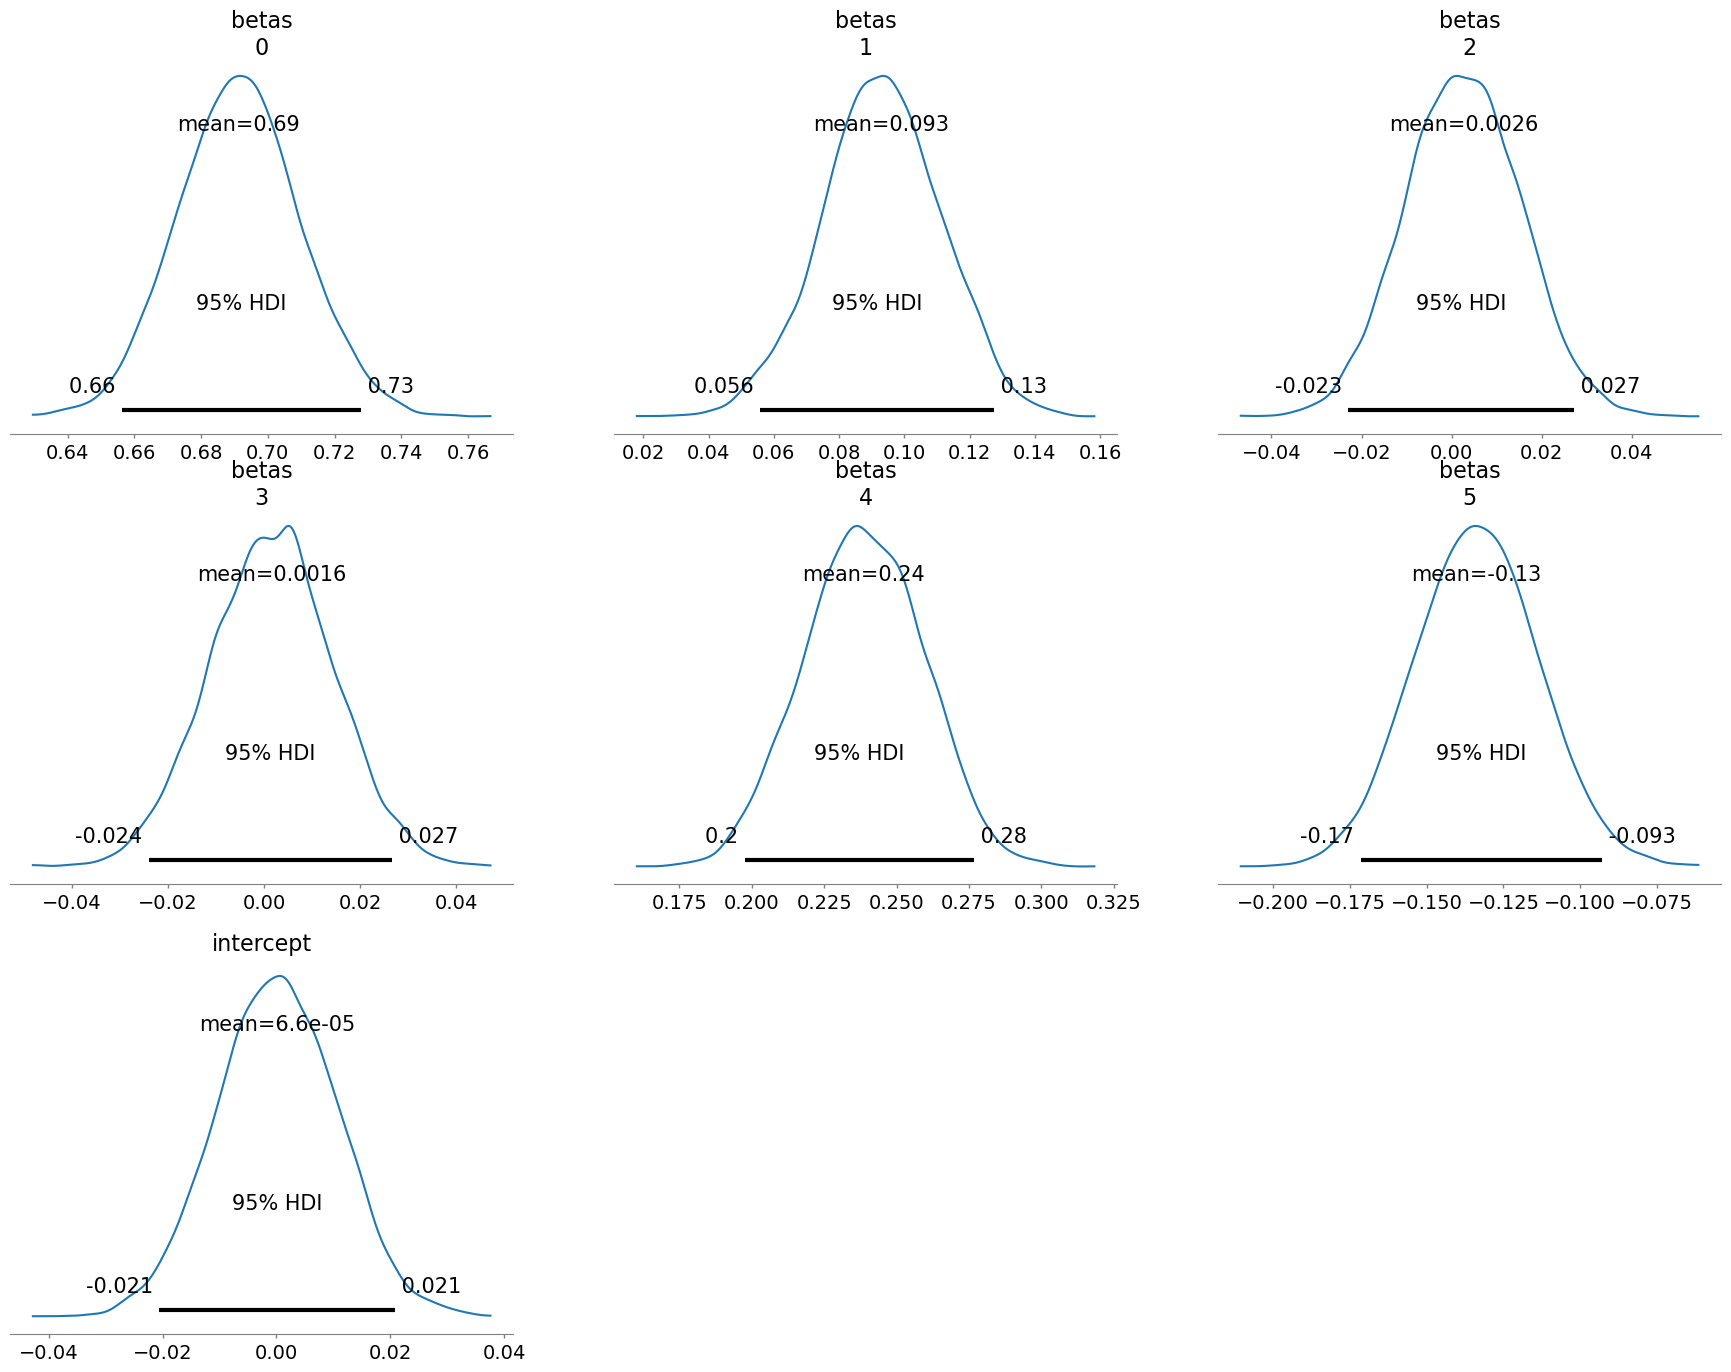

Sampling: [y_obs]


Output()

Posterior Samples Shape: (4, 2000, 2896)
Train positions shape: 2311
Test positions shape: 585
Filtered Observed train shape: (2311,)
Filtered Predicted train shape: (2311,)
Filtered Observed test shape: (585,)
Filtered Predicted test shape: (585,)
Train RMSE: 1.3099
Test RMSE: 1.2504
Train MAE: 1.0283
Test MAE: 0.9628


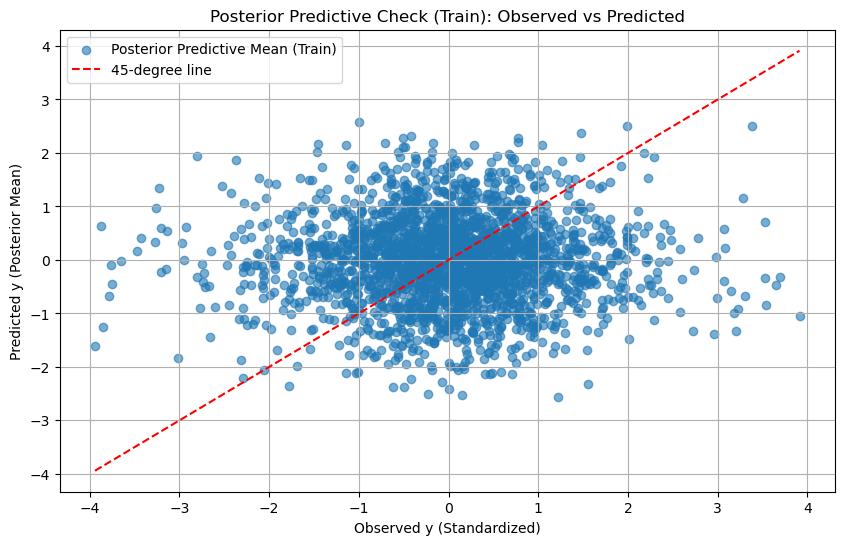

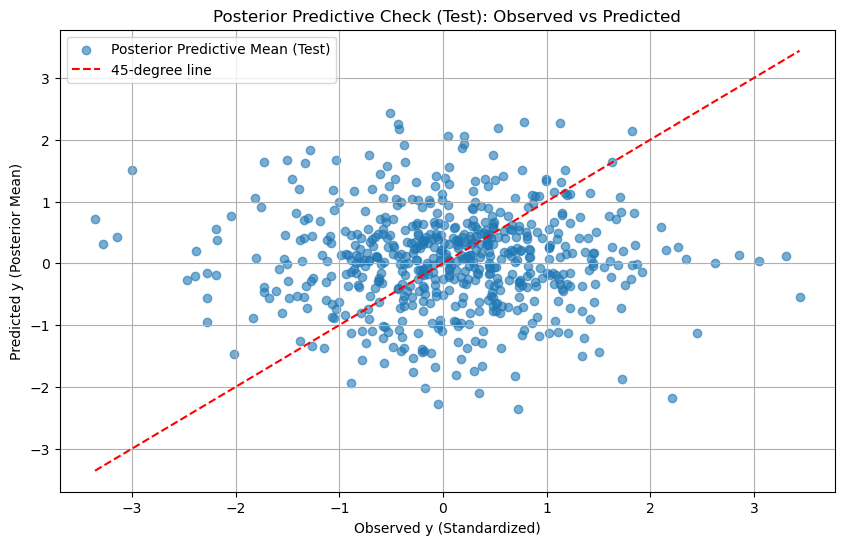

In [35]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Significant predictors identified from the analysis
refined_predictors = ['spf_return', 'jpm_return', 'FEDL01', 'CPI', 'bac_20d_ma_dev', 'bac_rsi']

# Prepare predictors and target
X_refined = log_scaled_market[refined_predictors].dropna()
y_refined = log_scaled_market['bac_return'].loc[X_refined.index]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_refined, y_refined, test_size=0.2, random_state=42
)

# Standardize predictors and target
X_train_standardized = (X_train - X_train.mean()) / X_train.std()
X_test_standardized = (X_test - X_train.mean()) / X_train.std()  # Use train stats for test set
y_train_standardized = (y_train - y_train.mean()) / y_train.std()
y_test_standardized = (y_test - y_train.mean()) / y_train.std()  # Use train stats for test set

# Bayesian regression model with domain-informed priors
with pm.Model() as bayesian_model:
    # Priors for coefficients with domain knowledge
    betas = pm.Normal("betas", mu=0, sigma=1, shape=len(refined_predictors))  # Priors for all predictors
    intercept = pm.Normal("intercept", mu=0, sigma=1)  # Prior for intercept
    sigma = pm.HalfNormal("sigma", sigma=1)  # Prior for noise standard deviation

    # Linear regression
    mu = intercept + pm.math.dot(X_train_standardized, betas)

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_train_standardized)

    # MCMC sampling
    trace = pm.sample(2000, tune=1000, cores=4, chains=4, return_inferencedata=True)

# Summarize posterior distributions
summary = az.summary(trace, hdi_prob=0.95)
print(summary)

# Plot posterior distributions
az.plot_posterior(trace, var_names=["betas", "intercept"], hdi_prob=0.95)
plt.show()

# Posterior predictive checks
with bayesian_model:
    posterior_predictive = pm.sample_posterior_predictive(trace)

# Posterior predictive samples
posterior_samples = posterior_predictive.posterior_predictive["y_obs"].values
print("Posterior Samples Shape:", posterior_samples.shape)

# Match train and test indices to positions within bounds
train_positions = [i for i, idx in enumerate(X_refined.index) if idx in y_train.index and i < posterior_samples.shape[2]]
test_positions = [i for i, idx in enumerate(X_refined.index) if idx in y_test.index and i < posterior_samples.shape[2]]

print("Train positions shape:", len(train_positions))
print("Test positions shape:", len(test_positions))

# Ensure predictions are correctly indexed
predicted_train = posterior_samples[:, :, train_positions].mean(axis=(0, 1))
predicted_test = posterior_samples[:, :, test_positions].mean(axis=(0, 1))

# Ensure indices are properly aligned to the original dataset
train_indices = X_refined.index[train_positions]
test_indices = X_refined.index[test_positions]

# Filter observed values to match valid positions
observed_train = y_train_standardized.loc[train_indices].values
observed_test = y_test_standardized.loc[test_indices].values

# Debugging outputs for alignment
print("Filtered Observed train shape:", observed_train.shape)
print("Filtered Predicted train shape:", predicted_train.shape)
print("Filtered Observed test shape:", observed_test.shape)
print("Filtered Predicted test shape:", predicted_test.shape)

# ---- Evaluation Metrics ---- #

# Train RMSE
rmse_train = np.sqrt(np.mean((observed_train - predicted_train) ** 2))
print(f"Train RMSE: {rmse_train:.4f}")

# Test RMSE
rmse_test = np.sqrt(np.mean((observed_test - predicted_test) ** 2))
print(f"Test RMSE: {rmse_test:.4f}")

# Train Mean Absolute Error (MAE)
mae_train = np.mean(np.abs(observed_train - predicted_train))
print(f"Train MAE: {mae_train:.4f}")

# Test Mean Absolute Error (MAE)
mae_test = np.mean(np.abs(observed_test - predicted_test))
print(f"Test MAE: {mae_test:.4f}")

# ---- Plots ---- #

# Average Observed vs. Predicted (Train)
plt.figure(figsize=(10, 6))
plt.scatter(observed_train, predicted_train, alpha=0.6, label="Posterior Predictive Mean (Train)")
plt.plot([min(observed_train), max(observed_train)], [min(observed_train), max(observed_train)], 'r--', label="45-degree line")
plt.title("Posterior Predictive Check (Train): Observed vs Predicted")
plt.xlabel("Observed y (Standardized)")
plt.ylabel("Predicted y (Posterior Mean)")
plt.legend()
plt.grid(True)
plt.show()

# Average Observed vs. Predicted (Test)
plt.figure(figsize=(10, 6))
plt.scatter(observed_test, predicted_test, alpha=0.6, label="Posterior Predictive Mean (Test)")
plt.plot([min(observed_test), max(observed_test)], [min(observed_test), max(observed_test)], 'r--', label="45-degree line")
plt.title("Posterior Predictive Check (Test): Observed vs Predicted")
plt.xlabel("Observed y (Standardized)")
plt.ylabel("Predicted y (Posterior Mean)")
plt.legend()
plt.grid(True)
plt.show()

## Citi Analysis

#### Model with Economic Indicators: Citi

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas, intercept, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 22 seconds.


            mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
betas[0]   0.013  0.019    -0.024      0.048        0.0      0.0    8555.0   
betas[1]   0.009  0.022    -0.035      0.053        0.0      0.0    7120.0   
betas[2]   0.020  0.025    -0.028      0.071        0.0      0.0    6474.0   
betas[3]  -0.004  0.022    -0.046      0.039        0.0      0.0    8273.0   
intercept -0.000  0.019    -0.037      0.036        0.0      0.0    9425.0   
sigma      1.000  0.013     0.974      1.026        0.0      0.0    9268.0   

           ess_tail  r_hat  
betas[0]     6229.0    1.0  
betas[1]     6302.0    1.0  
betas[2]     6101.0    1.0  
betas[3]     6794.0    1.0  
intercept    6399.0    1.0  
sigma        5901.0    1.0  


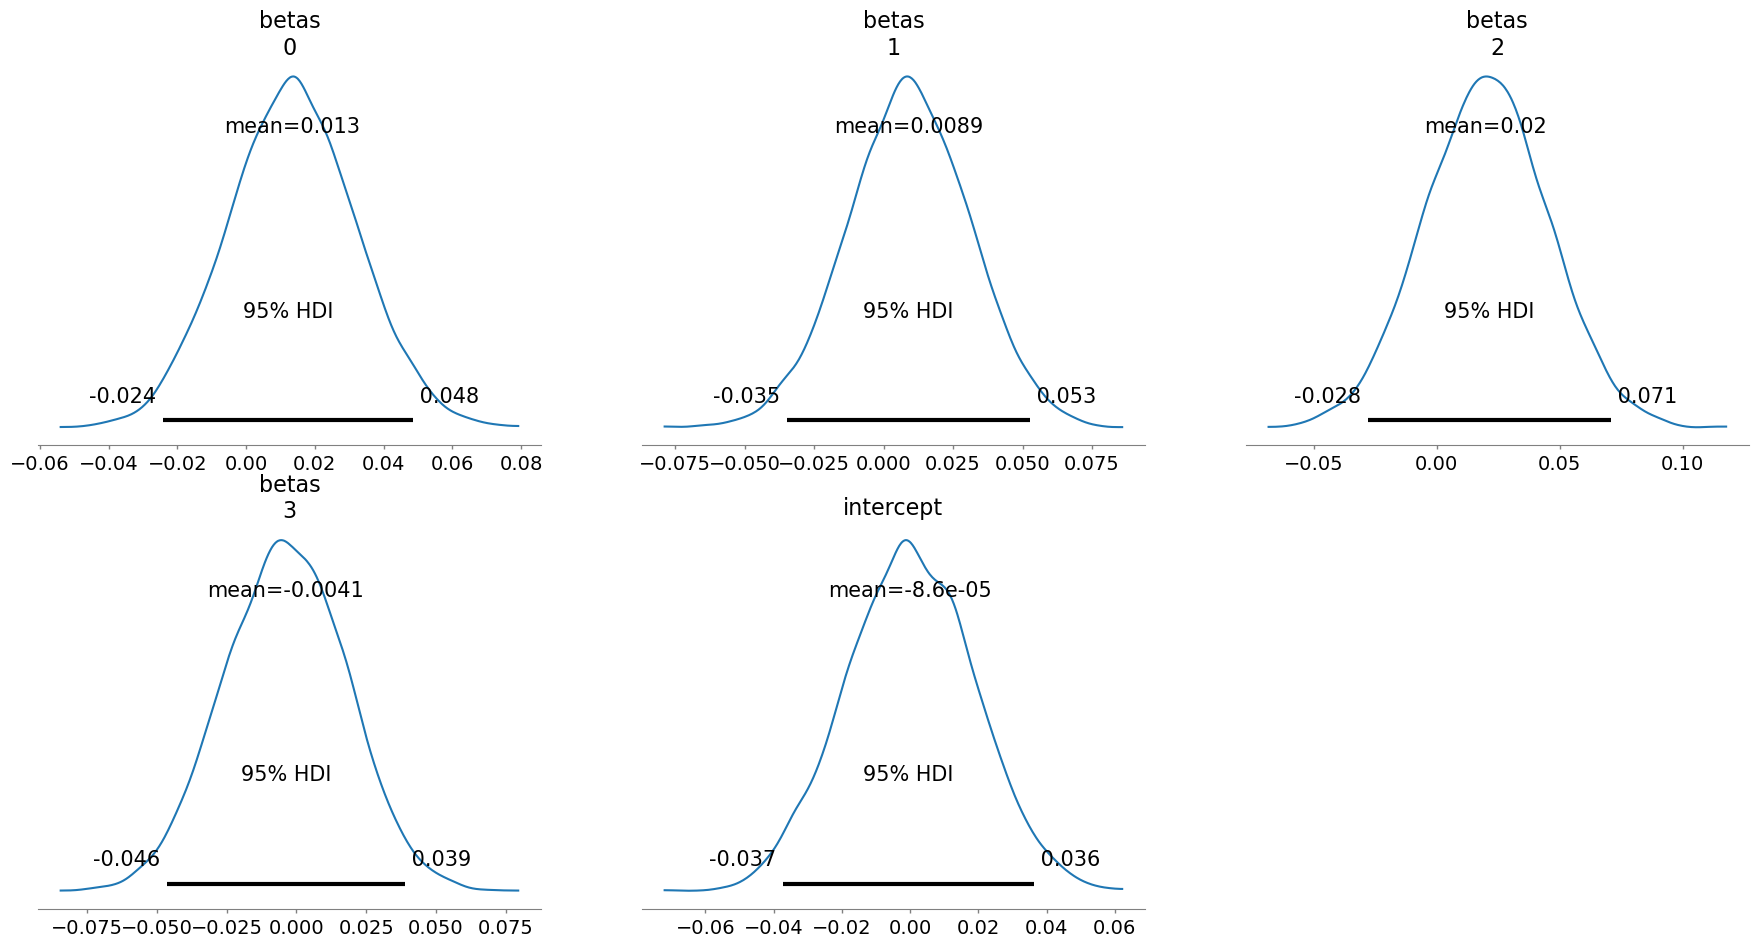

Sampling: [y_obs]


Output()

Posterior Samples Shape: (4, 2000, 2896)
Train positions shape: 2311
Test positions shape: 585
Filtered Observed train shape: (2311,)
Filtered Predicted train shape: (2311,)
Filtered Observed test shape: (585,)
Filtered Predicted test shape: (585,)
Train RMSE: 1.0260
Test RMSE: 0.9848
Train MAE: 0.7844
Test MAE: 0.7699


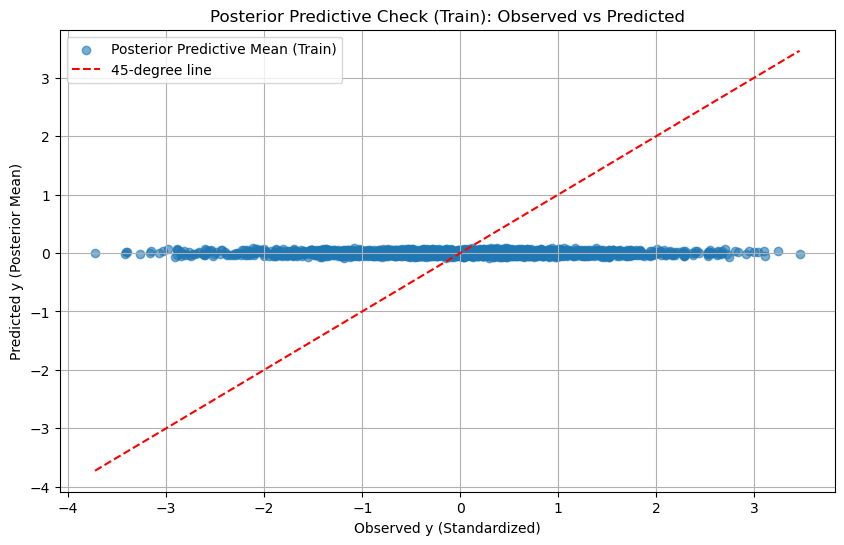

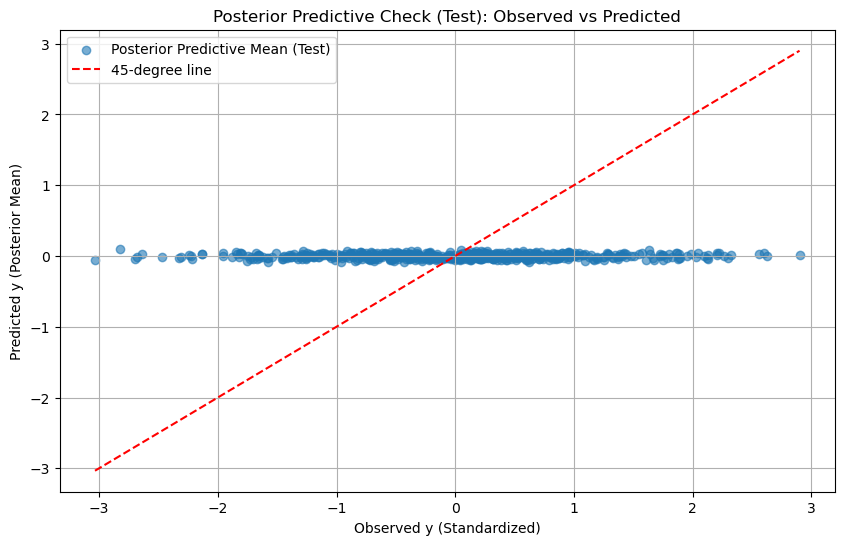

In [38]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Significant predictors identified from the analysis
refined_predictors = ['GDP', 'CPI', 'FEDL01', 'UE']

# Prepare predictors and target
X_refined = log_scaled_market[refined_predictors].dropna()
y_refined = log_scaled_market['citi_return'].loc[X_refined.index]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_refined, y_refined, test_size=0.2, random_state=42
)

# Standardize predictors and target
X_train_standardized = (X_train - X_train.mean()) / X_train.std()
X_test_standardized = (X_test - X_train.mean()) / X_train.std()  # Use train stats for test set
y_train_standardized = (y_train - y_train.mean()) / y_train.std()
y_test_standardized = (y_test - y_train.mean()) / y_train.std()  # Use train stats for test set

# Bayesian regression model with domain-informed priors
with pm.Model() as bayesian_model:
    # Priors for coefficients with domain knowledge
    betas = pm.Normal("betas", mu=0, sigma=1, shape=len(refined_predictors))  # Priors for all predictors
    intercept = pm.Normal("intercept", mu=0, sigma=1)  # Prior for intercept
    sigma = pm.HalfNormal("sigma", sigma=1)  # Prior for noise standard deviation

    # Linear regression
    mu = intercept + pm.math.dot(X_train_standardized, betas)

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_train_standardized)

    # MCMC sampling
    trace = pm.sample(2000, tune=1000, cores=4, chains=4, return_inferencedata=True)

# Summarize posterior distributions
summary = az.summary(trace, hdi_prob=0.95)
print(summary)

# Plot posterior distributions
az.plot_posterior(trace, var_names=["betas", "intercept"], hdi_prob=0.95)
plt.show()

# Posterior predictive checks
with bayesian_model:
    posterior_predictive = pm.sample_posterior_predictive(trace)

# Posterior predictive samples
posterior_samples = posterior_predictive.posterior_predictive["y_obs"].values
print("Posterior Samples Shape:", posterior_samples.shape)

# Match train and test indices to positions within bounds
train_positions = [i for i, idx in enumerate(X_refined.index) if idx in y_train.index and i < posterior_samples.shape[2]]
test_positions = [i for i, idx in enumerate(X_refined.index) if idx in y_test.index and i < posterior_samples.shape[2]]

print("Train positions shape:", len(train_positions))
print("Test positions shape:", len(test_positions))

# Ensure predictions are correctly indexed
predicted_train = posterior_samples[:, :, train_positions].mean(axis=(0, 1))
predicted_test = posterior_samples[:, :, test_positions].mean(axis=(0, 1))

# Ensure indices are properly aligned to the original dataset
train_indices = X_refined.index[train_positions]
test_indices = X_refined.index[test_positions]

# Filter observed values to match valid positions
observed_train = y_train_standardized.loc[train_indices].values
observed_test = y_test_standardized.loc[test_indices].values

# Debugging outputs for alignment
print("Filtered Observed train shape:", observed_train.shape)
print("Filtered Predicted train shape:", predicted_train.shape)
print("Filtered Observed test shape:", observed_test.shape)
print("Filtered Predicted test shape:", predicted_test.shape)

# ---- Evaluation Metrics ---- #

# Train RMSE
rmse_train = np.sqrt(np.mean((observed_train - predicted_train) ** 2))
print(f"Train RMSE: {rmse_train:.4f}")

# Test RMSE
rmse_test = np.sqrt(np.mean((observed_test - predicted_test) ** 2))
print(f"Test RMSE: {rmse_test:.4f}")

# Train Mean Absolute Error (MAE)
mae_train = np.mean(np.abs(observed_train - predicted_train))
print(f"Train MAE: {mae_train:.4f}")

# Test Mean Absolute Error (MAE)
mae_test = np.mean(np.abs(observed_test - predicted_test))
print(f"Test MAE: {mae_test:.4f}")

# ---- Plots ---- #

# Average Observed vs. Predicted (Train)
plt.figure(figsize=(10, 6))
plt.scatter(observed_train, predicted_train, alpha=0.6, label="Posterior Predictive Mean (Train)")
plt.plot([min(observed_train), max(observed_train)], [min(observed_train), max(observed_train)], 'r--', label="45-degree line")
plt.title("Posterior Predictive Check (Train): Observed vs Predicted")
plt.xlabel("Observed y (Standardized)")
plt.ylabel("Predicted y (Posterior Mean)")
plt.legend()
plt.grid(True)
plt.show()

# Average Observed vs. Predicted (Test)
plt.figure(figsize=(10, 6))
plt.scatter(observed_test, predicted_test, alpha=0.6, label="Posterior Predictive Mean (Test)")
plt.plot([min(observed_test), max(observed_test)], [min(observed_test), max(observed_test)], 'r--', label="45-degree line")
plt.title("Posterior Predictive Check (Test): Observed vs Predicted")
plt.xlabel("Observed y (Standardized)")
plt.ylabel("Predicted y (Posterior Mean)")
plt.legend()
plt.grid(True)
plt.show()

#### Model with Technical Indicators: Citi

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas, intercept, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 26 seconds.


            mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
betas[0]   0.502  0.032     0.438      0.565        0.0      0.0    5395.0   
betas[1]  -0.265  0.032    -0.327     -0.202        0.0      0.0    5205.0   
intercept  0.000  0.018    -0.034      0.035        0.0      0.0    7908.0   
sigma      0.950  0.013     0.926      0.975        0.0      0.0    7468.0   

           ess_tail  r_hat  
betas[0]     4749.0    1.0  
betas[1]     4854.0    1.0  
intercept    5464.0    1.0  
sigma        5317.0    1.0  


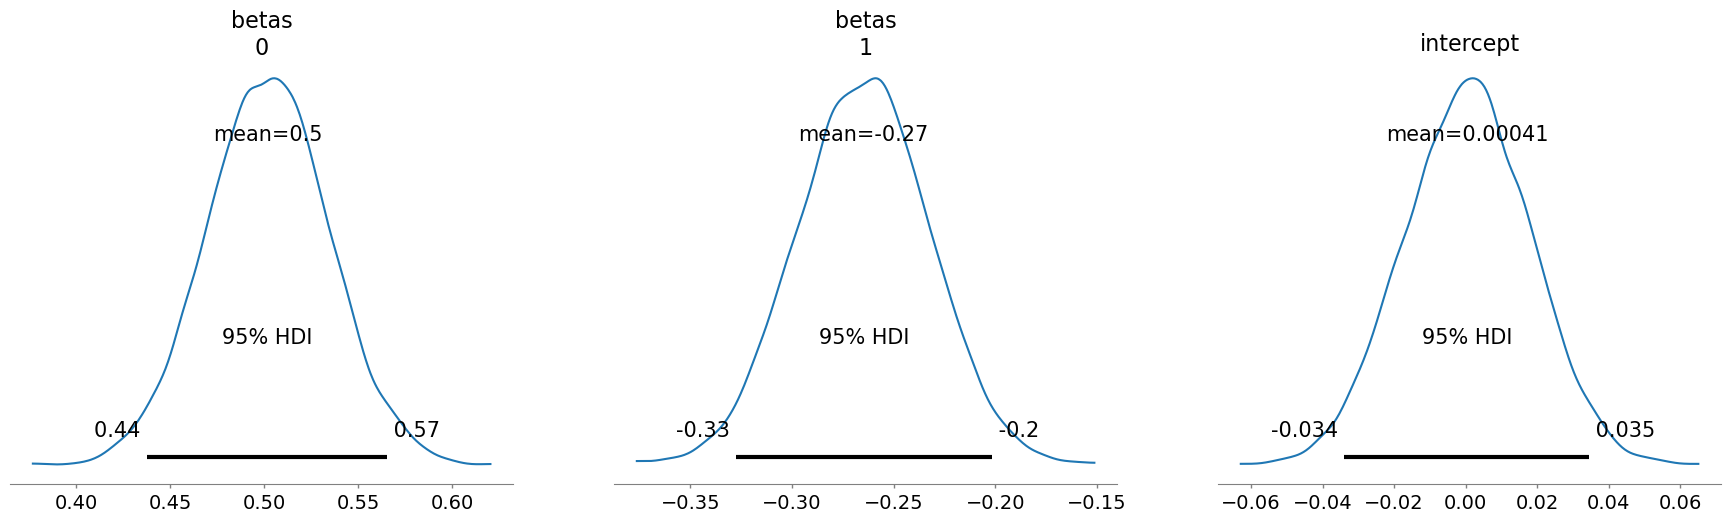

Sampling: [y_obs]


Output()

Posterior Samples Shape: (4, 2000, 2896)
Train positions shape: 2311
Test positions shape: 585
Filtered Observed train shape: (2311,)
Filtered Predicted train shape: (2311,)
Filtered Observed test shape: (585,)
Filtered Predicted test shape: (585,)
Train RMSE: 1.0691
Test RMSE: 1.0386
Train MAE: 0.8221
Test MAE: 0.8032


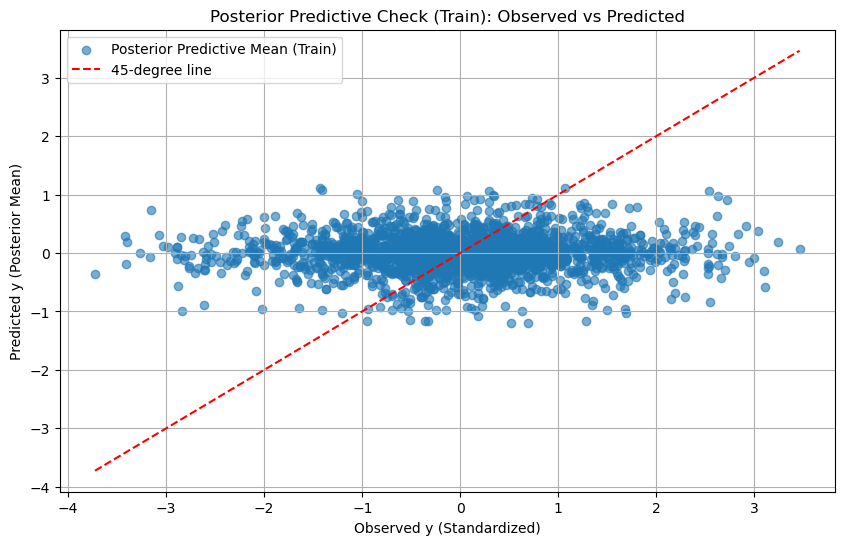

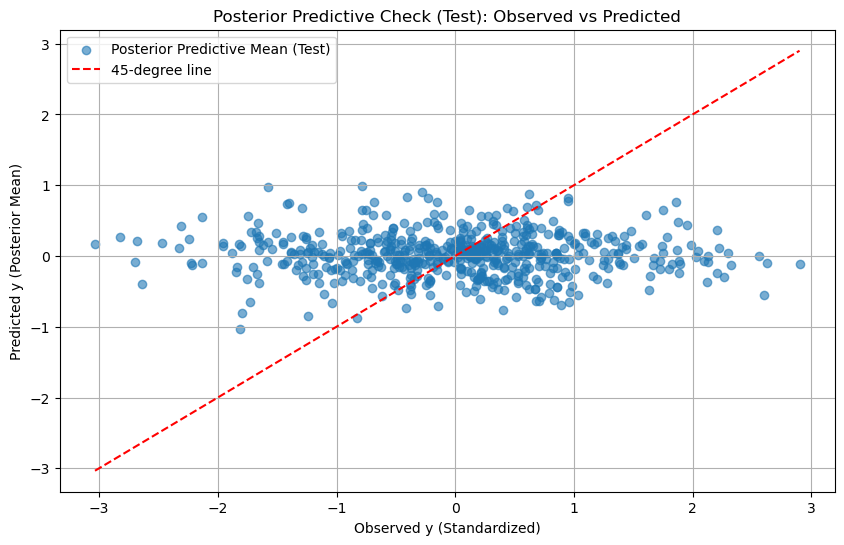

In [39]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Significant predictors identified from the analysis
refined_predictors = ['citi_20d_ma_dev', 'citi_rsi']

# Prepare predictors and target
X_refined = log_scaled_market[refined_predictors].dropna()
y_refined = log_scaled_market['citi_return'].loc[X_refined.index]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_refined, y_refined, test_size=0.2, random_state=42
)

# Standardize predictors and target
X_train_standardized = (X_train - X_train.mean()) / X_train.std()
X_test_standardized = (X_test - X_train.mean()) / X_train.std()  # Use train stats for test set
y_train_standardized = (y_train - y_train.mean()) / y_train.std()
y_test_standardized = (y_test - y_train.mean()) / y_train.std()  # Use train stats for test set

# Bayesian regression model with domain-informed priors
with pm.Model() as bayesian_model:
    # Priors for coefficients with domain knowledge
    betas = pm.Normal("betas", mu=0, sigma=1, shape=len(refined_predictors))  # Priors for all predictors
    intercept = pm.Normal("intercept", mu=0, sigma=1)  # Prior for intercept
    sigma = pm.HalfNormal("sigma", sigma=1)  # Prior for noise standard deviation

    # Linear regression
    mu = intercept + pm.math.dot(X_train_standardized, betas)

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_train_standardized)

    # MCMC sampling
    trace = pm.sample(2000, tune=1000, cores=4, chains=4, return_inferencedata=True)

# Summarize posterior distributions
summary = az.summary(trace, hdi_prob=0.95)
print(summary)

# Plot posterior distributions
az.plot_posterior(trace, var_names=["betas", "intercept"], hdi_prob=0.95)
plt.show()

# Posterior predictive checks
with bayesian_model:
    posterior_predictive = pm.sample_posterior_predictive(trace)

# Posterior predictive samples
posterior_samples = posterior_predictive.posterior_predictive["y_obs"].values
print("Posterior Samples Shape:", posterior_samples.shape)

# Match train and test indices to positions within bounds
train_positions = [i for i, idx in enumerate(X_refined.index) if idx in y_train.index and i < posterior_samples.shape[2]]
test_positions = [i for i, idx in enumerate(X_refined.index) if idx in y_test.index and i < posterior_samples.shape[2]]

print("Train positions shape:", len(train_positions))
print("Test positions shape:", len(test_positions))

# Ensure predictions are correctly indexed
predicted_train = posterior_samples[:, :, train_positions].mean(axis=(0, 1))
predicted_test = posterior_samples[:, :, test_positions].mean(axis=(0, 1))

# Ensure indices are properly aligned to the original dataset
train_indices = X_refined.index[train_positions]
test_indices = X_refined.index[test_positions]

# Filter observed values to match valid positions
observed_train = y_train_standardized.loc[train_indices].values
observed_test = y_test_standardized.loc[test_indices].values

# Debugging outputs for alignment
print("Filtered Observed train shape:", observed_train.shape)
print("Filtered Predicted train shape:", predicted_train.shape)
print("Filtered Observed test shape:", observed_test.shape)
print("Filtered Predicted test shape:", predicted_test.shape)

# ---- Evaluation Metrics ---- #

# Train RMSE
rmse_train = np.sqrt(np.mean((observed_train - predicted_train) ** 2))
print(f"Train RMSE: {rmse_train:.4f}")

# Test RMSE
rmse_test = np.sqrt(np.mean((observed_test - predicted_test) ** 2))
print(f"Test RMSE: {rmse_test:.4f}")

# Train Mean Absolute Error (MAE)
mae_train = np.mean(np.abs(observed_train - predicted_train))
print(f"Train MAE: {mae_train:.4f}")

# Test Mean Absolute Error (MAE)
mae_test = np.mean(np.abs(observed_test - predicted_test))
print(f"Test MAE: {mae_test:.4f}")

# ---- Plots ---- #

# Average Observed vs. Predicted (Train)
plt.figure(figsize=(10, 6))
plt.scatter(observed_train, predicted_train, alpha=0.6, label="Posterior Predictive Mean (Train)")
plt.plot([min(observed_train), max(observed_train)], [min(observed_train), max(observed_train)], 'r--', label="45-degree line")
plt.title("Posterior Predictive Check (Train): Observed vs Predicted")
plt.xlabel("Observed y (Standardized)")
plt.ylabel("Predicted y (Posterior Mean)")
plt.legend()
plt.grid(True)
plt.show()

# Average Observed vs. Predicted (Test)
plt.figure(figsize=(10, 6))
plt.scatter(observed_test, predicted_test, alpha=0.6, label="Posterior Predictive Mean (Test)")
plt.plot([min(observed_test), max(observed_test)], [min(observed_test), max(observed_test)], 'r--', label="45-degree line")
plt.title("Posterior Predictive Check (Test): Observed vs Predicted")
plt.xlabel("Observed y (Standardized)")
plt.ylabel("Predicted y (Posterior Mean)")
plt.legend()
plt.grid(True)
plt.show()

#### Model with Returns: Citi

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas, intercept, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 25 seconds.


            mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
betas[0]   0.046  0.019     0.009      0.085        0.0      0.0    6001.0   
betas[1]   0.087  0.019     0.051      0.123        0.0      0.0    7155.0   
betas[2]   0.605  0.027     0.551      0.656        0.0      0.0    4522.0   
betas[3]   0.115  0.017     0.081      0.148        0.0      0.0    6823.0   
intercept -0.000  0.011    -0.021      0.022        0.0      0.0    8510.0   
sigma      0.593  0.008     0.578      0.609        0.0      0.0    9167.0   

           ess_tail  r_hat  
betas[0]     5438.0    1.0  
betas[1]     6082.0    1.0  
betas[2]     4981.0    1.0  
betas[3]     5917.0    1.0  
intercept    5864.0    1.0  
sigma        5684.0    1.0  


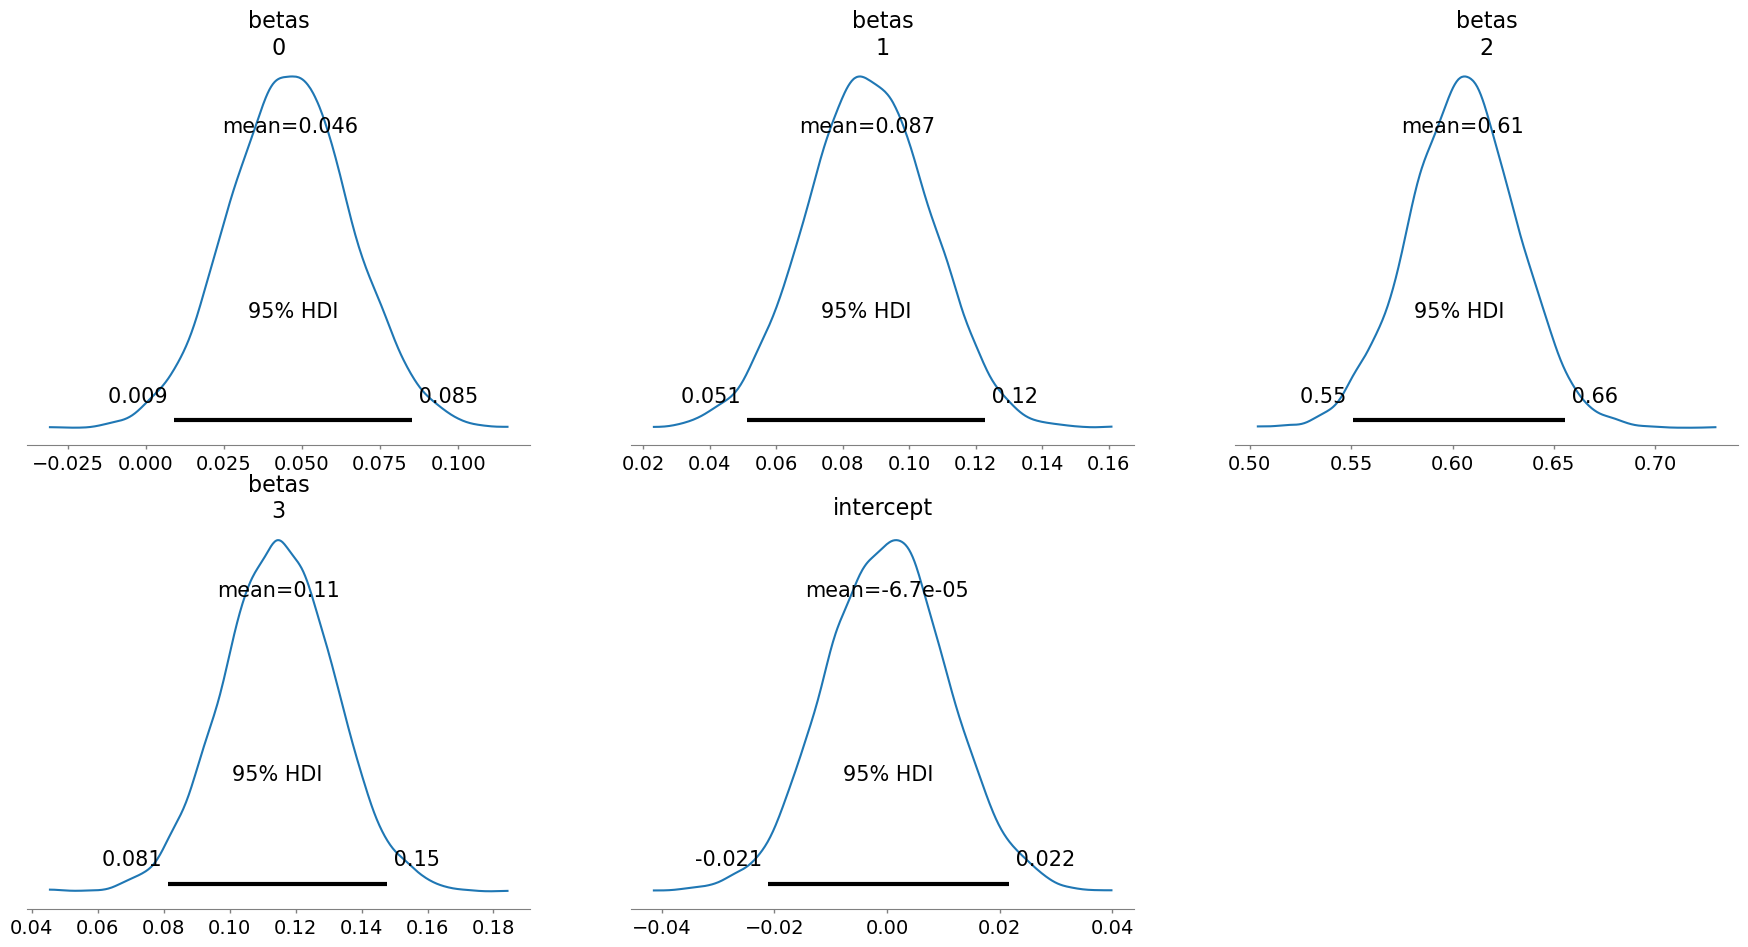

Sampling: [y_obs]


Output()

Posterior Samples Shape: (4, 2000, 2896)
Train positions shape: 2311
Test positions shape: 585
Filtered Observed train shape: (2311,)
Filtered Predicted train shape: (2311,)
Filtered Observed test shape: (585,)
Filtered Predicted test shape: (585,)
Train RMSE: 1.3085
Test RMSE: 1.2389
Train MAE: 1.0277
Test MAE: 0.9787


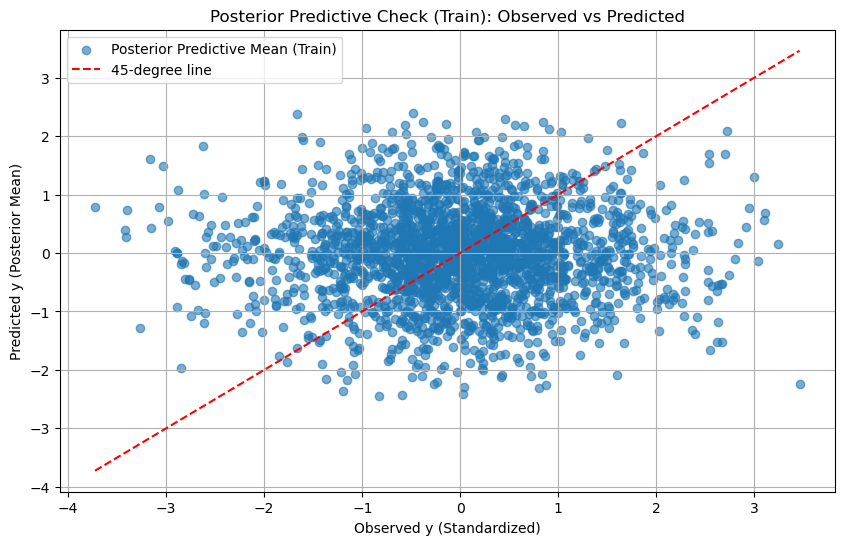

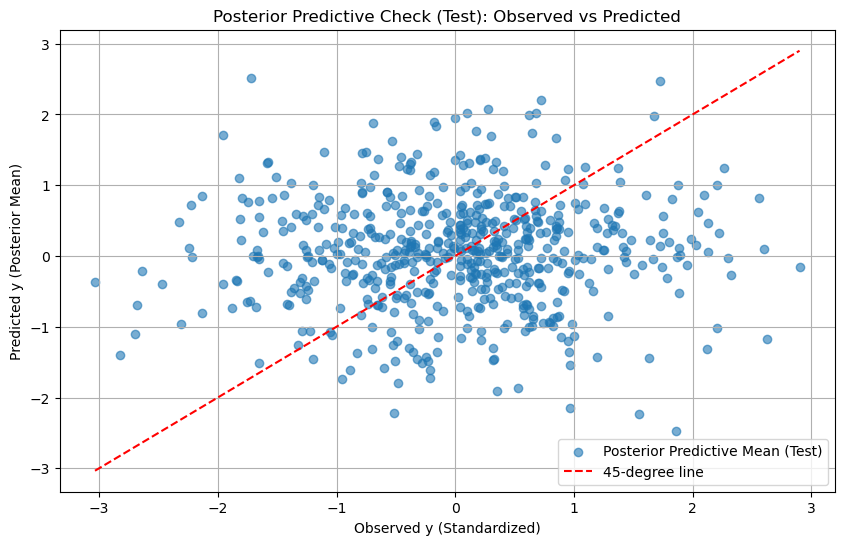

In [40]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Significant predictors identified from the analysis
refined_predictors = ['jpm_return', 'bac_return', 'spf_return', 'ms_return']

# Prepare predictors and target
X_refined = log_scaled_market[refined_predictors].dropna()
y_refined = log_scaled_market['citi_return'].loc[X_refined.index]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_refined, y_refined, test_size=0.2, random_state=42
)

# Standardize predictors and target
X_train_standardized = (X_train - X_train.mean()) / X_train.std()
X_test_standardized = (X_test - X_train.mean()) / X_train.std()  # Use train stats for test set
y_train_standardized = (y_train - y_train.mean()) / y_train.std()
y_test_standardized = (y_test - y_train.mean()) / y_train.std()  # Use train stats for test set

# Bayesian regression model with domain-informed priors
with pm.Model() as bayesian_model:
    # Priors for coefficients with domain knowledge
    betas = pm.Normal("betas", mu=0, sigma=1, shape=len(refined_predictors))  # Priors for all predictors
    intercept = pm.Normal("intercept", mu=0, sigma=1)  # Prior for intercept
    sigma = pm.HalfNormal("sigma", sigma=1)  # Prior for noise standard deviation

    # Linear regression
    mu = intercept + pm.math.dot(X_train_standardized, betas)

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_train_standardized)

    # MCMC sampling
    trace = pm.sample(2000, tune=1000, cores=4, chains=4, return_inferencedata=True)

# Summarize posterior distributions
summary = az.summary(trace, hdi_prob=0.95)
print(summary)

# Plot posterior distributions
az.plot_posterior(trace, var_names=["betas", "intercept"], hdi_prob=0.95)
plt.show()

# Posterior predictive checks
with bayesian_model:
    posterior_predictive = pm.sample_posterior_predictive(trace)

# Posterior predictive samples
posterior_samples = posterior_predictive.posterior_predictive["y_obs"].values
print("Posterior Samples Shape:", posterior_samples.shape)

# Match train and test indices to positions within bounds
train_positions = [i for i, idx in enumerate(X_refined.index) if idx in y_train.index and i < posterior_samples.shape[2]]
test_positions = [i for i, idx in enumerate(X_refined.index) if idx in y_test.index and i < posterior_samples.shape[2]]

print("Train positions shape:", len(train_positions))
print("Test positions shape:", len(test_positions))

# Ensure predictions are correctly indexed
predicted_train = posterior_samples[:, :, train_positions].mean(axis=(0, 1))
predicted_test = posterior_samples[:, :, test_positions].mean(axis=(0, 1))

# Ensure indices are properly aligned to the original dataset
train_indices = X_refined.index[train_positions]
test_indices = X_refined.index[test_positions]

# Filter observed values to match valid positions
observed_train = y_train_standardized.loc[train_indices].values
observed_test = y_test_standardized.loc[test_indices].values

# Debugging outputs for alignment
print("Filtered Observed train shape:", observed_train.shape)
print("Filtered Predicted train shape:", predicted_train.shape)
print("Filtered Observed test shape:", observed_test.shape)
print("Filtered Predicted test shape:", predicted_test.shape)

# ---- Evaluation Metrics ---- #

# Train RMSE
rmse_train = np.sqrt(np.mean((observed_train - predicted_train) ** 2))
print(f"Train RMSE: {rmse_train:.4f}")

# Test RMSE
rmse_test = np.sqrt(np.mean((observed_test - predicted_test) ** 2))
print(f"Test RMSE: {rmse_test:.4f}")

# Train Mean Absolute Error (MAE)
mae_train = np.mean(np.abs(observed_train - predicted_train))
print(f"Train MAE: {mae_train:.4f}")

# Test Mean Absolute Error (MAE)
mae_test = np.mean(np.abs(observed_test - predicted_test))
print(f"Test MAE: {mae_test:.4f}")

# ---- Plots ---- #

# Average Observed vs. Predicted (Train)
plt.figure(figsize=(10, 6))
plt.scatter(observed_train, predicted_train, alpha=0.6, label="Posterior Predictive Mean (Train)")
plt.plot([min(observed_train), max(observed_train)], [min(observed_train), max(observed_train)], 'r--', label="45-degree line")
plt.title("Posterior Predictive Check (Train): Observed vs Predicted")
plt.xlabel("Observed y (Standardized)")
plt.ylabel("Predicted y (Posterior Mean)")
plt.legend()
plt.grid(True)
plt.show()

# Average Observed vs. Predicted (Test)
plt.figure(figsize=(10, 6))
plt.scatter(observed_test, predicted_test, alpha=0.6, label="Posterior Predictive Mean (Test)")
plt.plot([min(observed_test), max(observed_test)], [min(observed_test), max(observed_test)], 'r--', label="45-degree line")
plt.title("Posterior Predictive Check (Test): Observed vs Predicted")
plt.xlabel("Observed y (Standardized)")
plt.ylabel("Predicted y (Posterior Mean)")
plt.legend()
plt.grid(True)
plt.show()

#### Model with Mixed Variables Only: Citi

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas, intercept, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 27 seconds.


            mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
betas[0]   0.723  0.018     0.687      0.758        0.0      0.0    7241.0   
betas[1]   0.054  0.018     0.017      0.089        0.0      0.0    6828.0   
betas[2]   0.035  0.013     0.010      0.061        0.0      0.0    7073.0   
betas[3]  -0.016  0.013    -0.042      0.009        0.0      0.0    7367.0   
betas[4]   0.223  0.020     0.183      0.262        0.0      0.0    5172.0   
betas[5]  -0.112  0.020    -0.151     -0.073        0.0      0.0    5325.0   
intercept -0.000  0.011    -0.022      0.021        0.0      0.0   10497.0   
sigma      0.584  0.008     0.570      0.599        0.0      0.0   10020.0   

           ess_tail  r_hat  
betas[0]     6385.0    1.0  
betas[1]     6651.0    1.0  
betas[2]     5972.0    1.0  
betas[3]     5842.0    1.0  
betas[4]     5332.0    1.0  
betas[5]     5439.0    1.0  
intercept    5917.0    1.0  
sigma        5832.0    1.0  


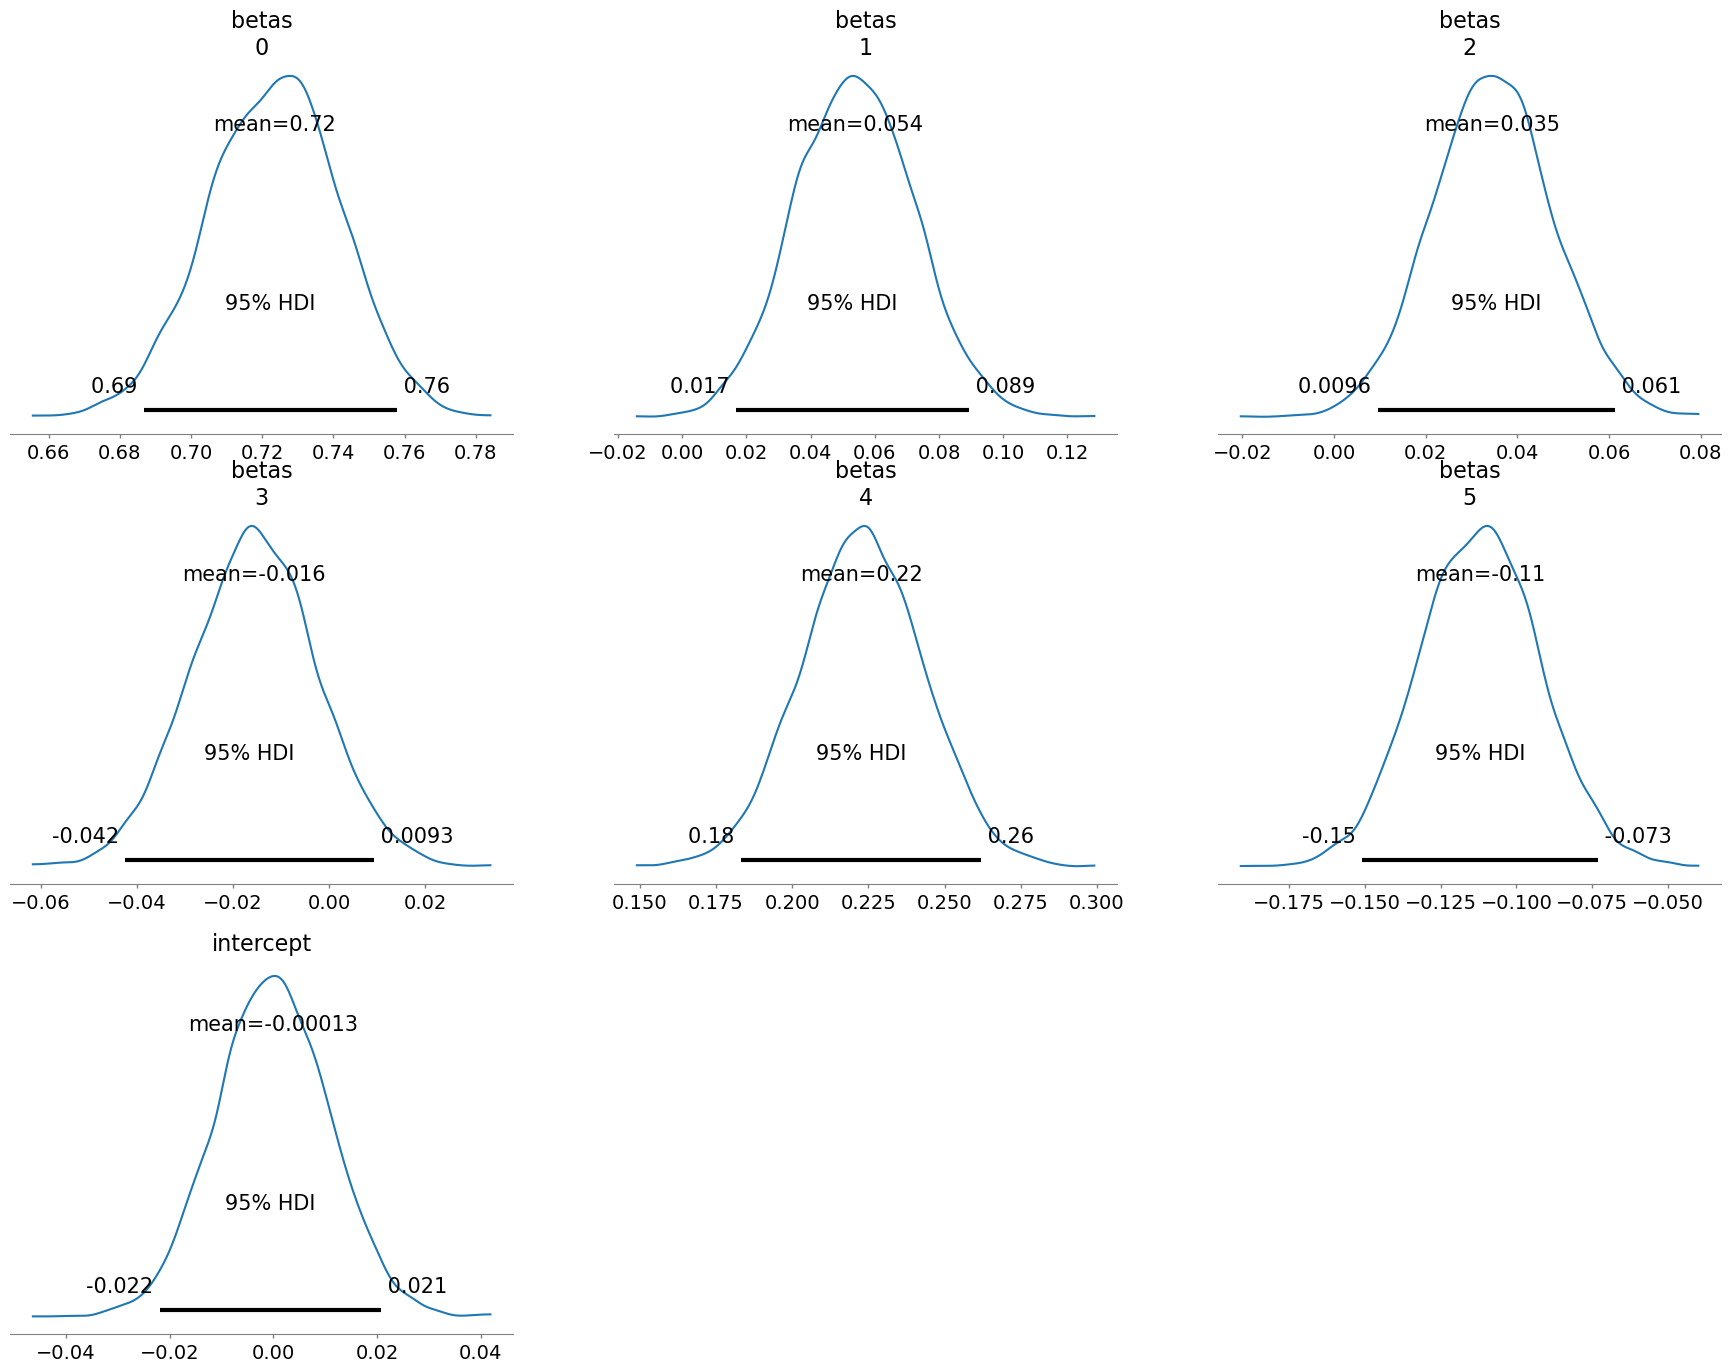

Sampling: [y_obs]


Output()

Posterior Samples Shape: (4, 2000, 2896)
Train positions shape: 2311
Test positions shape: 585
Filtered Observed train shape: (2311,)
Filtered Predicted train shape: (2311,)
Filtered Observed test shape: (585,)
Filtered Predicted test shape: (585,)
Train RMSE: 1.3120
Test RMSE: 1.2447
Train MAE: 1.0318
Test MAE: 0.9781


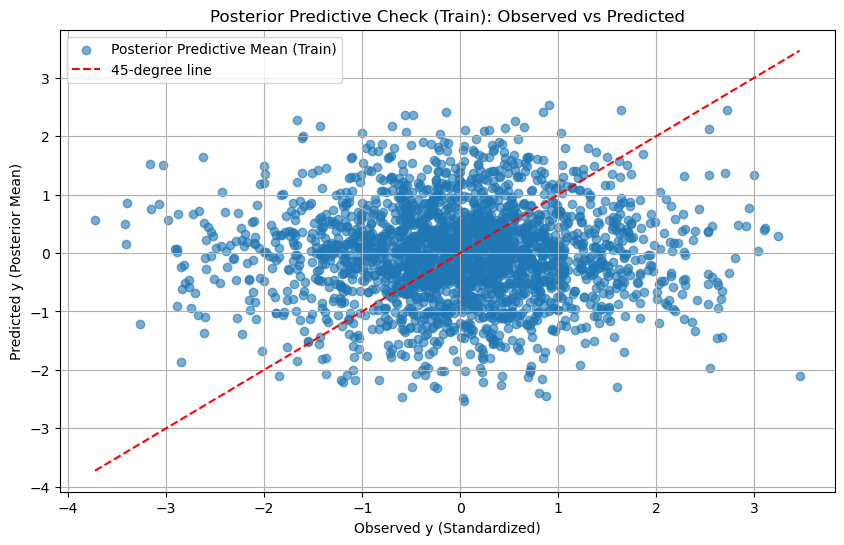

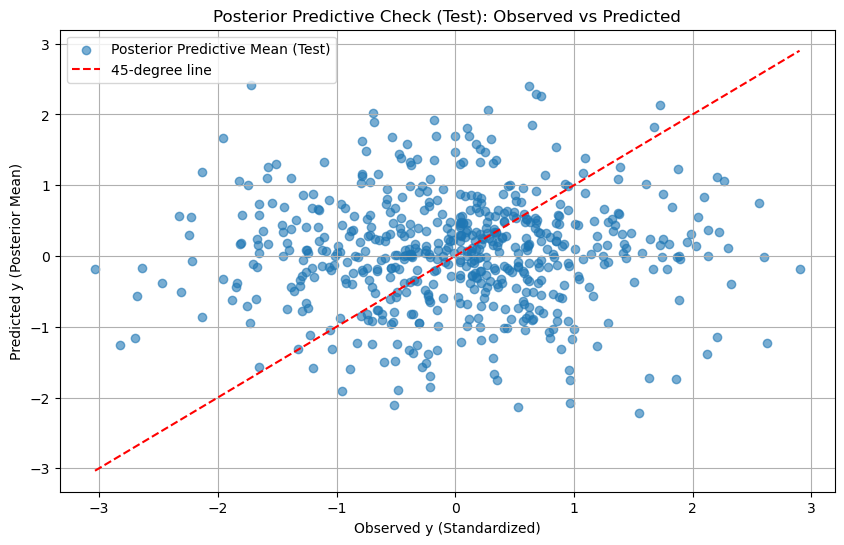

In [41]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Significant predictors identified from the analysis
refined_predictors = ['spf_return', 'jpm_return', 'FEDL01', 'CPI', 'citi_20d_ma_dev', 'citi_rsi']

# Prepare predictors and target
X_refined = log_scaled_market[refined_predictors].dropna()
y_refined = log_scaled_market['citi_return'].loc[X_refined.index]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_refined, y_refined, test_size=0.2, random_state=42
)

# Standardize predictors and target
X_train_standardized = (X_train - X_train.mean()) / X_train.std()
X_test_standardized = (X_test - X_train.mean()) / X_train.std()  # Use train stats for test set
y_train_standardized = (y_train - y_train.mean()) / y_train.std()
y_test_standardized = (y_test - y_train.mean()) / y_train.std()  # Use train stats for test set

# Bayesian regression model with domain-informed priors
with pm.Model() as bayesian_model:
    # Priors for coefficients with domain knowledge
    betas = pm.Normal("betas", mu=0, sigma=1, shape=len(refined_predictors))  # Priors for all predictors
    intercept = pm.Normal("intercept", mu=0, sigma=1)  # Prior for intercept
    sigma = pm.HalfNormal("sigma", sigma=1)  # Prior for noise standard deviation

    # Linear regression
    mu = intercept + pm.math.dot(X_train_standardized, betas)

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_train_standardized)

    # MCMC sampling
    trace = pm.sample(2000, tune=1000, cores=4, chains=4, return_inferencedata=True)

# Summarize posterior distributions
summary = az.summary(trace, hdi_prob=0.95)
print(summary)

# Plot posterior distributions
az.plot_posterior(trace, var_names=["betas", "intercept"], hdi_prob=0.95)
plt.show()

# Posterior predictive checks
with bayesian_model:
    posterior_predictive = pm.sample_posterior_predictive(trace)

# Posterior predictive samples
posterior_samples = posterior_predictive.posterior_predictive["y_obs"].values
print("Posterior Samples Shape:", posterior_samples.shape)

# Match train and test indices to positions within bounds
train_positions = [i for i, idx in enumerate(X_refined.index) if idx in y_train.index and i < posterior_samples.shape[2]]
test_positions = [i for i, idx in enumerate(X_refined.index) if idx in y_test.index and i < posterior_samples.shape[2]]

print("Train positions shape:", len(train_positions))
print("Test positions shape:", len(test_positions))

# Ensure predictions are correctly indexed
predicted_train = posterior_samples[:, :, train_positions].mean(axis=(0, 1))
predicted_test = posterior_samples[:, :, test_positions].mean(axis=(0, 1))

# Ensure indices are properly aligned to the original dataset
train_indices = X_refined.index[train_positions]
test_indices = X_refined.index[test_positions]

# Filter observed values to match valid positions
observed_train = y_train_standardized.loc[train_indices].values
observed_test = y_test_standardized.loc[test_indices].values

# Debugging outputs for alignment
print("Filtered Observed train shape:", observed_train.shape)
print("Filtered Predicted train shape:", predicted_train.shape)
print("Filtered Observed test shape:", observed_test.shape)
print("Filtered Predicted test shape:", predicted_test.shape)

# ---- Evaluation Metrics ---- #

# Train RMSE
rmse_train = np.sqrt(np.mean((observed_train - predicted_train) ** 2))
print(f"Train RMSE: {rmse_train:.4f}")

# Test RMSE
rmse_test = np.sqrt(np.mean((observed_test - predicted_test) ** 2))
print(f"Test RMSE: {rmse_test:.4f}")

# Train Mean Absolute Error (MAE)
mae_train = np.mean(np.abs(observed_train - predicted_train))
print(f"Train MAE: {mae_train:.4f}")

# Test Mean Absolute Error (MAE)
mae_test = np.mean(np.abs(observed_test - predicted_test))
print(f"Test MAE: {mae_test:.4f}")

# ---- Plots ---- #

# Average Observed vs. Predicted (Train)
plt.figure(figsize=(10, 6))
plt.scatter(observed_train, predicted_train, alpha=0.6, label="Posterior Predictive Mean (Train)")
plt.plot([min(observed_train), max(observed_train)], [min(observed_train), max(observed_train)], 'r--', label="45-degree line")
plt.title("Posterior Predictive Check (Train): Observed vs Predicted")
plt.xlabel("Observed y (Standardized)")
plt.ylabel("Predicted y (Posterior Mean)")
plt.legend()
plt.grid(True)
plt.show()

# Average Observed vs. Predicted (Test)
plt.figure(figsize=(10, 6))
plt.scatter(observed_test, predicted_test, alpha=0.6, label="Posterior Predictive Mean (Test)")
plt.plot([min(observed_test), max(observed_test)], [min(observed_test), max(observed_test)], 'r--', label="45-degree line")
plt.title("Posterior Predictive Check (Test): Observed vs Predicted")
plt.xlabel("Observed y (Standardized)")
plt.ylabel("Predicted y (Posterior Mean)")
plt.legend()
plt.grid(True)
plt.show()